# Lección 10.2 · Desequilibrio de ligamiento y PCA: los alelos viajan en bloque y las poblaciones dejan huella

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-10-poblaciones-gwas/10.2_ligamiento_pca.ipynb) [![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Licencia: MIT](https://img.shields.io/badge/Licencia-MIT-2a78d6.svg)](https://github.com/juvenalyosa/bioinformatica-practica/blob/main/LICENSE)

**Módulo 10 — Genómica de poblaciones y GWAS** · Bioinformática Práctica (Maestría)

👤 **Juvenal Yosa, PhD** · ✉️ [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · 🤖 Copiloto: **Claude** (Anthropic)

| ⏱️ Duración | 📶 Nivel | 🧰 Requisitos |
|---|---|---|
| ~4 horas | Intermedio–avanzado | Lección 10.1 (Hardy-Weinberg, deriva de Wright-Fisher, $F$); álgebra lineal básica (matrices, autovalores); lectura de VCF (Módulo 9) |

---

## 🎯 Objetivos de aprendizaje

Al terminar esta clase usted podrá:

1. **Definir** un haplotipo y **calcular** a mano y con código las tres medidas del desequilibrio de ligamiento
   (LD): $D$, $D'$ y $r^2$, sabiendo a qué pregunta responde cada una.
2. **Deducir** el decaimiento geométrico $D_t=(1-c)^tD_0$ y **usar** la aproximación $\mathbb{E}[r^2]\approx1/(1+4N_ec)$
   para explicar por qué el LD se extiende más en unas poblaciones que en otras.
3. **Leer** un mapa de calor de LD al estilo de Haploview, **reconocer** bloques de haplotipos y **explicar** qué
   aportaron HapMap y el Proyecto 1000 Genomas (SNP etiqueta, imputación).
4. **Analizar** haplotipos reales faseados del Proyecto 1000 Genomas en la región de la **lactasa** (*LCT*/*MCM6*):
   mapas de $r^2$ por continente, curvas de decaimiento y el **haplotipo largo** que acompaña al alelo de
   persistencia de la lactasa en Europa, la huella de un **barrido selectivo**.
5. **Cuantificar** la estructura poblacional con $F_{ST}$ (definición de Wright y estimador de Weir y Cockerham) entre
   las 26 poblaciones del 1000 Genomas.
6. **Implementar** desde cero el **PCA de genotipos** (estandarización, matriz $\Psi$, SVD), **reproducir** los
   escenarios simulados del libro y **recuperar** los continentes y el mestizaje americano con genotipos reales, como
   hace una prueba comercial de ancestría o el control de estructura antes de un GWAS clínico.

## 🗺️ Mapa de la clase

1. Haplotipos y el coeficiente $D$ (el ejemplo «Tres medidas, tres respuestas»)
2. El decaimiento del desequilibrio (🎬 animación: la recombinación deshace el LD generación a generación)
3. Bloques de haplotipos, HapMap y 1000 Genomas (el mapa de LD simulado del libro)
4. Datos reales I: la región de la lactasa en 2 504 personas (🎛️ mapa de LD interactivo, haplotipos, EHH)
5. Estructura poblacional y $F_{ST}$
6. PCA de genotipos: del ejemplo de juguete a los escenarios A/B/C/M del libro
7. Datos reales II: PCA del cromosoma 22 y $F_{ST}$ entre 26 poblaciones (🎛️ PCA interactivo, 🎬 animación)
8. Una prueba de ancestría en miniatura
9. Ejercicios, resumen y lecturas

> 📖 **Compañero del libro.** Esta lección acompaña la sección «Desequilibrio de ligamiento y PCA» del capítulo 10
> del libro *Bioinformática Práctica*. Usamos exactamente sus símbolos ($p_{AB}$, $D$, $D'$, $r^2$, $c$, $N_e$,
> $F_{ST}$, $H_T$, $H_S$, $Z$, $\Psi$, $\lambda_k$, $\mathbf u_k$) y reproducimos con código sus ejemplos resueltos y
> sus figuras simuladas, cifra por cifra y **con las mismas semillas**; pero el notebook se puede seguir sin el libro.

> 🧬 **Los datos de hoy.** Todo lo real viene de la fase 3 del **Proyecto 1000 Genomas** (GRCh37; 2 504 personas de
> 26 poblaciones agrupadas en cinco superpoblaciones: África **AFR**, las Américas **AMR**, Asia oriental **EAS**,
> Europa **EUR** y Asia meridional **SAS**). Usaremos dos extractos pequeños guardados en el repositorio: 907 SNP
> **faseados** de la región *LCT* del cromosoma 2 y una matriz de 2 504 × 3 292 genotipos del cromosoma 22.

In [1]:
# ⚙️ Configuración del entorno (ejecute esta celda primero)
# Bioinformática Práctica · Juvenal Yosa, PhD · Copiloto: Claude
import os, sys, urllib.request

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Descarga el estilo gráfico del curso (en Colab) o lo toma del repositorio (local)
STYLE_URL = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/utils/estilo_curso.py"
if os.path.exists("../utils/estilo_curso.py"):
    sys.path.insert(0, "../utils")
elif not os.path.exists("estilo_curso.py"):
    urllib.request.urlretrieve(STYLE_URL, "estilo_curso.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import estilo_curso as ec

ec.set_style()
print("Entorno listo ✔  |  Colab:", IN_COLAB)

import gzip, json, math, time
import plotly.express as px
import plotly.graph_objects as go
from matplotlib.collections import PolyCollection
from matplotlib.colors import LinearSegmentedColormap, ListedColormap, to_rgb
from matplotlib.patches import Rectangle
from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list
from scipy.spatial.distance import squareform

RAW = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main"

def course_file(name):
    """Ruta local de un archivo del curso: 1) copia en ../data; 2) descarga desde el repositorio en GitHub."""
    local = os.path.join("..", "data", name)
    if os.path.exists(local):
        return local
    if not os.path.exists(name):
        try:
            urllib.request.urlretrieve(f"{RAW}/data/{name}", name)
        except Exception as err:
            raise RuntimeError(f"No se pudo obtener {name}: {err}")
    return name

# Colores fijos de las cinco superpoblaciones (los mismos en toda la lección)
SUPER_COLORS = {"AFR": ec.ORANGE, "AMR": ec.VIOLET, "EAS": ec.AQUA, "EUR": ec.BLUE, "SAS": ec.YELLOW}
SUPER_NAMES = {"AFR": "África", "AMR": "Américas (mestizas)", "EAS": "Asia oriental", "EUR": "Europa",
               "SAS": "Asia meridional"}
# Mapas de color del libro: |D'| en rojos, r² en azules
CM_R2 = LinearSegmentedColormap.from_list("r2", ["#FCFCFB", "#CDE2FB", "#86B6EF", "#2A78D6", "#1C5CAB", "#0D366B"])
CM_DP = LinearSegmentedColormap.from_list("dp", ["#FCFCFB", "#F3B0AE", "#E66767", "#B8302F"])
t_start = time.time()

Entorno listo ✔  |  Colab: False


## 1. Haplotipos y el coeficiente $D$

### 1.1 Una baraja que nunca se mezcla del todo

Piense en una baraja nueva, ordenada por palos y números, que se mezcla con **un único corte al azar por ronda**.
Tras la primera ronda, casi todas las cartas siguen junto a sus vecinas originales: sólo el par que quedó a ambos
lados del corte se separó. Tras diez rondas, las cartas lejanas ya se han separado muchas veces, pero el as y el dos de
corazones, que eran contiguos, probablemente siguen juntos.

Un cromosoma se hereda igual. En cada generación, la **recombinación** hace uno o pocos cortes, y los alelos que
estaban cerca en el cromosoma de un antepasado siguen viajando juntos durante cientos de generaciones. Si conozco la
carta que usted tiene en la mano, puedo adivinar con bastante acierto la que viene detrás. Ese «poder adivinar» es el
**desequilibrio de ligamiento** (LD, *linkage disequilibrium*). Sin él, los estudios de asociación (Lección 10.3)
serían imposibles: casi nunca genotipamos la variante causal, sino una **vecina** que viaja con ella.

### 1.2 Genotipos frente a haplotipos

Tomemos dos loci bialélicos en el mismo cromosoma, con alelos $A/a$ y $B/b$. Un **haplotipo** es la combinación de
alelos presente **en un mismo cromosoma**. Hay cuatro posibles: $AB$, $Ab$, $aB$ y $ab$. Cada persona lleva dos
haplotipos (uno de la madre y otro del padre).

Un ejemplo pequeño, a mano. En un pueblo leemos 10 cromosomas y encontramos:

| Cromosoma | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 |
|---|---|---|---|---|---|---|---|---|---|---|
| Locus 1 | A | A | A | A | A | A | a | a | a | a |
| Locus 2 | B | B | B | B | B | b | B | b | b | b |

Cuente: $AB$ aparece 5 veces, $Ab$ 1, $aB$ 1 y $ab$ 3. Las frecuencias alélicas son $p_A=6/10=0{,}6$ y
$p_B=6/10=0{,}6$. Si los dos loci fueran **independientes**, esperaríamos $AB$ con frecuencia
$p_Ap_B=0{,}36$, es decir, 3,6 de cada 10. Observamos 5. Ese **exceso** es el desequilibrio:
$D=0{,}5-0{,}36=0{,}14$.

### 1.3 Tres medidas del desequilibrio

La definición formal (ecuaciones 10-D y 10-Dprima del libro):

$$
D = p_{AB} - p_A\,p_B = p_{AB}\,p_{ab} - p_{Ab}\,p_{aB}, \tag{10-D}
$$

$$
D' = \frac{D}{D_{\max}},\qquad
D_{\max}=\begin{cases}\min\{p_A\,p_b,\; p_a\,p_B\} & D>0\\[2pt] \min\{p_A\,p_B,\; p_a\,p_b\} & D<0\end{cases}
\qquad\qquad
r^2 = \frac{D^2}{p_A\,p_a\,p_B\,p_b}. \tag{10-Dprima}
$$

| Símbolo | Significado |
|---|---|
| $p_{AB},\dots,p_{ab}$ | Frecuencias de los cuatro haplotipos en la población (suman 1). |
| $p_A,\ p_B$ | Frecuencias alélicas marginales: $p_A=p_{AB}+p_{Ab}$, $p_B=p_{AB}+p_{aB}$; $p_a=1-p_A$, $p_b=1-p_B$. |
| $D$ | Covarianza entre los indicadores «el cromosoma lleva $A$» y «lleva $B$». |
| $D_{\max}$ | El mayor $\lvert D\rvert$ posible con esas frecuencias alélicas (y ese signo). |
| $D'$ | $D$ reescalado por su máximo; $\lvert D'\rvert=1$ si falta alguno de los cuatro haplotipos. |
| $r^2$ | Cuadrado del coeficiente de correlación de Pearson entre los dos indicadores alélicos. |

La segunda forma de $D$ es la más intuitiva: compara los haplotipos **en fase** ($AB$ y $ab$, la diagonal de la
tabla 2 × 2) con los **en contrafase** ($Ab$ y $aB$). Las dos medidas normalizadas responden a **preguntas
distintas**:

* **$D'$** (Lewontin, 1964) elimina la dependencia de $D$ respecto de las frecuencias alélicas. $\lvert D'\rvert=1$
  significa que **no ha habido recombinación visible** entre los loci desde que apareció la mutación más reciente:
  uno de los cuatro haplotipos no existe. Es una medida de **historia**.
* **$r^2$** (Hill y Robertson, 1968) es la fracción de la varianza de un locus explicada por el otro. Es la medida
  de **sustitución**: si una variante causal produce, con $n$ individuos, un estadístico de prueba con no
  centralidad $\lambda$, un marcador con correlación $r^2$ produce aproximadamente $r^2\lambda$. Hacen falta
  $n/r^2$ individuos para tener, con el marcador, la misma potencia que con la variante causal.

> 🤔 **Antes de ejecutar, prediga.** En el ejemplo del libro, $p_{AB}=0{,}50$, $p_{Ab}=0{,}10$, $p_{aB}=0{,}05$ y
> $p_{ab}=0{,}35$. ¿Cuál de las tres medidas cree que estará más cerca de 1: $D$, $D'$ o $r^2$? ¿Por qué $D$ nunca
> puede acercarse a 1?

In [2]:
# Ejemplo del libro «Tres medidas, tres respuestas»
pAB, pAb, paB, pab = 0.50, 0.10, 0.05, 0.35
pA, pB = pAB + pAb, pAB + paB
pa, pb = 1 - pA, 1 - pB
D = pAB - pA * pB
D_cross = pAB * pab - pAb * paB                    # la forma "en fase menos en contrafase"
Dmax = min(pA * pb, pa * pB) if D > 0 else min(pA * pB, pa * pb)
r2 = D ** 2 / (pA * pa * pB * pb)

print(f"p_A = {pA:.2f}   p_B = {pB:.2f}")
print(f"D  = {pAB:.2f} - {pA:.2f}·{pB:.2f} = {D:.4f}    (forma cruzada: {pAB:.2f}·{pab:.2f} - {pAb:.2f}·{paB:.2f} = {D_cross:.4f})")
print(f"D_max = min{{{pA:.2f}·{pb:.2f}, {pa:.2f}·{pB:.2f}}} = min{{{pA*pb:.2f}, {pa*pB:.2f}}} = {Dmax:.2f}")
print(f"D' = {D:.2f}/{Dmax:.2f} = {D / Dmax:.3f}")
print(f"r² = {D:.2f}²/({pA:.2f}·{pa:.2f}·{pB:.2f}·{pb:.2f}) = {D**2:.4f}/{pA*pa*pB*pb:.4f} = {r2:.3f}")
print(f"Tamaño de muestra relativo si sólo genotipamos B: 1/r² = {1 / r2:.2f} veces más individuos")

p_A = 0.60   p_B = 0.55
D  = 0.50 - 0.60·0.55 = 0.1700    (forma cruzada: 0.50·0.35 - 0.10·0.05 = 0.1700)
D_max = min{0.60·0.45, 0.40·0.55} = min{0.27, 0.22} = 0.22
D' = 0.17/0.22 = 0.773
r² = 0.17²/(0.60·0.40·0.55·0.45) = 0.0289/0.0594 = 0.487
Tamaño de muestra relativo si sólo genotipamos B: 1/r² = 2.06 veces más individuos


Las mismas cuentas que el libro: $D=0{,}17$, $D_{\max}=0{,}22$, $D'=0{,}773$ y $r^2=0{,}487$. El locus $B$
«explica» la mitad de la varianza del locus $A$: si $A$ fuera causal y sólo genotipáramos $B$, necesitaríamos unas
**dos veces** más personas para alcanzar la misma potencia.

$D$ nunca se acerca a 1 porque es una **covarianza** de dos variables 0/1: su valor máximo absoluto es $0{,}25$ (con
$p_A=p_B=0{,}5$ y sólo haplotipos $AB$ y $ab$). Por eso nadie publica $D$ a secas: hay que normalizarlo, y cada
normalización cuenta una historia distinta.

La función del libro calcula las tres medidas a partir de **columnas de haplotipos 0/1**, como las que salen de un
VCF faseado (`0|1`). La probamos con 1 000 cromosomas construidos con las frecuencias del ejemplo:

In [3]:
def ld(h1, h2):
    """D, D' y r^2 entre dos columnas de haplotipos 0/1 (función del libro)."""
    pA, pB = h1.mean(), h2.mean()
    D = (h1 & h2).mean() - pA * pB
    if D >= 0:
        Dmax = min(pA * (1 - pB), (1 - pA) * pB)
    else:
        Dmax = min(pA * pB, (1 - pA) * (1 - pB))
    r2 = D ** 2 / (pA * (1 - pA) * pB * (1 - pB))
    return D, D / Dmax, r2

# 1 000 cromosomas con exactamente las frecuencias del ejemplo (1 = alelo A o B)
counts = {"AB": 500, "Ab": 100, "aB": 50, "ab": 350}
h1 = np.concatenate([np.full(n, int(k[0] == "A")) for k, n in counts.items()])
h2 = np.concatenate([np.full(n, int(k[1] == "B")) for k, n in counts.items()])
D_, Dp_, r2_ = ld(h1, h2)
print(f"D = {D_:.4f}   D' = {Dp_:.4f}   r² = {r2_:.4f}")
print(f"r² como correlación de Pearson al cuadrado: {np.corrcoef(h1, h2)[0, 1] ** 2:.4f}")

D = 0.1700   D' = 0.7727   r² = 0.4865
r² como correlación de Pearson al cuadrado: 0.4865


La última línea confirma la definición de la tabla de símbolos: **$r^2$ es literalmente la correlación de Pearson al
cuadrado** entre las dos columnas 0/1. Esto permite calcular todos los $r^2$ de una matriz de haplotipos de una sola
vez con `np.corrcoef(H.T) ** 2`, que usaremos con los datos reales.

La figura resume el ejemplo: a la izquierda, la tabla 2 × 2 observada frente a la esperada por independencia; a la
derecha, el mecanismo que produce los haplotipos «mezclados»: un cruce entre los dos loci durante la meiosis.

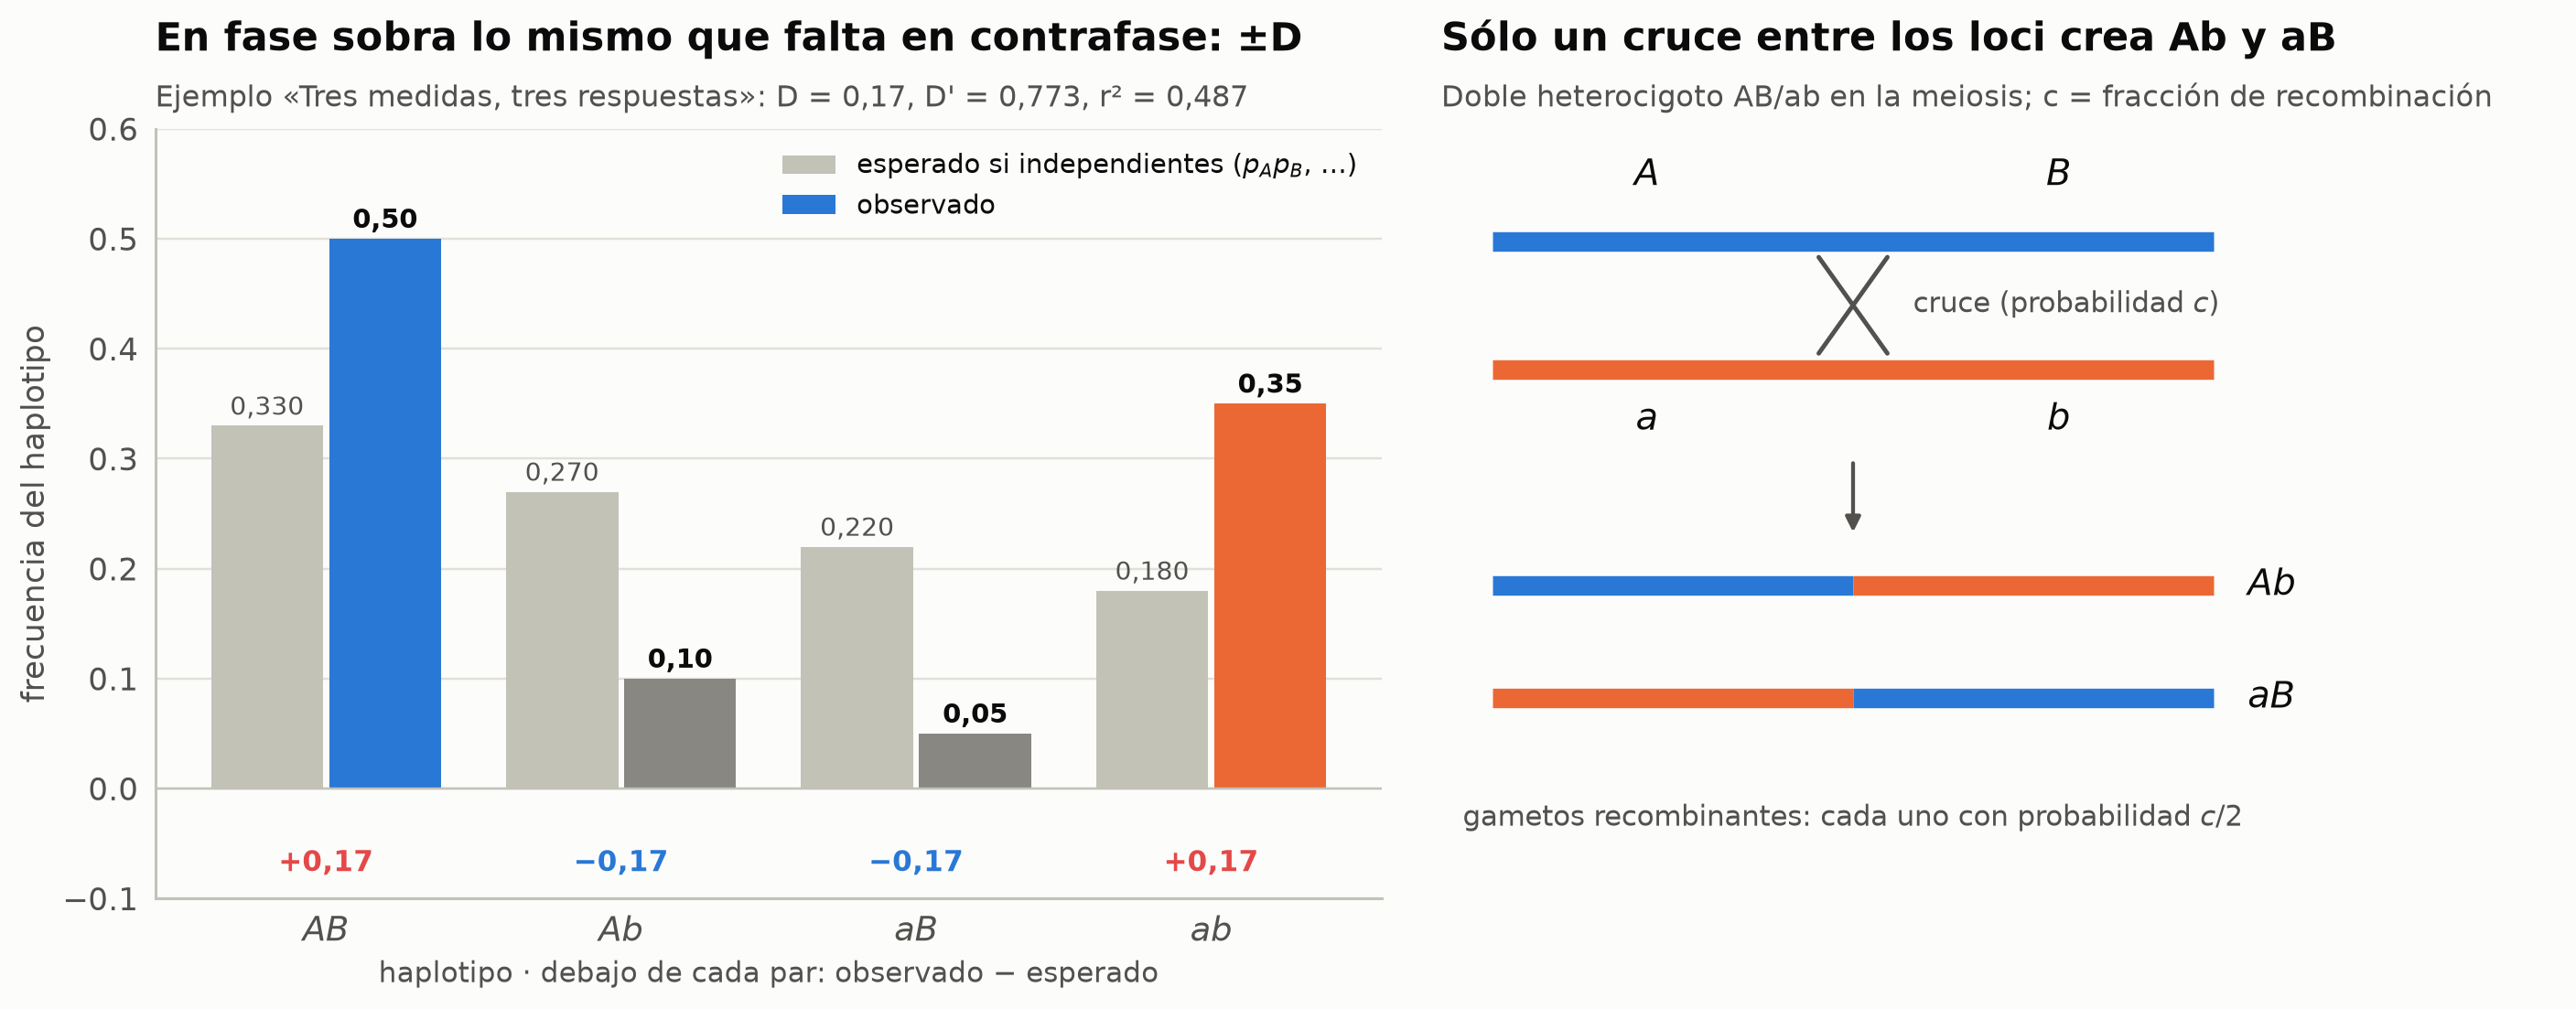

In [4]:
fig, (axt, axm) = plt.subplots(1, 2, figsize=(13, 4.9), gridspec_kw=dict(width_ratios=[1.1, 1]))
# (a) observado frente a esperado
labels = ["AB", "Ab", "aB", "ab"]
obs = np.array([pAB, pAb, paB, pab])
exp_ = np.array([pA * pB, pA * pb, pa * pB, pa * pb])
x = np.arange(4)
axt.bar(x - 0.2, exp_, 0.38, color=ec.BASELINE, label="esperado si independientes ($p_Ap_B$, …)")
cols = [ec.BLUE, ec.MUTED, ec.MUTED, ec.ORANGE]
axt.bar(x + 0.2, obs, 0.38, color=cols, label="observado")
for i in range(4):
    axt.text(x[i] - 0.2, exp_[i] + 0.01, f"{exp_[i]:.3f}".replace(".", ","), ha="center", fontsize=9, color=ec.INK_2)
    axt.text(x[i] + 0.2, obs[i] + 0.01, f"{obs[i]:.2f}".replace(".", ","), ha="center", fontsize=9.5,
             color=ec.INK, fontweight="bold")
    sign = "+" if obs[i] > exp_[i] else "−"
    axt.text(x[i], -0.075, f"{sign}{abs(obs[i] - exp_[i]):.2f}".replace(".", ","), ha="center", fontsize=10,
             color=ec.RED if sign == "+" else ec.BLUE, fontweight="bold")
axt.set_xticks(x, [f"${l[0]}{l[1]}$" for l in labels], fontsize=12)
axt.set_ylim(-0.1, 0.6); axt.axhline(0, color=ec.BASELINE, lw=0.8)
axt.set_ylabel("frecuencia del haplotipo")
axt.set_xlabel("haplotipo · debajo de cada par: observado − esperado", fontsize=10)
axt.legend(loc="upper right", frameon=False, fontsize=9.5)
ec.title(axt, "En fase sobra lo mismo que falta en contrafase: ±D",
         "Ejemplo «Tres medidas, tres respuestas»: D = 0,17, D' = 0,773, r² = 0,487")

# (b) recombinación en la meiosis
axm.set_xlim(-0.3, 6.2); axm.set_ylim(-1.2, 3.6); axm.axis("off")
axm.plot([0, 4.2], [2.9, 2.9], color=ec.BLUE, lw=7, solid_capstyle="butt")
axm.plot([0, 4.2], [2.1, 2.1], color=ec.ORANGE, lw=7, solid_capstyle="butt")
for xx, up, lo in ((0.9, "A", "a"), (3.3, "B", "b")):
    axm.text(xx, 3.25, f"${up}$", ha="center", fontsize=13); axm.text(xx, 1.72, f"${lo}$", ha="center", fontsize=13)
axm.plot([1.9, 2.3], [2.8, 2.2], color=ec.INK_2, lw=1.6); axm.plot([2.3, 1.9], [2.8, 2.2], color=ec.INK_2, lw=1.6)
axm.text(2.45, 2.5, "cruce (probabilidad $c$)", fontsize=10, color=ec.INK_2, va="center")
axm.annotate("", xy=(2.1, 1.05), xytext=(2.1, 1.55), arrowprops=dict(arrowstyle="-|>", color=ec.INK_2, lw=1.4))
axm.plot([0, 2.1], [0.75, 0.75], color=ec.BLUE, lw=7, solid_capstyle="butt")
axm.plot([2.1, 4.2], [0.75, 0.75], color=ec.ORANGE, lw=7, solid_capstyle="butt")
axm.plot([0, 2.1], [0.05, 0.05], color=ec.ORANGE, lw=7, solid_capstyle="butt")
axm.plot([2.1, 4.2], [0.05, 0.05], color=ec.BLUE, lw=7, solid_capstyle="butt")
axm.text(4.4, 0.75, "$Ab$", fontsize=13, va="center"); axm.text(4.4, 0.05, "$aB$", fontsize=13, va="center")
axm.text(2.1, -0.75, "gametos recombinantes: cada uno con probabilidad $c/2$", ha="center", fontsize=10,
         color=ec.INK_2)
ec.title(axm, "Sólo un cruce entre los loci crea Ab y aB",
         "Doble heterocigoto AB/ab en la meiosis; c = fracción de recombinación")
plt.show()

> 🔎 **Qué observamos.** Los haplotipos en fase ($AB$, $ab$) aparecen 0,17 más de lo esperado y los de contrafase
> 0,17 menos: en una tabla 2 × 2 **las cuatro desviaciones valen $\pm D$**, porque filas y columnas deben seguir
> sumando las frecuencias alélicas. A la derecha, el único proceso que convierte haplotipos en fase en haplotipos
> mezclados: un cruce entre los dos loci, con probabilidad $c$.

### 1.4 ¿Cuándo discrepan $D'$ y $r^2$?

$D'$ vale 1 siempre que falte uno de los cuatro haplotipos, **sin importar las frecuencias**. $r^2$, en cambio, sólo
puede valer 1 si además $p_A=p_B$ (o $p_A=p_b$): la correlación perfecta exige que los dos loci «se parezcan» en
frecuencia. El caso extremo es una **mutación nueva**: una mutación $B$ que aparece sobre un cromosoma $A$ empieza
con $p_{aB}=0$ y $\lvert D'\rvert=1$, pero, con $p_B$ minúscula, su $r^2$ con $A$ es diminuto. Barramos $p_B$ con
$p_A=0{,}5$ fijo y un haplotipo ausente:

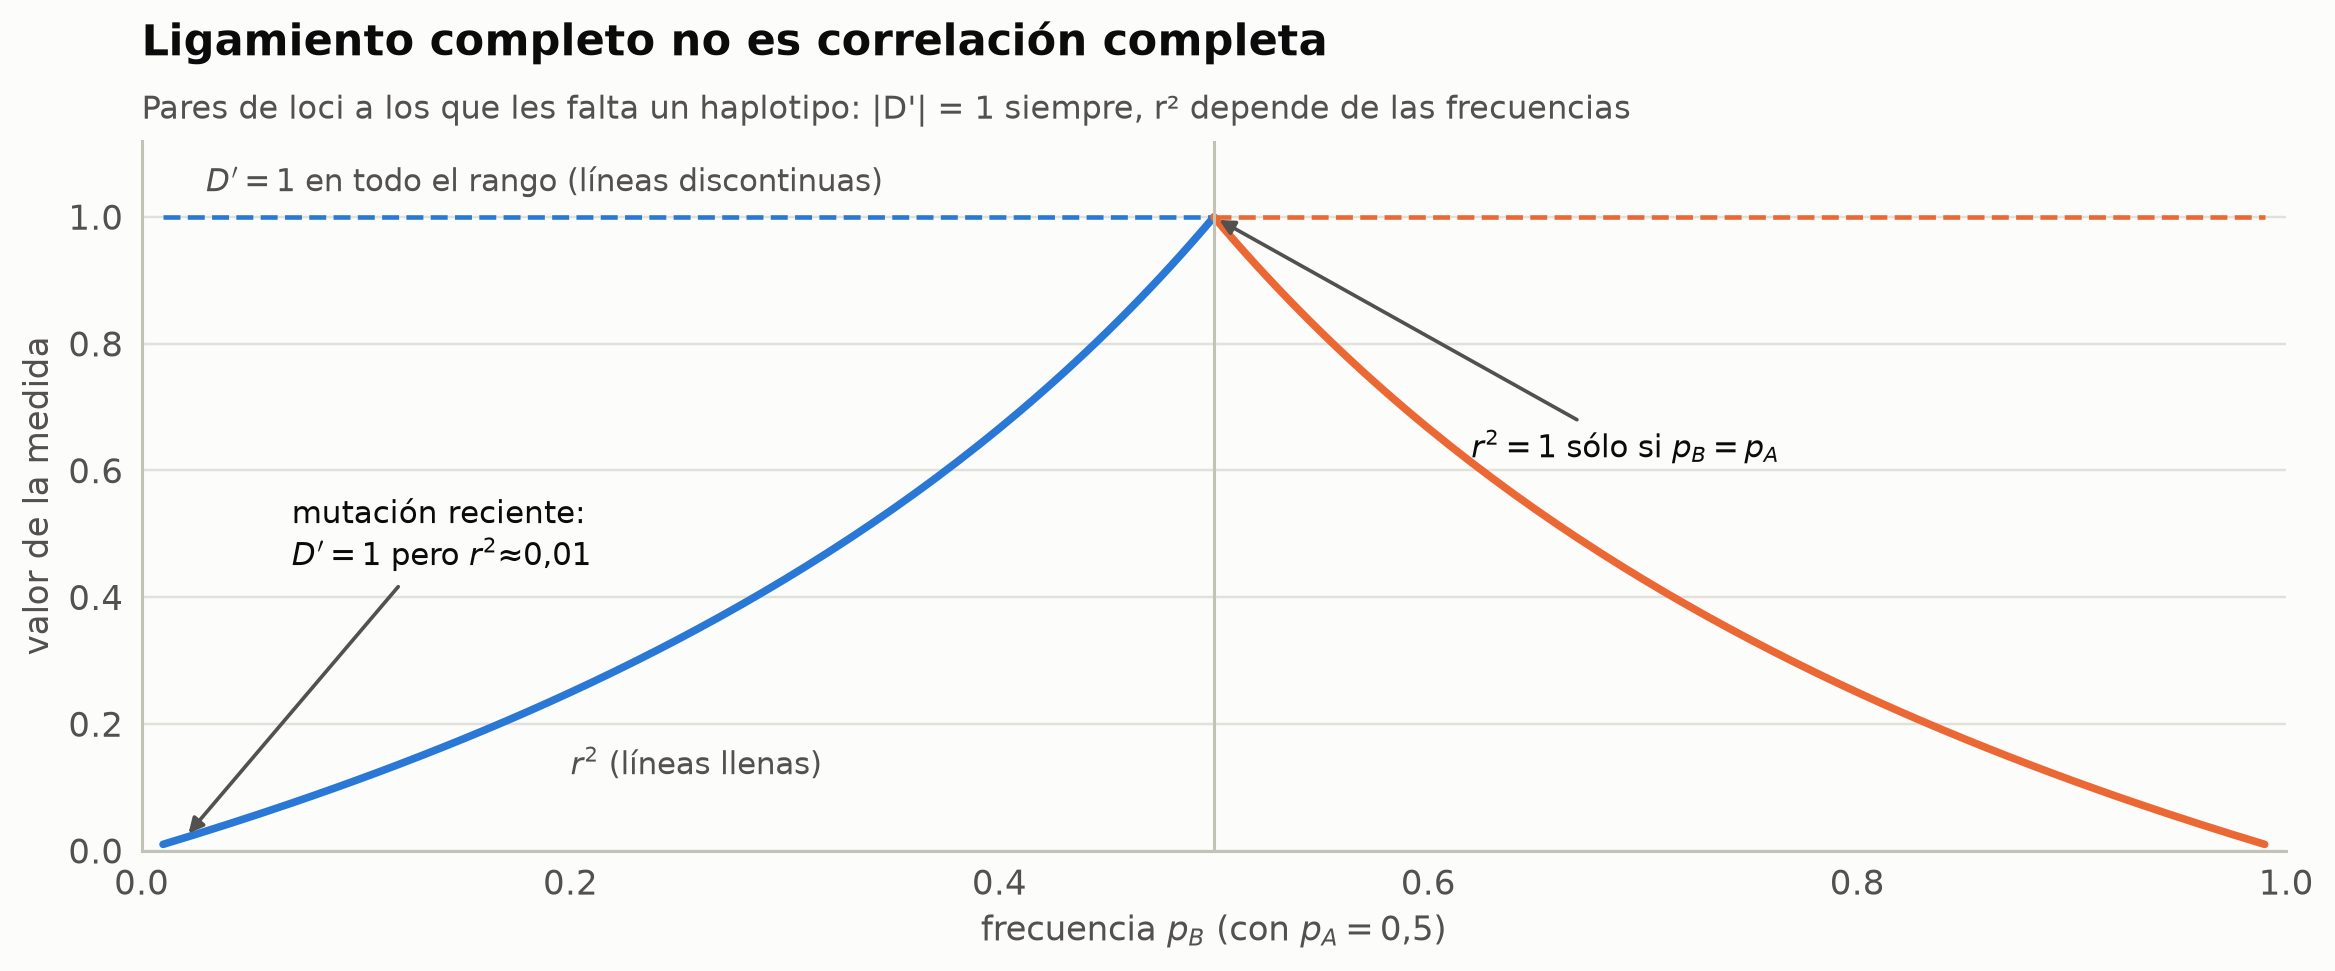

In [5]:
pA0 = 0.5
pBs = np.linspace(0.01, 0.99, 197)
fig, ax = plt.subplots(figsize=(10.5, 4.3))
for pab_zero, col, lab in ((True, ec.BLUE, "sin haplotipo $aB$ (B nació sobre A)"),
                           (False, ec.ORANGE, "sin haplotipo $Ab$")):
    r2s, dps = [], []
    for p in pBs:
        if pab_zero:            # p_aB = 0 → p_AB = p_B (requiere p_B ≤ p_A)
            if p > pA0: r2s.append(np.nan); dps.append(np.nan); continue
            pAB_ = p
        else:                   # p_Ab = 0 → p_AB = p_A (requiere p_B ≥ p_A)
            if p < pA0: r2s.append(np.nan); dps.append(np.nan); continue
            pAB_ = pA0
        D0 = pAB_ - pA0 * p
        dm = min(pA0 * (1 - p), (1 - pA0) * p)
        dps.append(D0 / dm); r2s.append(D0 ** 2 / (pA0 * (1 - pA0) * p * (1 - p)))
    ax.plot(pBs, dps, color=col, lw=1.5, ls="--")
    ax.plot(pBs, r2s, color=col, lw=2.5)
ax.axvline(pA0, color=ec.BASELINE, lw=1)
ax.text(0.03, 1.04, "$D' = 1$ en todo el rango (líneas discontinuas)", fontsize=10, color=ec.INK_2)
ax.text(0.2, 0.12, "$r^2$ (líneas llenas)", fontsize=10, color=ec.INK_2)
ax.annotate("$r^2 = 1$ sólo si $p_B = p_A$", (0.5, 1.0), (0.62, 0.62), fontsize=10, color=ec.INK,
            arrowprops=dict(arrowstyle="-|>", color=ec.INK_2, lw=1.2))
ax.annotate("mutación reciente:\n$D'=1$ pero $r^2≈0{,}01$", (0.02, 0.02), (0.07, 0.45), fontsize=10, color=ec.INK,
            arrowprops=dict(arrowstyle="-|>", color=ec.INK_2, lw=1.2))
ax.set_xlabel("frecuencia $p_B$ (con $p_A = 0{,}5$)"); ax.set_ylabel("valor de la medida")
ax.set_ylim(0, 1.12); ax.set_xlim(0, 1)
ec.title(ax, "Ligamiento completo no es correlación completa",
         "Pares de loci a los que les falta un haplotipo: |D'| = 1 siempre, r² depende de las frecuencias")
plt.show()

> 🔎 **Qué observamos.** Con un haplotipo ausente, $D'$ vale exactamente 1 para cualquier $p_B$, mientras que $r^2$
> recorre todo el intervalo $[0,1]$. Una variante **rara** (frecuencia 1 %) nunca puede ser buen sustituto de una
> **común** en un GWAS, aunque estén en ligamiento perfecto. Esta es la razón por la que los chips de genotipado
> diseñados con SNP comunes capturan mal las variantes raras.

> ✅ **Compruebe su comprensión.** En el ejemplo de los 10 cromosomas de la sección 1.2 ($p_{AB}=0{,}5$,
> $p_{Ab}=p_{aB}=0{,}1$, $p_{ab}=0{,}3$), calcule $D'$ y $r^2$. *(Respuesta: $D=0{,}14$; como $D>0$,
> $D_{\max}=\min\{0{,}6\cdot0{,}4,\ 0{,}4\cdot0{,}6\}=0{,}24$ y $D'=0{,}583$; $r^2=0{,}14^2/(0{,}6\cdot0{,}4)^2=0{,}340$.)*

## 2. El decaimiento del desequilibrio

### 2.1 ¿De dónde sale el LD y qué lo destruye?

Cada mutación nueva aparece en **un único cromosoma**, con un haplotipo concreto de alelos vecinos: nace en
desequilibrio máximo ($\lvert D'\rvert=1$) con todo lo que la rodea. La deriva en poblaciones pequeñas, los cuellos de
botella, la mezcla de poblaciones y la selección también **generan** LD. Lo único que lo **destruye** es la
recombinación.

Razonemos como en la figura anterior. Si la fracción de recombinación entre los loci es $c$, un haplotipo $AB$ de la
generación siguiente puede venir de dos fuentes:

* de un cromosoma **no recombinante** que ya era $AB$: probabilidad $(1-c)\,p_{AB}$;
* de un **recombinante** que tomó $A$ de un cromosoma y $B$ de otro, elegidos al azar: probabilidad $c\,p_Ap_B$
  (bajo apareamiento aleatorio).

Sumando y restando $p_Ap_B$ a ambos lados (ecuación 10-decay del libro):

$$
p'_{AB} = (1-c)\,p_{AB} + c\,p_A\,p_B
\quad\Longrightarrow\quad
D_{t} = (1-c)^{t}\,D_0 . \tag{10-decay}
$$

| Símbolo | Significado |
|---|---|
| $c$ | Fracción de recombinación entre los dos loci por meiosis ($0\le c\le\tfrac12$); en humanos, del orden de $10^{-8}$ por par de bases, es decir, alrededor de 1 cM/Mb. |
| $D_t$ | Desequilibrio en la generación $t$ en una población infinita. |
| $t$ | Generaciones transcurridas (en humanos, unos 25–30 años cada una). |

Cada generación se «olvida» una fracción $c$ del desequilibrio: es un decaimiento **geométrico**, como el de un
capital que pierde un porcentaje fijo al año.

> 🤔 **Antes de ejecutar, prediga.** ¿Qué fracción del LD queda tras 5 generaciones entre loci de cromosomas
> distintos ($c=1/2$)? ¿Y tras 50 generaciones entre loci a 1 cM ($c=0{,}01$)?

In [6]:
for c, t in ((0.5, 5), (0.01, 50), (0.001, 100), (0.001, 200)):
    print(f"c = {c:<6} t = {t:>3}:  D_t/D_0 = (1 - c)^t = {(1 - c) ** t:.4f}")

c = 0.5    t =   5:  D_t/D_0 = (1 - c)^t = 0.0312
c = 0.01   t =  50:  D_t/D_0 = (1 - c)^t = 0.6050
c = 0.001  t = 100:  D_t/D_0 = (1 - c)^t = 0.9048
c = 0.001  t = 200:  D_t/D_0 = (1 - c)^t = 0.8186


Loci no ligados pierden el 97 % del LD en cinco generaciones (queda un 3 %); loci a 1 cM conservan el **60 %** tras
50 generaciones (unos 1 400 años), y loci a unos 100 kb ($c\approx0{,}001$) conservan el **90 %** tras 100
generaciones y el **82 %** tras 200. Ésa es la escala del LD humano: decenas o cientos de kilobases, justo la
distancia entre una variante causal y el SNP de un chip que la «etiqueta».

### 2.2 El equilibrio entre deriva y recombinación

La ecuación 10-decay describe una población **infinita**, donde el LD sólo se destruye. En una población **finita**
la deriva genera LD nuevo continuamente (al azar, algunos haplotipos se multiplican más que otros), al mismo tiempo
que la recombinación lo destruye, y se alcanza un **equilibrio**. Hill y Robertson (1968) estudiaron este balance y
propusieron $r^2$ como medida; el análisis clásico de ese equilibrio conduce a la aproximación (ecuación 10-sved):

$$
\mathbb{E}[r^2] \approx \frac{1}{1+4N_e c}. \tag{10-sved}
$$

| Símbolo | Significado |
|---|---|
| $N_e$ | Tamaño efectivo de la población (Lección 10.1). |
| $4N_ec$ | Cuántas oportunidades de recombinación ha tenido la genealogía de la muestra entre los dos loci. |

De nuevo, todo depende de un único producto. Con $N_e=10^4$ y $c=10^{-8}$ por par de bases:

In [7]:
for Ne in (1e3, 1e4):
    for d in (1e4, 1e5):
        c = 1e-8 * d
        print(f"N_e = {Ne:>7,.0f}   distancia = {d / 1e3:>5.0f} kb   4·N_e·c = {4 * Ne * c:>5.1f}   E[r²] ≈ {1 / (1 + 4 * Ne * c):.4f}")

N_e =   1,000   distancia =    10 kb   4·N_e·c =   0.4   E[r²] ≈ 0.7143
N_e =   1,000   distancia =   100 kb   4·N_e·c =   4.0   E[r²] ≈ 0.2000
N_e =  10,000   distancia =    10 kb   4·N_e·c =   4.0   E[r²] ≈ 0.2000
N_e =  10,000   distancia =   100 kb   4·N_e·c =  40.0   E[r²] ≈ 0.0244


Con $N_e=10^4$, $\mathbb{E}[r^2]\approx0{,}20$ a 10 kb y $0{,}024$ a 100 kb; con $N_e=10^3$ (una población que pasó
por un cuello de botella), las mismas cifras se alcanzan a una distancia **diez veces mayor**. Por eso las poblaciones
con historia de cuello de botella tienen LD más extenso, y en las poblaciones africanas, con mayor $N_e$ histórico, el
LD decae en distancias más cortas. Lo comprobaremos con datos reales en la sección 4.

La figura reproduce las dos del libro (figura «Decaimiento del desequilibrio de ligamiento»), con las mismas curvas:

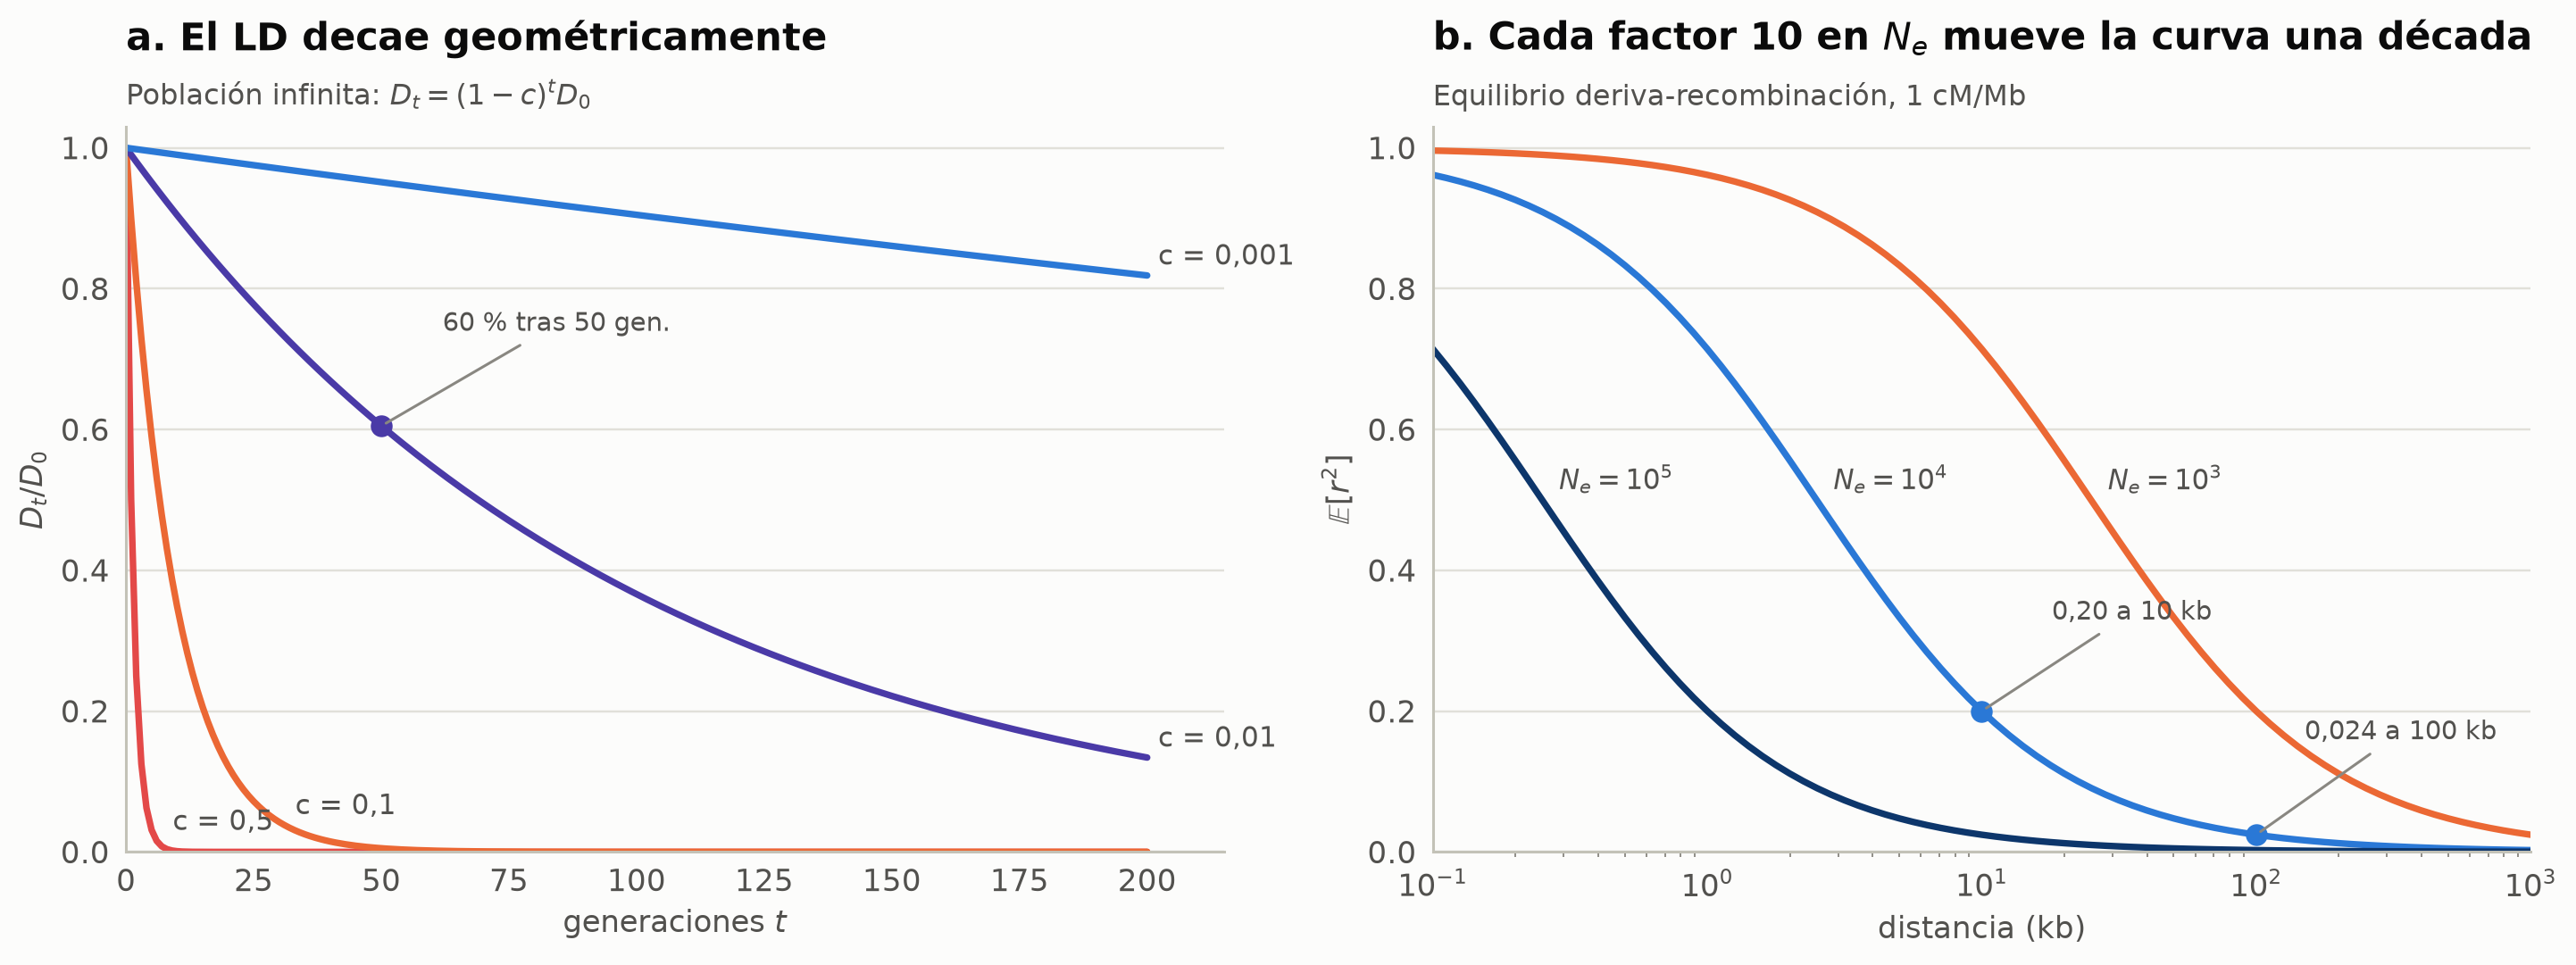

In [8]:
t = np.arange(0, 201)
dkb = np.logspace(-1, 3, 81)                      # 0,1 kb … 1 000 kb, como el libro
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.8))
for c, col in ((0.5, ec.RED), (0.1, ec.ORANGE), (0.01, ec.VIOLET), (0.001, ec.BLUE)):
    y = (1 - c) ** t
    a1.plot(t, y, color=col, lw=2.4)
    lab = f"c = {c:g}".replace(".", ",")
    xe = 200 if y[-1] > 0.05 else int(np.argmax(y < 0.05)) + 2
    a1.annotate(lab, (min(xe, 200), y[min(xe, 200)]), xytext=(4, 6 if c == 0.5 else 4), textcoords="offset points",
                fontsize=10, color=ec.INK_2)
a1.plot(50, 0.99 ** 50, "o", color=ec.VIOLET); a1.annotate("60 % tras 50 gen.", (50, 0.605), (62, 0.74),
                                                          fontsize=9.5, color=ec.INK_2, arrowprops=dict(arrowstyle="-", color=ec.MUTED, lw=1))
a1.set_xlim(0, 215); a1.set_ylim(0, 1.03); a1.set_xlabel("generaciones $t$"); a1.set_ylabel("$D_t/D_0$")
ec.title(a1, "a. El LD decae geométricamente", "Población infinita: $D_t=(1-c)^tD_0$")
for Ne, col in ((1e3, ec.ORANGE), (1e4, ec.BLUE), (1e5, "#0d366b")):
    y = 1 / (1 + 4 * Ne * 1e-8 * dkb * 1e3)
    a2.plot(dkb, y, color=col, lw=2.4)
    i = int(np.argmin(np.abs(y - 0.5)))
    a2.annotate(f"$N_e = 10^{int(np.log10(Ne))}$", (dkb[i], y[i]), xytext=(6, 4), textcoords="offset points",
                fontsize=10, color=ec.INK_2)
a2.plot([10, 100], [0.2, 1 / (1 + 4e4 * 1e-8 * 1e5)], "o", color=ec.BLUE)
a2.annotate("0,20 a 10 kb", (10, 0.2), (18, 0.33), fontsize=9.5, color=ec.INK_2,
            arrowprops=dict(arrowstyle="-", color=ec.MUTED, lw=1))
a2.annotate("0,024 a 100 kb", (100, 0.0244), (150, 0.16), fontsize=9.5, color=ec.INK_2,
            arrowprops=dict(arrowstyle="-", color=ec.MUTED, lw=1))
a2.set_xscale("log"); a2.set_xlim(0.1, 1000); a2.set_ylim(0, 1.03)
a2.set_xlabel("distancia (kb)"); a2.set_ylabel("$\\mathbb{E}[r^2]$")
ec.title(a2, "b. Cada factor 10 en $N_e$ mueve la curva una década", "Equilibrio deriva-recombinación, 1 cM/Mb")
plt.show()

> 🔎 **Qué observamos.** (a) Loci no ligados ($c=0{,}5$) se equilibran en pocas generaciones; loci a unos 100 kb
> ($c\approx0{,}001$) conservan el 82 % del LD tras 200 generaciones. (b) En una población finita, el LD útil para
> la asociación se extiende a decenas de kilobases cuando $N_e$ es pequeño y se acorta cuando es grande: multiplicar
> $N_e$ por 10 equivale a dividir la distancia por 10.

### 🎬 La recombinación deshace el LD, generación a generación

La ecuación 10-decay es una predicción. Pongámosla a prueba con una simulación explícita: 10 000 cromosomas de 50 cM
(unas 50 Mb humanas) que al principio son de sólo dos tipos, **azul** y **naranja**, como si una población se
hubiera fundado por la mezcla, a partes iguales, de dos grupos distintos. Cada generación, cada cromosoma hijo se
arma con dos cromosomas padres elegidos al azar, cortados en puntos de cruce que caen al azar (en promedio 0,5 por
meiosis en 50 cM, según la función de mapa de Haldane). Además seguimos un locus en **otro** cromosoma ($c=1/2$).
Medimos $D_t/D_0$, promediado sobre todos los pares de posiciones separados 1, 5 y 20 cM (y entre cada
posición y el locus del otro cromosoma), y lo comparamos con
$(1-c)^t$ usando $c=\tfrac12(1-e^{-2d})$ (Haldane) para la distancia de mapa $d$ en morgans.

In [9]:
DIST_CM = [1, 5, 20]
def simulate_mosaic(n_chrom=10000, n_pos=201, length_M=0.5, generations=100, n_show=70, seed=102):
    """Cromosomas de origen azul (1) o naranja (0) que se recombinan cada generación (apareamiento aleatorio).
    Guarda n_show cromosomas por generación (para dibujar) y D/D0 medio entre todos los pares de posiciones
    separados 1, 5 y 20 cM, y entre un locus y otro de un cromosoma distinto."""
    rng = np.random.default_rng(seed)
    x = np.linspace(0, length_M, n_pos)                       # posiciones en morgans (paso de 0,25 cM)
    step_cm = 100 * x[1]
    lags = {d: int(round(d / step_cm)) for d in DIST_CM}
    blue = rng.permutation(n_chrom) < n_chrom // 2               # la mitad, al azar, de origen azul
    chrom = np.zeros((n_chrom, n_pos), np.int8); chrom[blue] = 1
    unlinked = blue.astype(np.int8)                           # otro cromosoma, mismo origen
    shown, Dhist = [], {d: [] for d in DIST_CM + ["no ligado"]}
    def record():
        shown.append(chrom[:n_show].copy())
        p = chrom.mean(0)
        for d, L in lags.items():                             # D medio de todos los pares a distancia d
            Dhist[d].append(((chrom[:, :-L] * chrom[:, L:]).mean(0) - p[:-L] * p[L:]).mean())
        Dhist["no ligado"].append((chrom * unlinked[:, None]).mean(0).mean() - (p * unlinked.mean()).mean())
    record()
    for _ in range(generations):
        p1, p2 = rng.integers(n_chrom, size=(2, n_chrom))
        k = rng.poisson(length_M, n_chrom)                     # número de cruces por meiosis
        kmax = max(1, k.max())
        bp = rng.uniform(0, length_M, (n_chrom, kmax))
        bp[np.arange(kmax)[None, :] >= k[:, None]] = np.inf    # sólo k puntos de cruce válidos
        parity = (bp[:, :, None] < x[None, None, :]).sum(1) % 2
        start2 = rng.random(n_chrom) < 0.5                      # ¿con qué cromátida empieza el gameto?
        take2 = (parity == 1) ^ start2[:, None]
        chrom = np.where(take2, chrom[p2], chrom[p1]).astype(np.int8)
        unlinked = np.where(rng.random(n_chrom) < 0.5, unlinked[p1], unlinked[p2])
        record()
    D_rel = {key: np.array(v) / v[0] for key, v in Dhist.items()}
    c_of = {d: 0.5 * (1 - np.exp(-2 * lags[d] * step_cm / 100)) for d in DIST_CM}; c_of["no ligado"] = 0.5
    return np.array(shown), D_rel, c_of

mosaic, D_sim, c_of = simulate_mosaic()
for key in D_sim:
    print(f"{str(key):>10} (c = {c_of[key]:.4f}):  D/D_0 simulado a t = 20: {D_sim[key][20]:.3f} (teoría {(1 - c_of[key]) ** 20:.3f})"
          f" · a t = 100: {D_sim[key][100]:.3f} (teoría {(1 - c_of[key]) ** 100:.3f})")

         1 (c = 0.0099):  D/D_0 simulado a t = 20: 0.818 (teoría 0.820) · a t = 100: 0.367 (teoría 0.370)
         5 (c = 0.0476):  D/D_0 simulado a t = 20: 0.381 (teoría 0.377) · a t = 100: 0.011 (teoría 0.008)
        20 (c = 0.1648):  D/D_0 simulado a t = 20: 0.023 (teoría 0.027) · a t = 100: 0.003 (teoría 0.000)
 no ligado (c = 0.5000):  D/D_0 simulado a t = 20: 0.001 (teoría 0.000) · a t = 100: 0.003 (teoría 0.000)


![10 000 cromosomas de dos orígenes (azul y naranja) se recombinan al azar: los bloques se fragmentan y el LD entre loci cercanos sobrevive mucho más que entre loci lejanos, como predice D_t = (1 − c)^t D_0](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-10-poblaciones-gwas/10.2_ld_decae.gif)

*10 000 cromosomas de dos orígenes (azul y naranja) se recombinan al azar: los bloques se fragmentan y el LD entre loci cercanos sobrevive mucho más que entre loci lejanos, como predice D_t = (1 − c)^t D_0*

In [10]:
FR = list(range(0, 31)) + list(range(32, 101, 3))            # 54 cuadros: rápido al inicio, luego cada 3 gen.
cmap2 = ListedColormap([ec.ORANGE, ec.BLUE])
fig = plt.figure(figsize=(12.5, 5.6))
fig.get_layout_engine().set(rect=(0, 0, 1, 0.86))
gs = fig.add_gridspec(1, 2, width_ratios=[1.15, 1])
axm = fig.add_subplot(gs[0]); axd = fig.add_subplot(gs[1])
im = axm.imshow(mosaic[0], aspect="auto", cmap=cmap2, vmin=0, vmax=1, interpolation="nearest",
                extent=(0, 50, 70, 0))
for d in DIST_CM:
    axm.axvline(d, color="white", lw=0.8, ls=":")
axm.set_xlabel("posición en el cromosoma (cM)"); axm.set_ylabel("70 de los 10 000 cromosomas")
axm.set_yticks([])
gtxt = axm.text(49, 67.5, "", ha="right", fontsize=12, fontweight="bold", color="white",
                bbox=dict(boxstyle="round,pad=0.25", fc=ec.INK, alpha=0.7, lw=0))
tt = np.arange(0, 101)
curves = {}
cols = {1: ec.BLUE, 5: ec.VIOLET, 20: ec.ORANGE, "no ligado": ec.RED}
for key, col in cols.items():
    axd.plot(tt, (1 - c_of[key]) ** tt, color=col, lw=1.2, ls="--", alpha=0.8)
    curves[key], = axd.plot([], [], "o", ms=3.2, color=col, label=f"{key} cM" if key != "no ligado" else "otro cromosoma")
axd.set_xlim(0, 101); axd.set_ylim(-0.05, 1.05); axd.set_xlabel("generaciones $t$"); axd.set_ylabel("$D_t/D_0$")
axd.legend(loc="upper right", frameon=False, fontsize=9.5, title="puntos: simulación\nlíneas: $(1-c)^t$", title_fontsize=9)
fig.text(0.01, 0.985, "La recombinación corta los bloques; lo cercano sigue unido mucho más tiempo", fontsize=15,
         fontweight="bold", color=ec.INK, va="top")
fig.text(0.01, 0.935, "Izquierda: origen de cada tramo (azul/naranja). Derecha: D/D₀ medio entre loci a 1, 5 y 20 cM y en "
         "otro cromosoma", fontsize=10.5, color=ec.INK_2, va="top")

def update(f):
    g = FR[f]
    im.set_data(mosaic[g])
    gtxt.set_text(f"generación {g}")
    for key in cols:
        curves[key].set_data(tt[: g + 1], D_sim[key][: g + 1])
    return []

fig.canvas.draw()
with plt.rc_context({"savefig.bbox": None}):
    anim_html = ec.animate(fig, update, frames=len(FR), interval=160, name="10.2_ld_decae")
anim_html

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** En la generación 0 cada cromosoma es de un solo color: el LD es máximo entre todos los
> loci. El locus del otro cromosoma pierde la asociación en cinco o seis generaciones; a 20 cM ($c=0{,}165$) quedan
> fragmentos de unos pocos centimorgans en pocas decenas de generaciones; a 1 cM, tras 100 generaciones, todavía
> sobrevive alrededor de un tercio del LD. Los puntos siguen a las curvas de la teoría con un pequeño ruido: la
> **deriva** de una población de 10 000 cromosomas, que es justamente la fuente de LD nuevo de la ecuación 10-sved.
> Este mismo mecanismo explica el **mapeo por mezcla** (*admixture mapping*): en poblaciones mezcladas hace pocas
> generaciones, como las de las Américas, los tramos de ancestría todavía miden decenas de centimorgans.

> ✅ **Compruebe su comprensión.** Una población se formó por la mezcla de dos grupos hace 20 generaciones. ¿Qué
> fracción del LD de mezcla queda entre loci a 5 cM? *(Con Haldane, $c=\tfrac12(1-e^{-0{,}1})=0{,}0476$ y
> $(1-0{,}0476)^{20}=0{,}377$: más de un tercio.)*

## 3. Bloques de haplotipos, HapMap y 1000 Genomas

### 3.1 La recombinación no es uniforme

La ecuación 10-decay supone que la recombinación es uniforme a lo largo del cromosoma. No lo es. La mayor parte de
los entrecruzamientos humanos se concentran en **puntos calientes** de uno o dos kilobases, separados por regiones
donde la recombinación es muy escasa. El resultado es un **mosaico**: tramos de decenas de kilobases en los que el LD
es alto y la diversidad haplotípica baja, separados por fronteras abruptas.

Gabriel et al. (2002) analizaron 51 regiones autosómicas en muestras de cuatro poblaciones y definieron formalmente
los **bloques de haplotipos** a partir de los intervalos de confianza de $D'$: un bloque es una región en la que casi
todos los pares de marcadores muestran evidencia de LD fuerte, es decir, de recombinación histórica escasa.
Observaron que dentro de cada bloque **unos pocos haplotipos comunes** explican la gran mayoría de los cromosomas, y
que los bloques eran en promedio **más cortos en las muestras africanas**.

### 3.2 El mapa de LD del libro, reconstruido

El libro ilustra la idea con una simulación: 70 SNP colocados al azar en una región de 200 kb, tres puntos calientes
(48, 105 y 160 kb) y, en cada bloque, siete haplotipos **fundadores** emparentados por un árbol; 600 cromosomas
construidos como mosaicos de esos fundadores. Para obtener **exactamente** la figura del libro partimos del mismo
estado del generador aleatorio que tenía el script del libro (`numpy.random.default_rng(1908)`) al llegar a esta
simulación; lo guardamos en el archivo pequeño `data/102_book_rng_states.json`.

In [11]:
book_states = json.load(open(course_file("102_book_rng_states.json")))
rng = np.random.default_rng(); rng.bit_generator.state = book_states["ld"]   # mismo estado que el libro

# Haplotipos por mosaico con puntos calientes de recombinación (código del libro, figuras/cap10/generar.py)
nS, nH, Kf = 70, 600, 7
pos_kb = np.sort(rng.uniform(0, 200, nS))           # kb
hot = np.array([48.0, 105.0, 160.0])
block_of = np.searchsorted(hot, pos_kb)
founders = np.zeros((Kf, nS), int)
for bq in range(len(hot) + 1):                      # en cada bloque, un árbol aleatorio entre los 7 fundadores
    clades = [{i} for i in range(Kf)]
    alive = [{i} for i in range(Kf)]
    while len(alive) > 1:
        i, j = sorted(rng.choice(len(alive), 2, replace=False))
        new = alive[i] | alive[j]
        alive = [v for k, v in enumerate(alive) if k not in (i, j)] + [new]
        if len(new) < Kf:
            clades.append(new)
    for jx in np.where(block_of == bq)[0]:          # cada SNP cae en una rama (clado) del árbol
        cl = clades[rng.integers(len(clades))]
        founders[list(cl), jx] = 1
weight = rng.dirichlet(np.full(Kf, 1.5))
gap = np.diff(pos_kb)
pswitch = 1 - np.exp(-0.0015 * gap)                 # fondo: 0,0015 cambios de fundador por kb
for h in hot:
    inside = (pos_kb[:-1] <= h) & (pos_kb[1:] > h)
    pswitch[inside] = 0.7                           # punto caliente
Hsim = np.zeros((nH, nS), int)
for i in range(nH):
    f = rng.choice(Kf, p=weight)
    Hsim[i, 0] = founders[f, 0]
    for j in range(1, nS):
        if rng.random() < pswitch[j - 1]:
            f = rng.choice(Kf, p=weight)
        Hsim[i, j] = founders[f, j]
Hsim ^= (rng.random(Hsim.shape) < 0.002).astype(int)    # mutaciones recurrentes
fr = Hsim.mean(0)
keep = (fr > 0.08) & (fr < 0.92)
Hsim, pos_kb = Hsim[:, keep], pos_kb[keep]
nS = Hsim.shape[1]

Dp = np.zeros((nS, nS)); R2 = np.zeros((nS, nS))
for i in range(nS):
    for j in range(i + 1, nS):
        _, dprime, rr = ld(Hsim[:, i], Hsim[:, j])
        Dp[i, j], R2[i, j] = abs(dprime), rr
iu = np.triu_indices(nS, 1)
print(f"SNPs = {nS}   haplotipos = {nH}   r² medio = {R2[iu].mean():.3f}   |D'| medio = {Dp[iu].mean():.3f}")

SNPs = 41   haplotipos = 600   r² medio = 0.097   |D'| medio = 0.401


Las mismas cifras del libro: 41 SNP tras filtrar los de frecuencia extrema, $r^2$ medio $0{,}097$ y $\lvert D'\rvert$
medio $0{,}401$. Ahora dibujamos el mapa **al estilo de Haploview**: cada rombo es un par de SNP; el del vértice
superior de cada triángulo compara vecinos inmediatos y, hacia abajo, se comparan SNP cada vez más alejados. Las
líneas grises conectan cada SNP con su posición física.

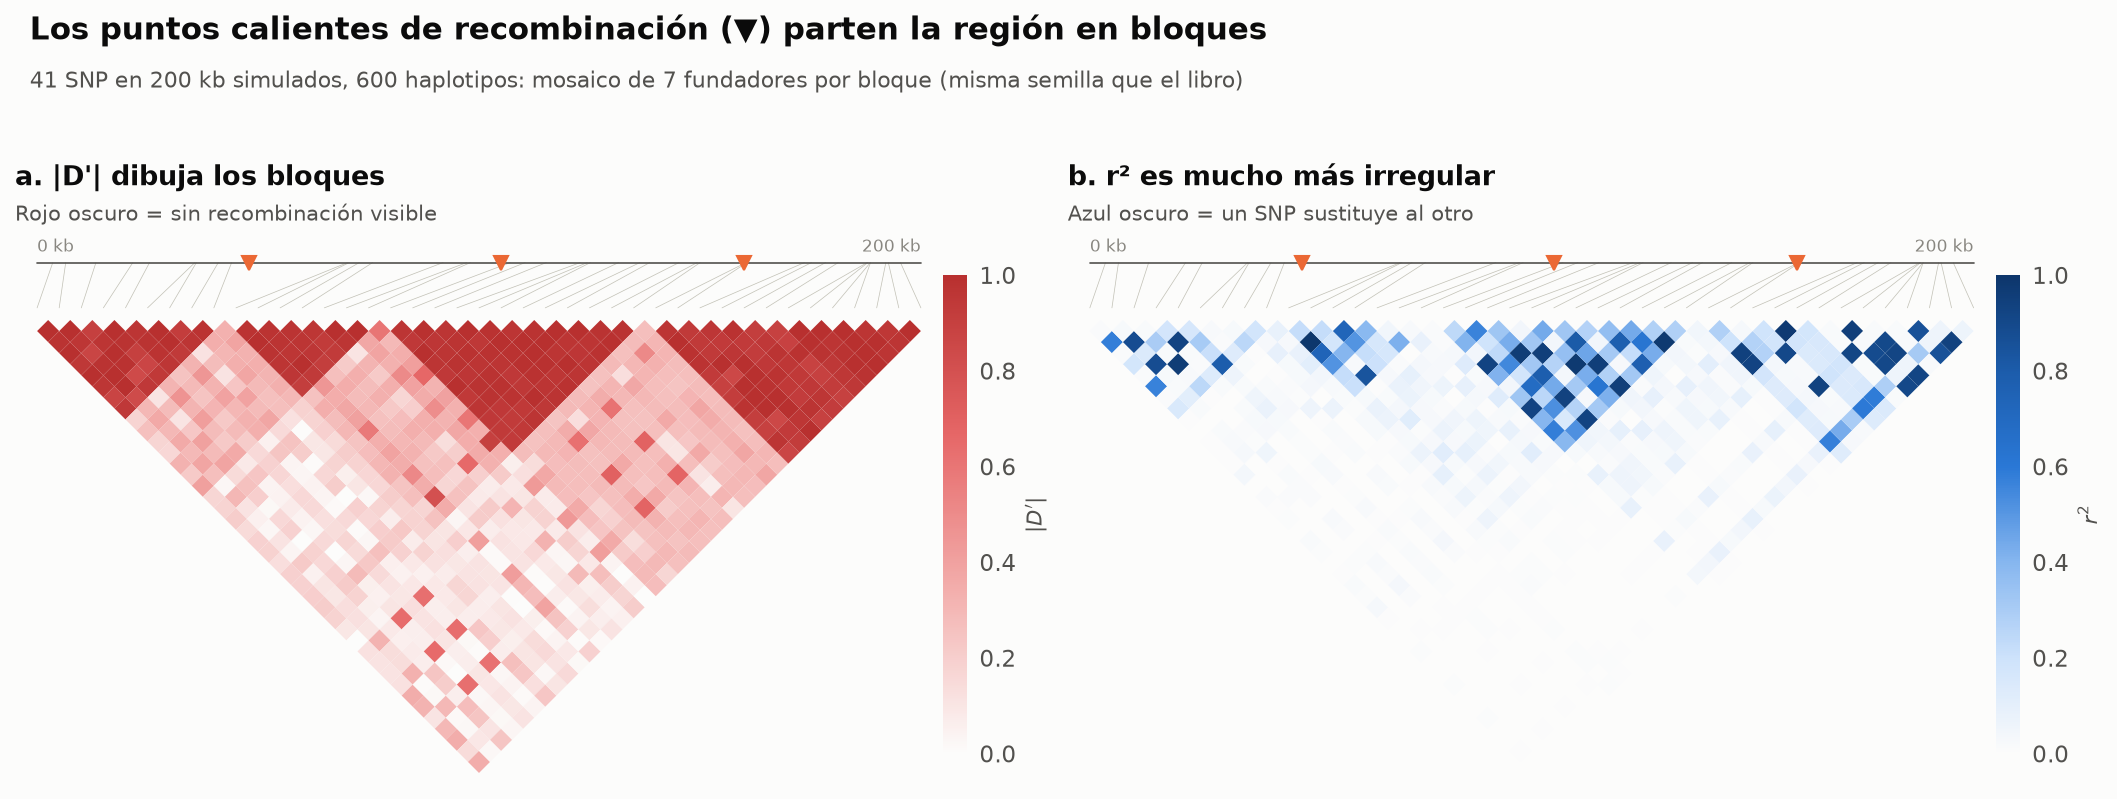

In [12]:
def ld_triangle(ax, M, cmap, pos, span, hotspots=(), label="", vmax=1.0):
    """Mapa de LD triangular al estilo de Haploview (rombos girados 45°)."""
    n = M.shape[0]
    polys, vals = [], []
    for i in range(n):
        for j in range(i + 1, n):
            cx, cy = (i + j) / 2, -(j - i) / 2
            polys.append([(cx, cy + 0.5), (cx + 0.5, cy), (cx, cy - 0.5), (cx - 0.5, cy)])
            vals.append(M[i, j])
    pc = PolyCollection(polys, array=np.array(vals), cmap=cmap, edgecolors="none", clim=(0, vmax))
    ax.add_collection(pc)
    L = n - 1
    top = max(2.6, n / 16)
    for k in range(n):                                # regla de posiciones físicas
        ax.plot([(pos[k] - span[0]) / (span[1] - span[0]) * L, k], [top, 0.55], color=ec.BASELINE, lw=0.35)
    ax.plot([0, L], [top, top], color=ec.INK_2, lw=0.8)
    for h in hotspots:
        ax.plot((h - span[0]) / (span[1] - span[0]) * L, top, marker="v", color=ec.ORANGE, ms=7, clip_on=False)
    ax.set_xlim(-1, n); ax.set_ylim(-n / 2 - 0.5, top + 0.8)
    ax.set_aspect("equal"); ax.axis("off")
    cb = plt.colorbar(pc, ax=ax, fraction=0.03, pad=0.0, shrink=0.6)
    cb.outline.set_visible(False); cb.set_label(label, fontsize=10, color=ec.INK_2)
    return pc

fig, axes = plt.subplots(1, 2, figsize=(14, 5.4))
ld_triangle(axes[0], Dp, CM_DP, pos_kb, (0, 200), hot, "$|D'|$")
ld_triangle(axes[1], R2, CM_R2, pos_kb, (0, 200), hot, "$r^2$")
for ax, t_, s_ in ((axes[0], "a. |D'| dibuja los bloques", "Rojo oscuro = sin recombinación visible"),
                   (axes[1], "b. r² es mucho más irregular", "Azul oscuro = un SNP sustituye al otro")):
    ax.text(-1, 2.9 + 3.2, t_, fontsize=13, fontweight="bold", color=ec.INK)
    ax.text(-1, 2.9 + 1.6, s_, fontsize=10, color=ec.INK_2)
    ax.text(0, 2.9 + 0.2, "0 kb", fontsize=8, color=ec.MUTED); ax.text(nS - 1, 2.9 + 0.2, "200 kb", fontsize=8,
                                                                    color=ec.MUTED, ha="right")
fig.set_dpi(75)                                              # figura densa: resolución moderada
ec.fig_title(fig, "Los puntos calientes de recombinación (▼) parten la región en bloques",
             "41 SNP en 200 kb simulados, 600 haplotipos: mosaico de 7 fundadores por bloque (misma semilla que el libro)")
plt.show()

> 🔎 **Qué observamos.** (a) Dentro de cada bloque casi todos los pares tienen $\lvert D'\rvert\approx1$ (rojo
> oscuro): los haplotipos del bloque descienden de pocos ancestros sin recombinación entre ellos, y las fronteras
> coinciden con los puntos calientes. (b) $r^2$, para los mismos pares, es irregular: dos SNP pueden estar en LD
> completo ($\lvert D'\rvert=1$) y aun así tener $r^2$ bajo si sus frecuencias alélicas son muy distintas, como vimos en
> la sección 1.4. **$D'$ revela la historia de recombinación; $r^2$, la capacidad de un SNP para sustituir a otro.**

### 3.3 SNP etiqueta, HapMap, 1000 Genomas e imputación

Si los alelos de un bloque se heredan en unas pocas combinaciones, **no hace falta genotipar todos los SNP**: basta con
unos pocos **SNP etiqueta** (*tag SNPs*) que capturen, vía $r^2$, a los demás. Probémoslo en la región simulada con el
algoritmo codicioso clásico: elegir el SNP que etiqueta a más SNP aún no cubiertos (con $r^2\ge0{,}8$), marcarlos
como cubiertos y repetir.

In [13]:
def greedy_tags(R2full, thr=0.8):
    """Selección codiciosa de SNP etiqueta: cada SNP debe tener r² ≥ thr con algún SNP etiqueta."""
    covers = R2full >= thr
    left = np.ones(len(R2full), bool); tags = []
    while left.any():
        best = int(np.argmax((covers & left[None, :]).sum(1)))
        tags.append(best); left &= ~covers[best]
    return tags

R2full = R2 + R2.T; np.fill_diagonal(R2full, 1)
for thr in (0.5, 0.8, 0.95):
    tags = greedy_tags(R2full, thr)
    print(f"umbral r² ≥ {thr}: {len(tags):>2} SNP etiqueta capturan los {nS} SNP ({len(tags) / nS:.0%})")

umbral r² ≥ 0.5: 14 SNP etiqueta capturan los 41 SNP (34%)


umbral r² ≥ 0.8: 21 SNP etiqueta capturan los 41 SNP (51%)
umbral r² ≥ 0.95: 33 SNP etiqueta capturan los 41 SNP (80%)


Con $r^2\ge0{,}8$ bastan 21 de los 41 SNP (la mitad) para «ver» toda la región, y con $r^2\ge0{,}5$, sólo 14. En
el genoma real, con millones de SNP comunes y bloques largos, la proporción ahorrada es mucho mayor. Ésa fue la lógica del **Proyecto
Internacional HapMap**: catalogar el patrón de LD en todo el genoma. Su primera fase genotipó más de un millón de SNP
en 269 individuos de cuatro poblaciones (International HapMap Consortium, 2005) y sirvió para diseñar los chips de
genotipado que harían posibles los primeros GWAS. Una década después, el **Proyecto 1000 Genomas** secuenció a 2 504
personas de 26 poblaciones y construyó un panel de referencia de más de 88 millones de variantes (1000 Genomes Project
Consortium, 2015).

Con paneles así se practica la **imputación**: a partir de los SNP genotipados con un chip y de los haplotipos de
referencia, se predicen probabilísticamente los genotipos de millones de variantes no genotipadas, aprovechando
precisamente el LD. Una empresa de pruebas genéticas de consumo, por ejemplo, genotipa unos cientos de miles de SNP
con un chip e imputa el resto con un panel de referencia; la calidad de esa imputación depende de que el panel
contenga haplotipos **de la misma ancestría** que el cliente, un problema real de equidad en genómica.

> ⚠️ **Cuidado: genotipos no son haplotipos.** Un chip o una llamada de variantes estándar dan **genotipos**, no
> haplotipos: sabemos que un individuo es $Aa$ y $Bb$, pero no si sus cromosomas son $AB/ab$ o $Ab/aB$. Estimar la
> **fase** (*phasing*) es un problema estadístico en sí mismo. Calcular $r^2$ a partir de dosis genotípicas (la
> correlación entre columnas 0/1/2) es una aproximación útil, y es lo que hacen herramientas como PLINK por
> defecto, pero $D'$ requiere haplotipos o una estimación de ellos. Lo comprobaremos con los datos reales.

## 4. Datos reales I: la región de la lactasa en 2 504 personas

### 4.1 Por qué algunos adultos digieren la leche

Casi todos los mamíferos dejan de producir **lactasa**, la enzima intestinal que digiere el azúcar de la leche,
después del destete. En muchos humanos adultos pasa lo mismo (la «intolerancia a la lactosa» del adulto es, en
realidad, el estado ancestral), pero en algunas poblaciones la mayoría de los adultos sigue produciéndola: es la
**persistencia de la lactasa**. En Europa, esa persistencia se asocia fuertemente con una variante situada a unas 14
kb del inicio del gen *LCT*, dentro de un intrón del gen vecino *MCM6*, que actúa como potenciador de la
transcripción: la variante **−13910 C>T** (rs4988235; Enattah et al., 2002). En la hebra positiva del ensamblaje
GRCh37 es el cambio **G>A en 2:136 608 646** (el alelo **A** es el de persistencia). Hoy se usa incluso como prueba
genética en el diagnóstico diferencial de la hipolactasia del adulto en pacientes de ascendencia europea.

Bersaglieri et al. (2004) mostraron que el haplotipo que lleva el alelo de persistencia es **frecuente y
extraordinariamente largo** en europeos: una de las señales de selección positiva reciente más fuertes del genoma
humano. La explicación es un **barrido selectivo**: con la ganadería lechera, los portadores tuvieron más
descendencia; el alelo subió de frecuencia tan deprisa que la recombinación no tuvo tiempo de romper el haplotipo
en el que había nacido. Todo lo que vimos en las secciones 1–3 (LD, decaimiento, bloques) está en juego a la vez. En
África oriental, la persistencia se asocia con **otras** variantes del mismo potenciador, un caso de evolución
convergente (Tishkoff et al., 2007).

### 4.2 Leer un VCF faseado con Python puro

El archivo contiene 907 SNP bialélicos con frecuencia del alelo menor ≥ 5 % entre 136,3 y 136,9 Mb del cromosoma 2,
con los genotipos **faseados** de las 2 504 personas (`0|1` significa: haplotipo materno o paterno 1 con el alelo de
referencia, haplotipo 2 con el alternativo). No hace falta ninguna biblioteca: basta leer el texto comprimido línea a
línea. Cada persona aporta **dos** filas a la matriz de haplotipos $H$ (haplotipos × SNP, valores 0/1).

In [14]:
VCF = course_file("1000G_chr2_LCT_136.3-136.9Mb.vcf.gz")
pos, ref, alt, info, rows = [], [], [], [], []
with gzip.open(VCF, "rt") as fh:
    for line in fh:
        if line.startswith("##"):
            continue
        if line.startswith("#CHROM"):
            vcf_samples = line.rstrip("\n").split("\t")[9:]
            continue
        f = line.rstrip("\n").split("\t")
        pos.append(int(f[1])); ref.append(f[3]); alt.append(f[4]); info.append(f[7])
        # "0|1\t1|1\t..." → cadena de dígitos "0111..." → vector 0/1 (dos haplotipos por persona)
        gts = "".join(f[9:]).replace("|", "")
        rows.append(np.frombuffer(gts.encode(), np.uint8) - 48)
H = np.array(rows, dtype=np.int8).T                 # haplotipos × SNP
pos = np.array(pos)
info_d = [dict(kv.split("=", 1) for kv in s.split(";") if "=" in kv) for s in info]
anc = np.array([d.get("AA", "?").split("|")[0].upper() for d in info_d])   # alelo ancestral (comparación con primates)
panel = pd.read_csv(course_file("1000G_phase3_panel.tsv"), sep="\t", usecols=[0, 1, 2, 3]).set_index("sample")
panel = panel.loc[vcf_samples]
hap_pop = np.repeat(panel["pop"].values, 2); hap_sup = np.repeat(panel["super_pop"].values, 2)
CORE_POS = 136_608_646
core = int(np.where(pos == CORE_POS)[0][0])
print(f"H: {H.shape[0]} haplotipos × {H.shape[1]} SNP ({pos[0]:,} – {pos[-1]:,})")
print(f"SNP núcleo: 2:{pos[core]:,} {ref[core]}>{alt[core]} · alelo ancestral: {anc[core]} "
      f"→ A (persistencia) es el alelo DERIVADO")
print("Primeras líneas de datos del VCF, tal como vienen:")
with gzip.open(VCF, "rt") as fh:
    shown = 0
    for line in fh:
        if not line.startswith("#"):
            print("  " + line[:150].replace("\t", "  ") + " …"); shown += 1
            if shown == 2: break

H: 5008 haplotipos × 907 SNP (136,300,341 – 136,899,859)
SNP núcleo: 2:136,608,646 G>A · alelo ancestral: G → A (persistencia) es el alelo DERIVADO
Primeras líneas de datos del VCF, tal como vienen:
  2  136300341  .  C  T  100  PASS  AC=264;AF=0.0527157;AN=5008;NS=2504;DP=19296;EAS_AF=0;AMR_AF=0.0072;AFR_AF=0.1959;EUR_AF=0;SAS_AF=0;AA=C|||;VT=SNP  GT  0|0  0 …
  2  136300434  .  G  A  100  PASS  AC=264;AF=0.0527157;AN=5008;NS=2504;DP=19279;EAS_AF=0;AMR_AF=0.0072;AFR_AF=0.1959;EUR_AF=0;SAS_AF=0;AA=G|||;VT=SNP  GT  0|0  0 …


Un detalle útil: el campo `AA` del INFO da el **alelo ancestral** (inferido comparando con otros primates). Con él
podemos **polarizar** cada SNP: 1 = alelo derivado (el nuevo), 0 = ancestral. Así, en las figuras de haplotipos, el
color oscuro significará siempre «mutación nueva». Veamos primero cuánto varía la frecuencia del alelo de
persistencia entre las 26 poblaciones.

SNP con ancestral conocido: 899 de 907; columnas invertidas: 184
Frecuencia del alelo A (persistencia) por superpoblación: {'AFR': 0.027, 'AMR': 0.216, 'EAS': 0.0, 'EUR': 0.508, 'SAS': 0.113}


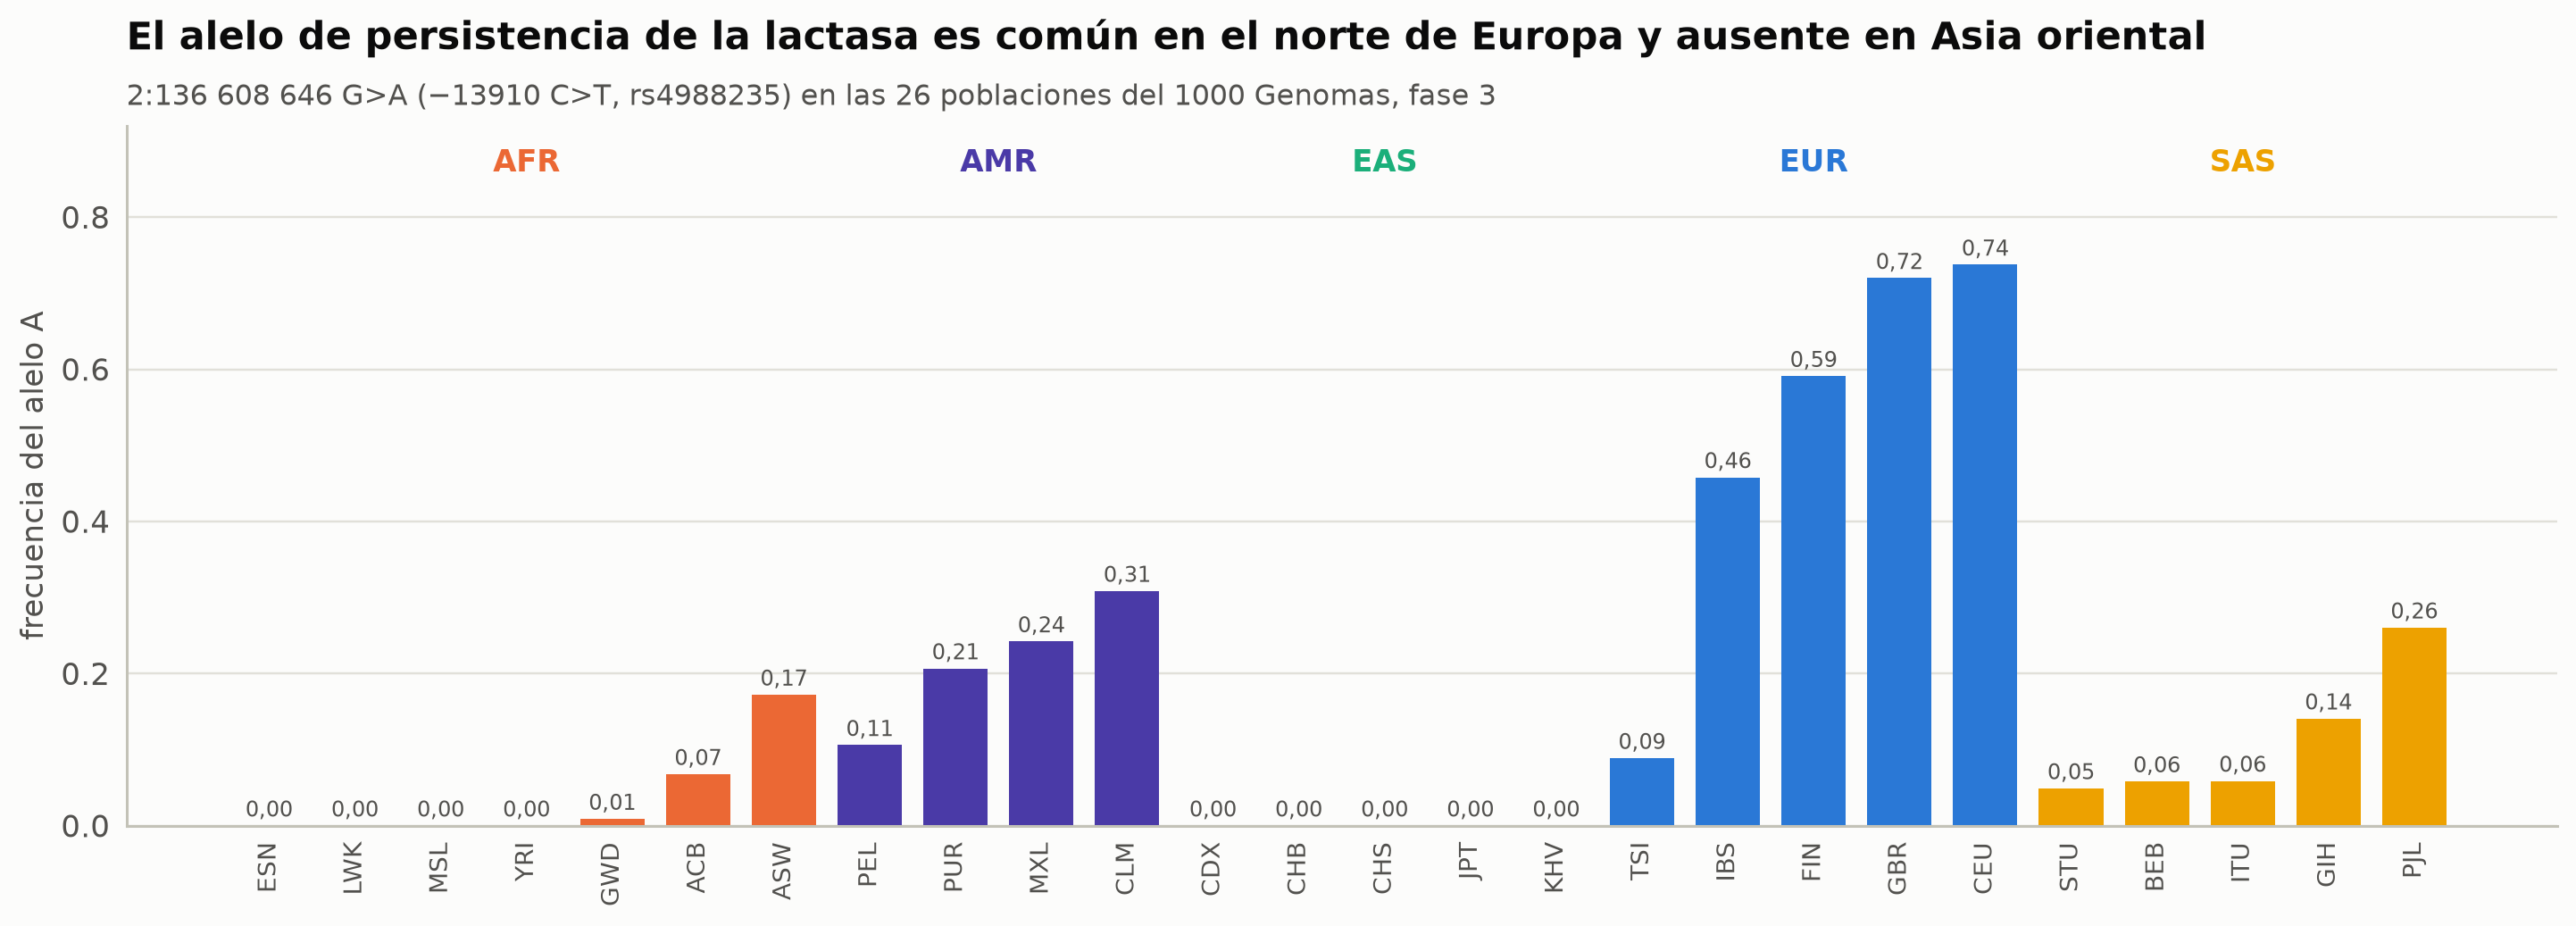

In [15]:
# Polarizar: 1 = alelo derivado (si el ancestral es el ALT, se invierte la columna)
flip = anc == np.array(alt)
Hd = np.where(flip[None, :], 1 - H, H).astype(np.int8)
print(f"SNP con ancestral conocido: {np.isin(anc, list('ACGT')).sum()} de {len(anc)}; columnas invertidas: {flip.sum()}")

freq_pop = (pd.DataFrame({"pop": hap_pop, "sup": hap_sup, "A": H[:, core]})
            .groupby(["sup", "pop"])["A"].mean().reset_index().sort_values(["sup", "A"]))
freq_sup = pd.Series(H[:, core]).groupby(hap_sup).mean()
print("Frecuencia del alelo A (persistencia) por superpoblación:", freq_sup.round(3).to_dict())

fig, ax = plt.subplots(figsize=(13, 4.6))
xx = np.arange(len(freq_pop))
ax.bar(xx, freq_pop["A"], color=[SUPER_COLORS[s] for s in freq_pop["sup"]], width=0.75)
for i, (p_, v) in enumerate(zip(freq_pop["pop"], freq_pop["A"])):
    ax.text(i, v + 0.012, f"{v:.2f}".replace(".", ","), ha="center", fontsize=8, color=ec.INK_2)
ax.set_xticks(xx, freq_pop["pop"], rotation=90, fontsize=9)
for s in SUPER_COLORS:
    sel = np.where(freq_pop["sup"].values == s)[0]
    ax.text(sel.mean(), 0.86, s, ha="center", fontsize=11, fontweight="bold", color=SUPER_COLORS[s])
ax.set_ylim(0, 0.92); ax.set_ylabel("frecuencia del alelo A")
ec.title(ax, "El alelo de persistencia de la lactasa es común en el norte de Europa y ausente en Asia oriental",
         "2:136 608 646 G>A (−13910 C>T, rs4988235) en las 26 poblaciones del 1000 Genomas, fase 3")
plt.show()

> 🔎 **Qué observamos.** El alelo A alcanza su máximo en poblaciones del norte y centro de Europa (CEU, GBR, FIN) y
> es menor en el sur (IBS y, sobre todo, TSI); en Asia meridional llega a 0,26 en PJL (Pakistán) y en Asia oriental
> no aparece en ninguno de los 1 008 cromosomas. En las Américas y en
> las poblaciones africanas de la diáspora (ASW, ACB), donde aparece, lo hace por ancestría europea reciente: en las
> poblaciones del continente africano es muy raro, porque allí la persistencia depende de otras variantes.

### 4.3 Genotipos frente a haplotipos, con datos reales

Antes de dibujar mapas de LD comprobemos la advertencia de la sección 3.3. Para los europeos calculamos $r^2$ de dos
maneras: con los **haplotipos faseados** (lo correcto) y con las **dosis genotípicas** 0/1/2 (lo que haría PLINK
sin fase).

pares de SNP: 205,120   correlación entre ambos r²: 0.9964   diferencia media |Δr²| = 0.0227


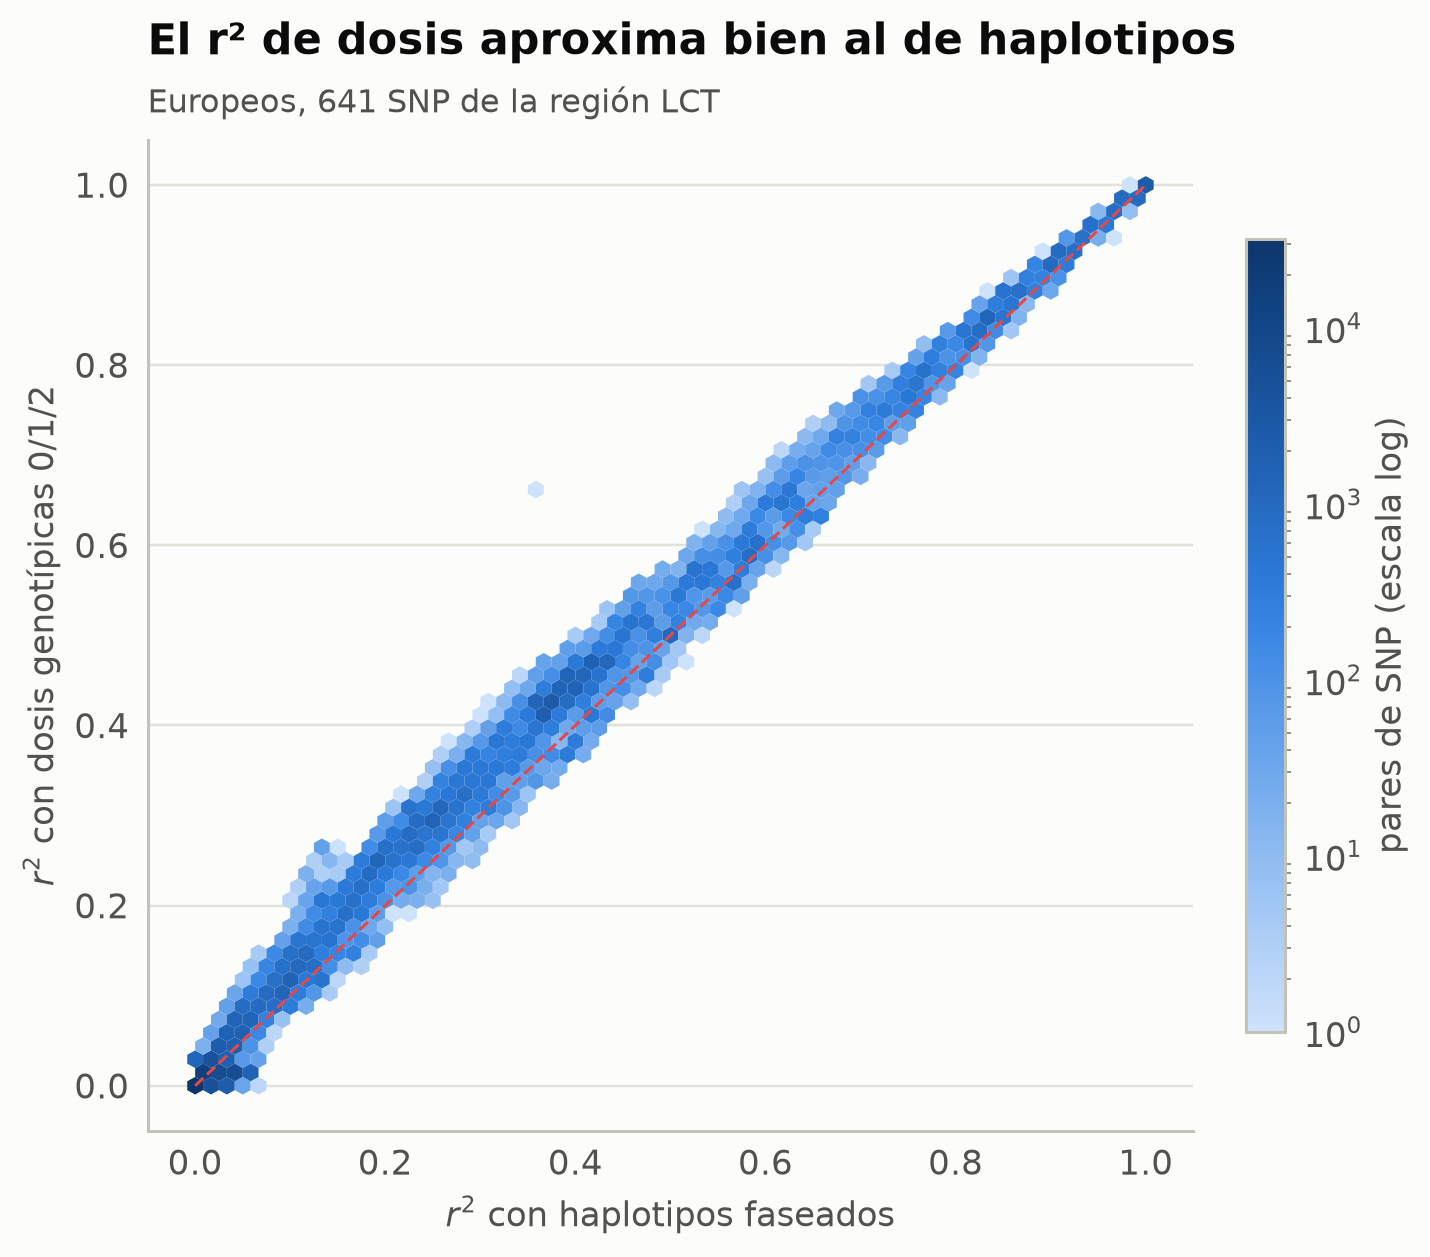

In [16]:
eur = hap_sup == "EUR"
He = H[eur].astype(float)
f_e = He.mean(0); ok_e = (f_e > 0.05) & (f_e < 0.95)
R2_hap = np.corrcoef(He[:, ok_e].T) ** 2
G_e = He[0::2] + He[1::2]                            # dosis de cada persona: suma de sus dos haplotipos
R2_gen = np.corrcoef(G_e[:, ok_e].T) ** 2
iu_e = np.triu_indices(ok_e.sum(), 1)
a_, b_ = R2_hap[iu_e], R2_gen[iu_e]
print(f"pares de SNP: {len(a_):,}   correlación entre ambos r²: {np.corrcoef(a_, b_)[0, 1]:.4f}   "
      f"diferencia media |Δr²| = {np.abs(a_ - b_).mean():.4f}")

fig, ax = plt.subplots(figsize=(6.4, 5.6))
hb = ax.hexbin(a_, b_, gridsize=60, bins="log", cmap=ec.CMAP_SEQ, mincnt=1, linewidths=0)
ax.plot([0, 1], [0, 1], color=ec.RED, lw=1, ls="--")
ax.set_xlabel("$r^2$ con haplotipos faseados"); ax.set_ylabel("$r^2$ con dosis genotípicas 0/1/2")
cb = plt.colorbar(hb, ax=ax, shrink=0.8); cb.set_label("pares de SNP (escala log)")
ec.title(ax, "El r² de dosis aproxima bien al de haplotipos", f"Europeos, {ok_e.sum()} SNP de la región LCT")
plt.show()

> 🔎 **Qué observamos.** Los puntos se agrupan en la diagonal: para **$r^2$**, las dosis son una buena aproximación
> (el valor exacto difiere un poco porque la dosis mezcla la correlación dentro y entre los dos cromosomas de cada
> persona). $D'$, en cambio, no se puede calcular sin saber qué alelos van en el mismo cromosoma.

### 4.4 Mapas de LD por continente

Ahora calculamos, para cada continente, la matriz completa de $r^2$ entre los SNP polimórficos (frecuencia del alelo
menor > 5 % en esa población) y la dibujamos a **escala física**: cada SNP ocupa el tramo de cromosoma que le
corresponde. Marcamos el SNP núcleo y la posición aproximada de los genes *LCT* y *MCM6* (ambos en la hebra menos).

> 🤔 **Antes de ejecutar, prediga.** ¿En qué continente espera los bloques de LD más grandes alrededor del SNP de la
> lactasa? ¿Y los más pequeños?

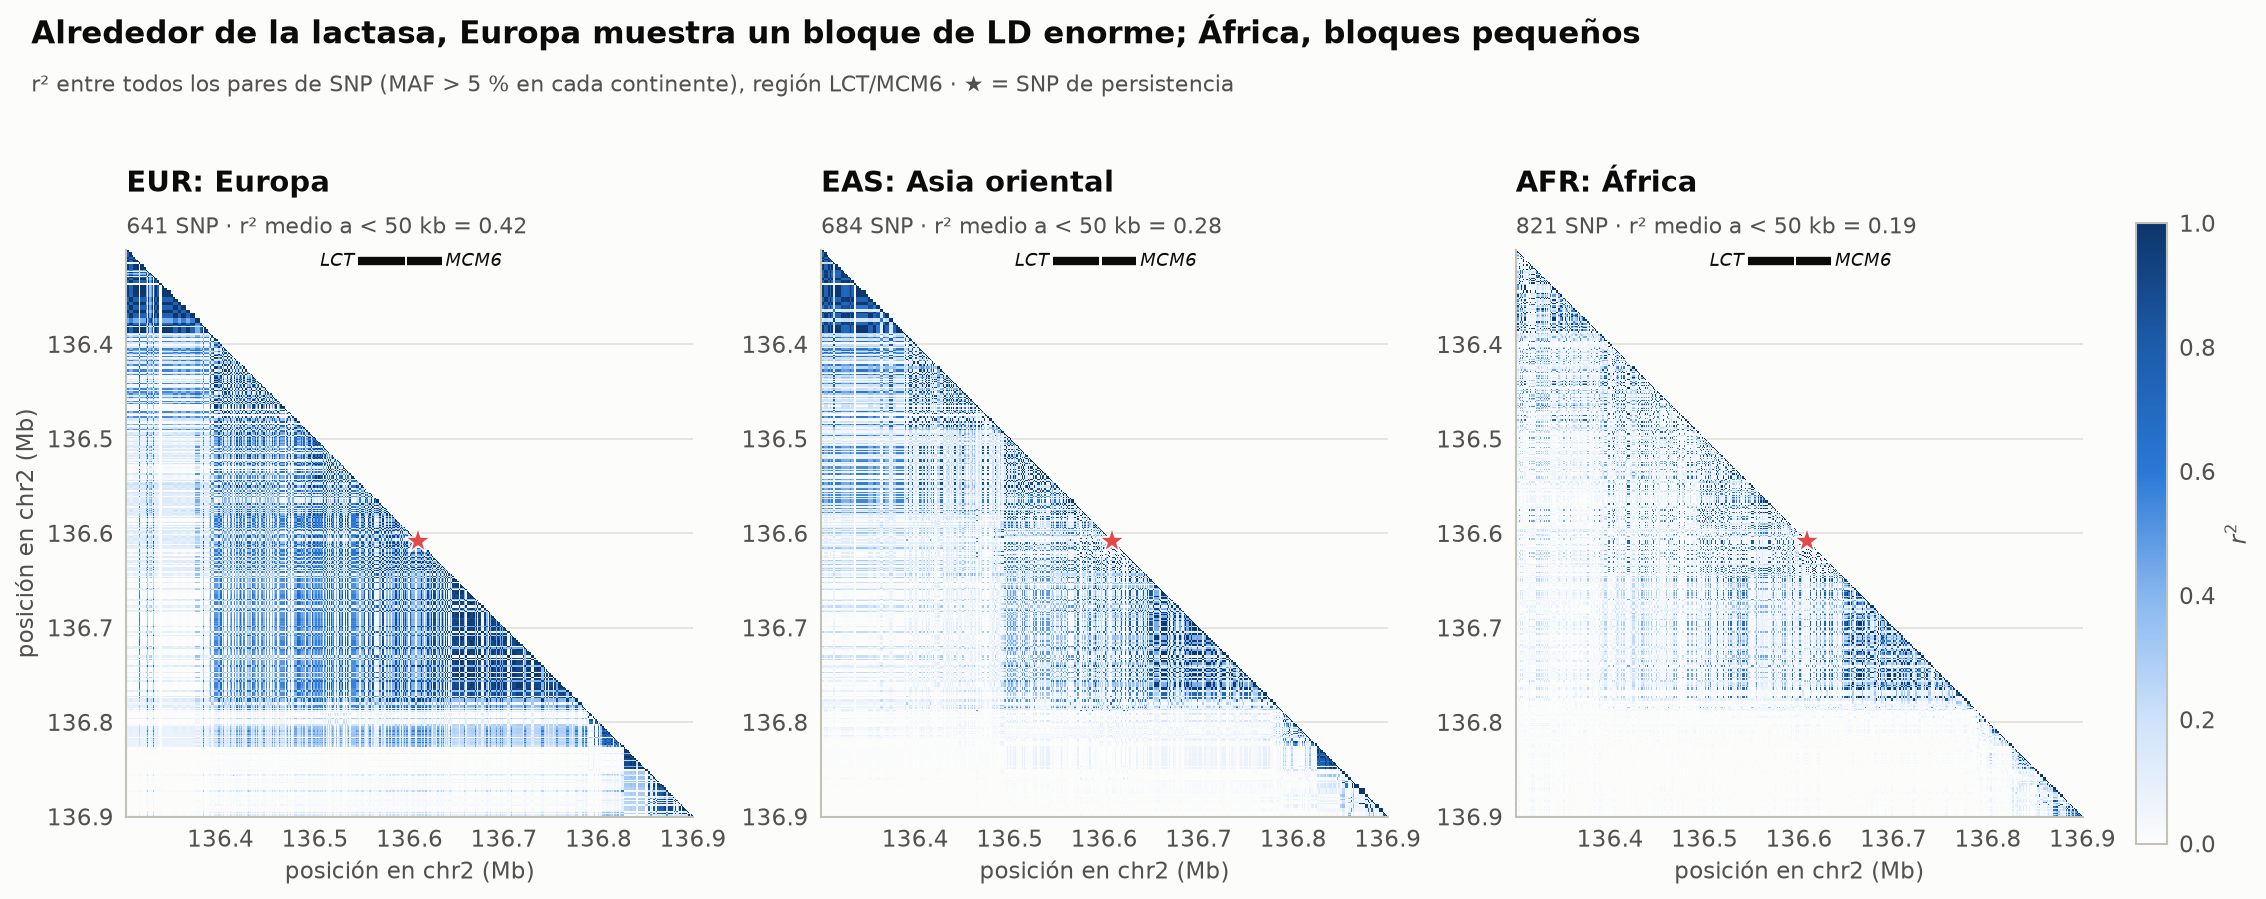

In [17]:
GENES = {"LCT": (136_545_415, 136_594_750), "MCM6": (136_597_196, 136_634_047)}   # GRCh37, aproximado
def r2_matrix(sup):
    Hs = H[hap_sup == sup].astype(float)
    f = Hs.mean(0); ok = (f > 0.05) & (f < 0.95)
    return np.corrcoef(Hs[:, ok].T) ** 2, pos[ok]

fig, axes = plt.subplots(1, 3, figsize=(15, 5.6))
for ax, sup in zip(axes, ["EUR", "EAS", "AFR"]):
    R, ps = r2_matrix(sup)
    edges = np.r_[ps[0] - 250, (ps[1:] + ps[:-1]) / 2, ps[-1] + 250] / 1e6
    Rl = np.where(np.triu(np.ones_like(R, bool), 1), np.nan, R)       # sólo triángulo inferior
    mesh = ax.pcolormesh(edges, edges, Rl, cmap=CM_R2, vmin=0, vmax=1, rasterized=True)
    ax.set_xlim(edges[0], edges[-1]); ax.set_ylim(edges[-1], edges[0]); ax.set_aspect("equal")
    for g, (s0, s1) in GENES.items():
        ax.plot([s0 / 1e6, s1 / 1e6], [edges[0] + 0.012] * 2, color=ec.INK, lw=4, solid_capstyle="butt")
        ax.text(s0 / 1e6 - 0.004 if g == "LCT" else s1 / 1e6 + 0.004, edges[0] + 0.012, g,
                ha="right" if g == "LCT" else "left", va="center", fontsize=8.5, style="italic")
    ax.plot(CORE_POS / 1e6, CORE_POS / 1e6, marker="*", ms=13, color=ec.RED, mec="white", mew=0.8)
    iu_ = np.triu_indices(len(ps), 1)
    near = np.abs(ps[:, None] - ps[None, :])[iu_] < 50_000
    ax.set_xlabel("posición en chr2 (Mb)"); ax.set_ylabel("posición en chr2 (Mb)" if sup == "EUR" else "")
    ec.title(ax, f"{sup}: {SUPER_NAMES[sup]}", f"{len(ps)} SNP · r² medio a < 50 kb = {R[iu_][near].mean():.2f}")
cb = fig.colorbar(mesh, ax=axes, shrink=0.75, pad=0.01); cb.set_label("$r^2$")
fig.set_dpi(75)                                              # figura densa: resolución moderada
ec.fig_title(fig, "Alrededor de la lactasa, Europa muestra un bloque de LD enorme; África, bloques pequeños",
             "r² entre todos los pares de SNP (MAF > 5 % en cada continente), región LCT/MCM6 · ★ = SNP de persistencia")
plt.show()

> 🔎 **Qué observamos.** En los tres continentes hay estructura de bloques (cuadrados azules a lo largo de la
> diagonal), pero su tamaño cambia mucho. En Europa, un bloque de LD alto cubre cientos de kilobases alrededor de
> *LCT*/*MCM6*; en Asia oriental los bloques son intermedios; en África, pequeños y fragmentados. Hay dos
> explicaciones que se suman: el **tamaño efectivo** histórico, mayor en África (ecuación 10-sved), y, en Europa, el
> **barrido selectivo** de la lactasa, que arrastró un haplotipo entero a alta frecuencia. Las fronteras comunes a
> los tres paneles marcan probablemente **puntos calientes de recombinación** compartidos.

### 🎛️ Mapa de LD interactivo

Para explorar pares concretos, un mapa interactivo con 150 SNP repartidos por la región (incluido el SNP
núcleo). El menú cambia de continente; al pasar el ratón por una celda verá las dos posiciones, su distancia, $r^2$,
$\lvert D'\rvert$ y las frecuencias del alelo alternativo. Las celdas grises son pares con un SNP **monomórfico** en
esa población: sin variación no hay LD que medir.

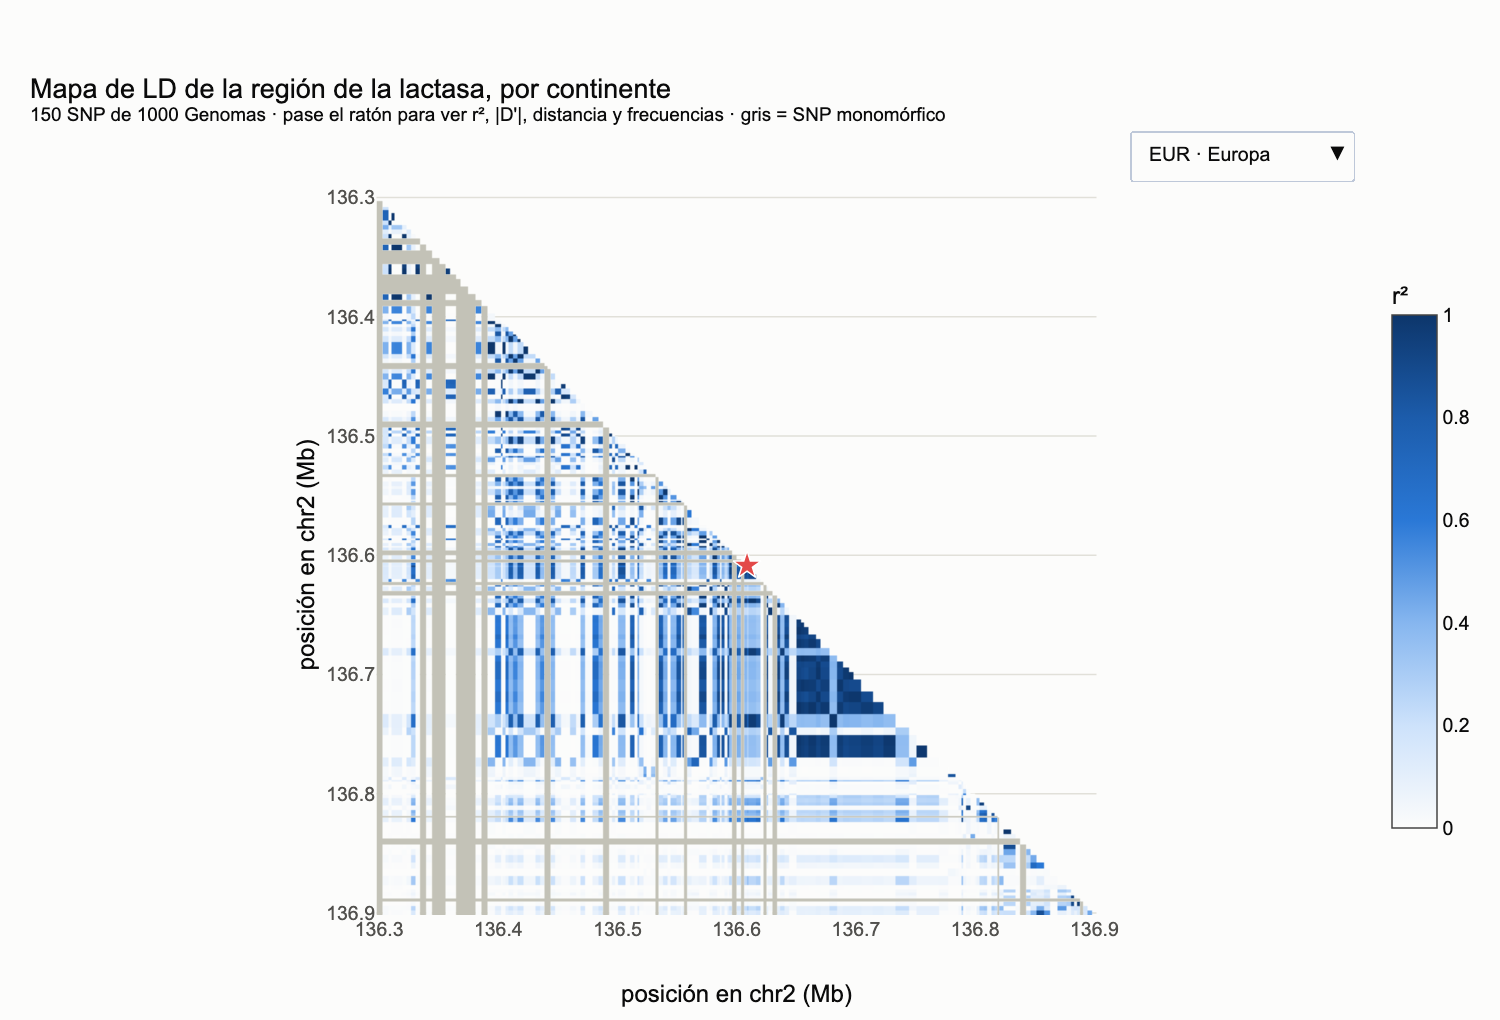

In [18]:
cand = np.where((H.mean(0) > 0.05) & (H.mean(0) < 0.95))[0]
sel = np.unique(np.r_[cand[np.linspace(0, len(cand) - 1, 149).astype(int)], core])
ps_sel = pos[sel]
def ld_all(Hs):
    """r² y |D'| de todos los pares (vectorizado) y las frecuencias alélicas."""
    p = Hs.mean(0)
    pab = (Hs.T @ Hs) / len(Hs)
    D = pab - np.outer(p, p)
    var = p * (1 - p)
    with np.errstate(divide="ignore", invalid="ignore"):
        r2 = D ** 2 / np.outer(var, var)
        dmax = np.where(D >= 0, np.minimum(np.outer(p, 1 - p), np.outer(1 - p, p)),
                        np.minimum(np.outer(p, p), np.outer(1 - p, 1 - p)))
        dp = np.abs(D) / dmax
    poly = (p > 0.01) & (p < 0.99)                                     # monomórfico → sin LD medible
    bad = ~np.outer(poly, poly)
    r2[bad] = np.nan; dp[bad] = np.nan
    return r2, dp, p

fig = go.Figure()
n_sel = len(sel)
dist_kb = np.abs(ps_sel[:, None] - ps_sel[None, :]) / 1e3
for k, sup in enumerate(["EUR", "EAS", "AFR"]):
    r2s, dps, ps_f = ld_all(H[hap_sup == sup][:, sel].astype(float))
    lower = np.tril(np.ones((n_sel, n_sel), bool), -1)
    z = np.where(lower, r2s, None)
    cd = np.dstack([np.round(dps, 3), dist_kb, np.tile(ps_f, (n_sel, 1)), np.tile(ps_f[:, None], (1, n_sel))])
    fig.add_trace(go.Heatmap(
        z=z, x=ps_sel / 1e6, y=ps_sel / 1e6, customdata=cd, colorscale=[[0, "#FCFCFB"], [0.2, "#CDE2FB"],
        [0.4, "#86B6EF"], [0.6, "#2A78D6"], [0.8, "#1C5CAB"], [1, "#0D366B"]], zmin=0, zmax=1, visible=(k == 0),
        colorbar=dict(title="r²", len=0.8), name=sup,
        hovertemplate=("SNP 1: %{x:.4f} Mb (frec. alt. %{customdata[2]:.2f})<br>SNP 2: %{y:.4f} Mb "
                       "(frec. alt. %{customdata[3]:.2f})<br>distancia: %{customdata[1]:.1f} kb<br>"
                       "<b>r² = %{z:.2f}</b> · |D'| = %{customdata[0]:.2f}<extra>" + sup + "</extra>")))
    mono = np.where(lower & np.isnan(r2s), 1.0, None)                  # pares con un SNP monomorfo
    fig.add_trace(go.Heatmap(z=mono, x=ps_sel / 1e6, y=ps_sel / 1e6, colorscale=[[0, ec.BASELINE], [1, ec.BASELINE]],
                             showscale=False, visible=(k == 0), name=sup + " monomórfico",
                             hovertemplate="%{x:.4f} Mb × %{y:.4f} Mb<br>un SNP es monomórfico en " + sup
                                           + ": no hay LD que medir<extra></extra>"))
fig.add_trace(go.Scatter(x=[CORE_POS / 1e6], y=[CORE_POS / 1e6], mode="markers", name="SNP de persistencia (−13910)",
                         marker=dict(symbol="star", size=14, color=ec.RED, line=dict(color="white", width=1)),
                         hovertemplate="2:136 608 646 G>A · alelo de persistencia de la lactasa<extra></extra>"))
buttons = [dict(label=f"{s} · {SUPER_NAMES[s]}", method="update",
                args=[{"visible": [i // 2 == k for i in range(6)] + [True]}]) for k, s in enumerate(["EUR", "EAS", "AFR"])]
fig.update_layout(updatemenus=[dict(buttons=buttons, direction="down", x=1.0, xanchor="right", y=1.02,
                                    yanchor="bottom")],
                  title="Mapa de LD de la región de la lactasa, por continente<br><sup>150 SNP de 1000 Genomas · "
                        "pase el ratón para ver r², |D'|, distancia y frecuencias · gris = SNP monomórfico</sup>",
                  height=680, width=760, margin=dict(t=130, l=80, r=40, b=70),
                  xaxis=dict(title="posición en chr2 (Mb)", constrain="domain"),
                  yaxis=dict(title="posición en chr2 (Mb)", autorange="reversed", scaleanchor="x"),
                  plot_bgcolor=ec.SURFACE, legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0))
fig.show()

> 🔎 **Qué observamos.** Seleccione EAS y busque la estrella: su fila y su columna quedan **grises** porque el alelo de
> persistencia no existe en Asia oriental. En EUR, las celdas cercanas a la estrella tienen $r^2$ alto con SNP a más de
> 100 kb. Compare $\lvert D'\rvert$ y $r^2$ en el hover: muchos pares tienen $\lvert D'\rvert\approx1$ con $r^2$ bajo,
> la firma de frecuencias alélicas distintas.

### 4.5 Curvas de decaimiento del LD por población

Resumimos los mapas en curvas: el $r^2$ medio de los pares de SNP en función de su distancia, para las cinco
superpoblaciones. Como resumen numérico, interpolamos la **distancia a la que el $r^2$ medio cae por debajo de 0,2**
(la cifra que la ecuación 10-sved da a 10 kb para $N_e=10^4$).

AFR: r² medio a 1–2 kb = 0.27 · cae por debajo de 0,2 a ≈    14 kb
AMR: r² medio a 1–2 kb = 0.40 · cae por debajo de 0,2 a ≈   155 kb
EAS: r² medio a 1–2 kb = 0.37 · cae por debajo de 0,2 a ≈    66 kb
EUR: r² medio a 1–2 kb = 0.50 · cae por debajo de 0,2 a ≈   217 kb
SAS: r² medio a 1–2 kb = 0.39 · cae por debajo de 0,2 a ≈    97 kb


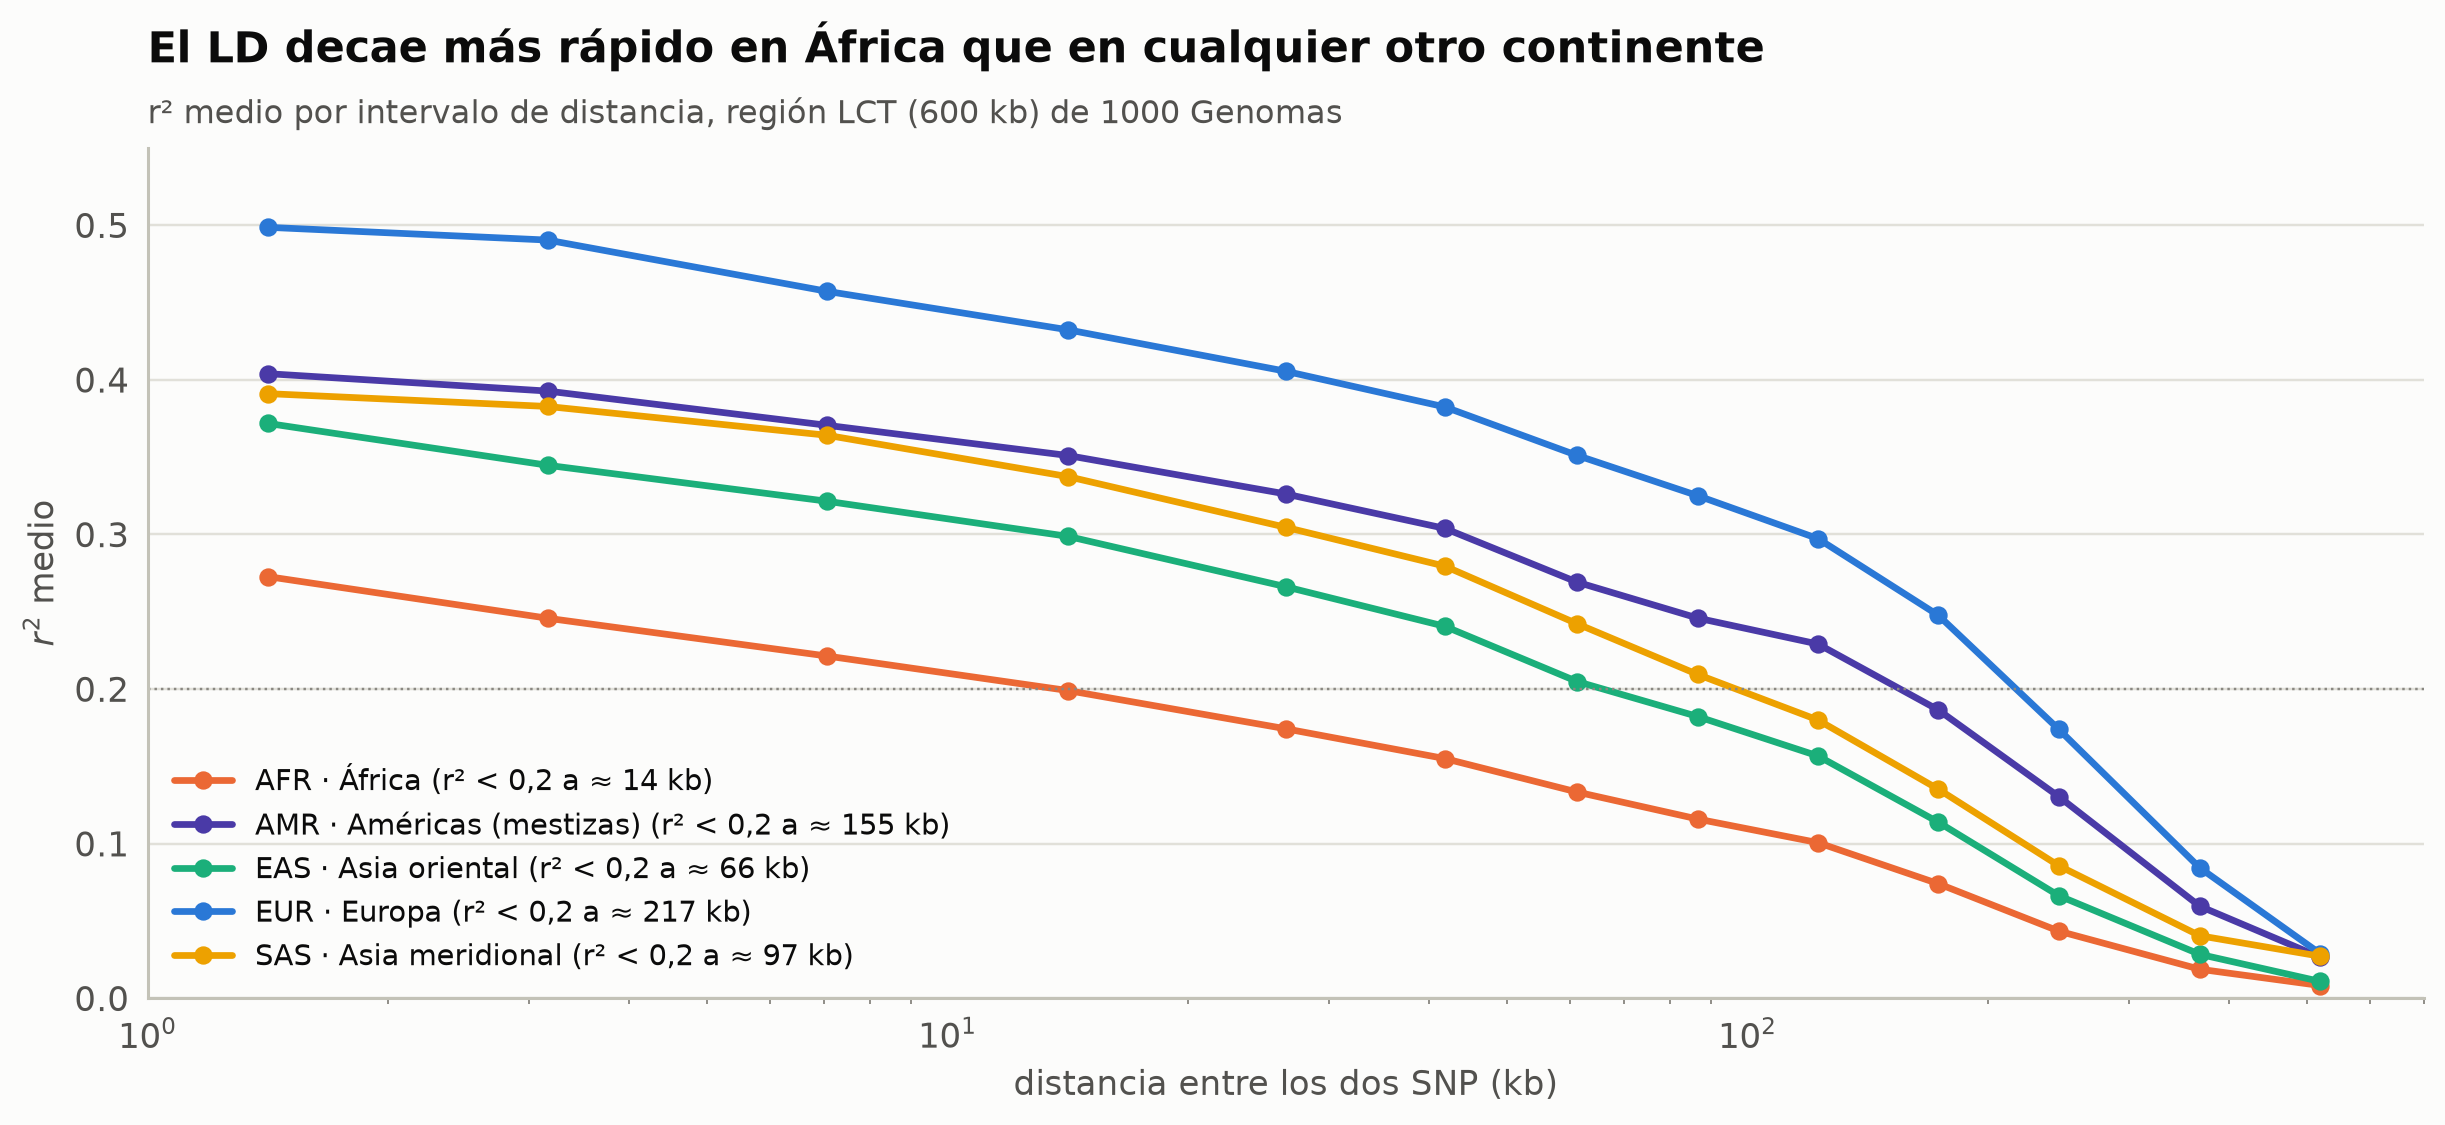

In [19]:
bins = np.array([0, 2, 5, 10, 20, 35, 50, 75, 100, 150, 200, 300, 450, 600]) * 1e3
mid = np.sqrt(np.maximum(bins[:-1], 1e3) * bins[1:]) / 1e3
decay, d02 = {}, {}
for sup in SUPER_COLORS:
    Hs = H[hap_sup == sup].astype(float)
    f = Hs.mean(0); ok = (f > 0.05) & (f < 0.95)
    R = np.corrcoef(Hs[:, ok].T) ** 2; ps = pos[ok]
    iu_ = np.triu_indices(len(ps), 1)
    d = np.abs(ps[:, None] - ps[None, :])[iu_]; r = R[iu_]
    decay[sup] = np.array([r[(d >= bins[i]) & (d < bins[i + 1])].mean() for i in range(len(bins) - 1)])
    k = int(np.argmax(decay[sup] < 0.2))                      # primer intervalo por debajo de 0,2
    d02[sup] = mid[0] if k == 0 else np.exp(np.interp(0.2, [decay[sup][k], decay[sup][k - 1]],
                                                        [np.log(mid[k]), np.log(mid[k - 1])]))
    print(f"{sup}: r² medio a 1–2 kb = {decay[sup][0]:.2f} · cae por debajo de 0,2 a ≈ {d02[sup]:5.0f} kb")

fig, ax = plt.subplots(figsize=(11, 5))
for sup, col in SUPER_COLORS.items():
    ax.plot(mid, decay[sup], "-o", color=col, lw=2.2, ms=5,
            label=f"{sup} · {SUPER_NAMES[sup]} (r² < 0,2 a ≈ {d02[sup]:.0f} kb)")
ax.axhline(0.2, color=ec.MUTED, lw=0.8, ls=":")
ax.set_xscale("log"); ax.set_xlim(1, 700); ax.set_ylim(0, 0.55)
ax.set_xlabel("distancia entre los dos SNP (kb)"); ax.set_ylabel("$r^2$ medio")
ax.legend(frameon=False, loc="lower left", fontsize=9.5)
ec.title(ax, "El LD decae más rápido en África que en cualquier otro continente",
         "r² medio por intervalo de distancia, región LCT (600 kb) de 1000 Genomas")
plt.show()

> 🔎 **Qué observamos.** A cualquier distancia, África tiene el menor $r^2$ medio y Europa el mayor en esta región;
> Asia oriental, las Américas y Asia meridional quedan en medio. El orden coincide con la ecuación 10-sved: las
> poblaciones fuera de África descienden de grupos que pasaron por un **cuello de botella** al salir del continente
> (menor $N_e$, LD más extenso). Pero no generalice desde esta figura: (1) es una sola región de 600 kb y la tasa de
> recombinación local no es uniforme; (2) en Europa, el **barrido selectivo** de la lactasa infla el LD de esta región
> en particular; y (3) las Américas mezclan haplotipos de varios continentes, lo que también crea LD (sección 2). Un
> análisis serio usaría todo el genoma y un mapa de recombinación; con ello se ha estimado, por ejemplo, la historia
> de $N_e$ de cada población.

### 4.6 El haplotipo largo del barrido

La prueba más directa del barrido es **mirar los haplotipos**. Tomamos los 1 006 cromosomas europeos, los separamos
según lleven el alelo A (persistencia) o G en el SNP núcleo y, dentro de cada grupo, los ordenamos por semejanza
empezando por los SNP más cercanos al núcleo. Cada fila es un cromosoma; cada columna, un SNP; el color oscuro, el
alelo **derivado**.

> 🤔 **Antes de ejecutar, prediga.** Si el alelo A subió de frecuencia muy deprisa, ¿cómo se verán los cromosomas A
> comparados con los G?

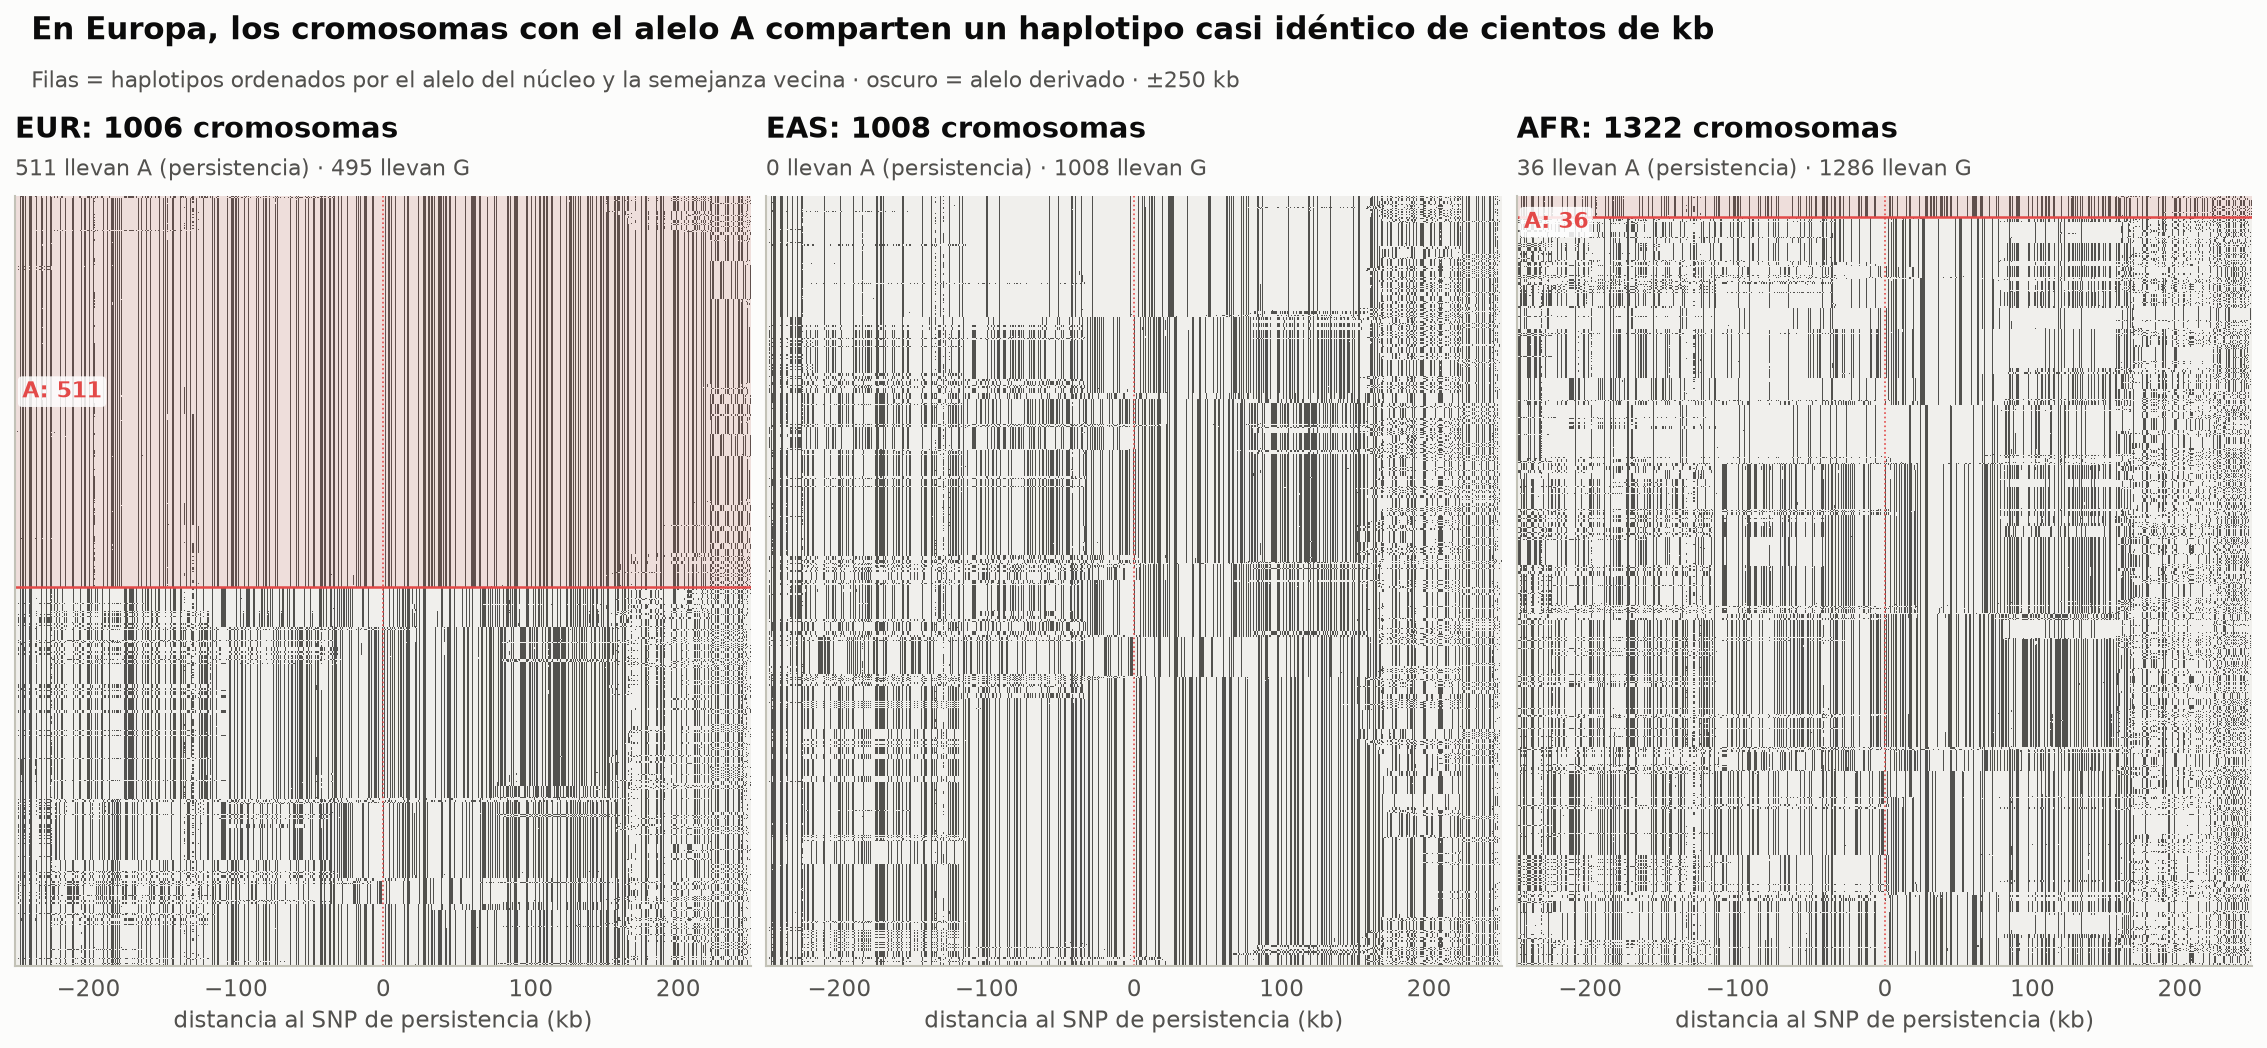

In [20]:
def sort_haplotypes(Hs, core):
    """Ordena haplotipos: primero por el alelo del núcleo (derivado arriba) y luego por los SNP vecinos,
    del más cercano al más lejano (orden lexicográfico)."""
    order_cols = np.argsort(np.abs(np.arange(Hs.shape[1]) - core), kind="stable")   # núcleo, vecinos, …
    # np.lexsort usa la ÚLTIMA clave como la principal: lejanos primero, núcleo al final
    keys = [Hs[:, j] for j in order_cols[1:][::-1]] + [1 - Hs[:, core]]
    return np.lexsort(keys)

win = (pos > CORE_POS - 250_000) & (pos < CORE_POS + 250_000)
cols_w = np.where(win)[0]; core_w = int(np.where(cols_w == core)[0][0])
fig, axes = plt.subplots(1, 3, figsize=(15, 6.2), gridspec_kw=dict(width_ratios=[1, 1, 1]))
cm_h = ListedColormap(["#f0efec", ec.INK_2])
for ax, sup in zip(axes, ["EUR", "EAS", "AFR"]):
    Hs = Hd[hap_sup == sup][:, cols_w]
    Hs_core_is_A = H[hap_sup == sup][:, core]
    Hs = Hs.copy(); Hs[:, core_w] = Hs_core_is_A        # el núcleo, codificado como A = derivado = 1
    o = sort_haplotypes(Hs, core_w)
    ax.imshow(Hs[o], aspect="auto", cmap=cm_h, interpolation="nearest",
              extent=((pos[cols_w[0]] - CORE_POS) / 1e3, (pos[cols_w[-1]] - CORE_POS) / 1e3, len(Hs), 0))
    nA = int(Hs_core_is_A.sum())
    if nA:
        ax.axhspan(0, nA, xmin=0, xmax=1, color=ec.RED, alpha=0.10, lw=0)
        ax.axhline(nA, color=ec.RED, lw=1.2)
        ax.text(-245, max(nA / 2, 45), f"A: {nA}", color=ec.RED, fontsize=10.5, fontweight="bold", va="center",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.85))
    ax.axvline(0, color=ec.RED, lw=0.8, ls=":")
    ax.set_xlabel("distancia al SNP de persistencia (kb)"); ax.set_yticks([])
    ec.title(ax, f"{sup}: {len(Hs)} cromosomas", f"{nA} llevan A (persistencia) · {len(Hs) - nA} llevan G")
fig.set_dpi(75)                                              # figura densa: resolución moderada
ec.fig_title(fig, "En Europa, los cromosomas con el alelo A comparten un haplotipo casi idéntico de cientos de kb",
             "Filas = haplotipos ordenados por el alelo del núcleo y la semejanza vecina · oscuro = alelo derivado · ±250 kb")
plt.show()

> 🔎 **Qué observamos.** En el panel europeo, la franja superior (cromosomas con A) es casi **uniforme** en toda la
> ventana de ±250 kb: más de 500 cromosomas llevan prácticamente la misma secuencia de alelos, heredada de un único
> antepasado reciente. Los cromosomas con G, en cambio, se fragmentan en muchos haplotipos a pocas decenas de
> kilobases del núcleo. En Asia oriental y en África no hay franja A (o es diminuta, por mezcla reciente con
> europeos) y la diversidad es alta. Una variante **común** (51 % en Europa) sobre un haplotipo **largo** es una
> combinación imposible para la deriva neutral: una variante neutral tarda mucho en llegar a esa frecuencia, y
> durante ese tiempo la recombinación habría roto el haplotipo.

### 4.7 Homocigosidad extendida del haplotipo (EHH)

Sabeti et al. (2002) convirtieron esta observación en un estadístico. La **homocigosidad extendida del haplotipo**
(EHH) de un alelo núcleo, a una distancia $x$, es la probabilidad de que dos cromosomas elegidos al azar entre los que
llevan ese alelo sean **idénticos** en todo el tramo entre el núcleo y $x$:

$$
\mathrm{EHH}(x) = \frac{\sum_{h} n_h\,(n_h-1)}{n\,(n-1)},
$$

| Símbolo | Significado |
|---|---|
| $n$ | Número de cromosomas que llevan el alelo núcleo. |
| $h$ | Cada haplotipo distinto del tramo núcleo–$x$; $n_h$, cuántos cromosomas lo llevan. |

En el núcleo, $\mathrm{EHH}=1$ (todos llevan el mismo alelo); al alejarse, la recombinación y la mutación crean
haplotipos distintos y el EHH decae. Bajo un barrido, el alelo favorecido conserva EHH alto mucho más lejos que su
alternativo. De aquí nacen pruebas de selección de todo el genoma como iHS, que comparan el área bajo estas curvas.

EUR · alelo A (persistencia) n =  511 · tramo con EHH ≥ 0,25:  441.7 kb
EUR · alelo G                n =  495 · tramo con EHH ≥ 0,25:   41.2 kb
EAS · alelo G                n = 1008 · tramo con EHH ≥ 0,25:   10.1 kb
AFR · alelo G                n = 1286 · tramo con EHH ≥ 0,25:    8.9 kb


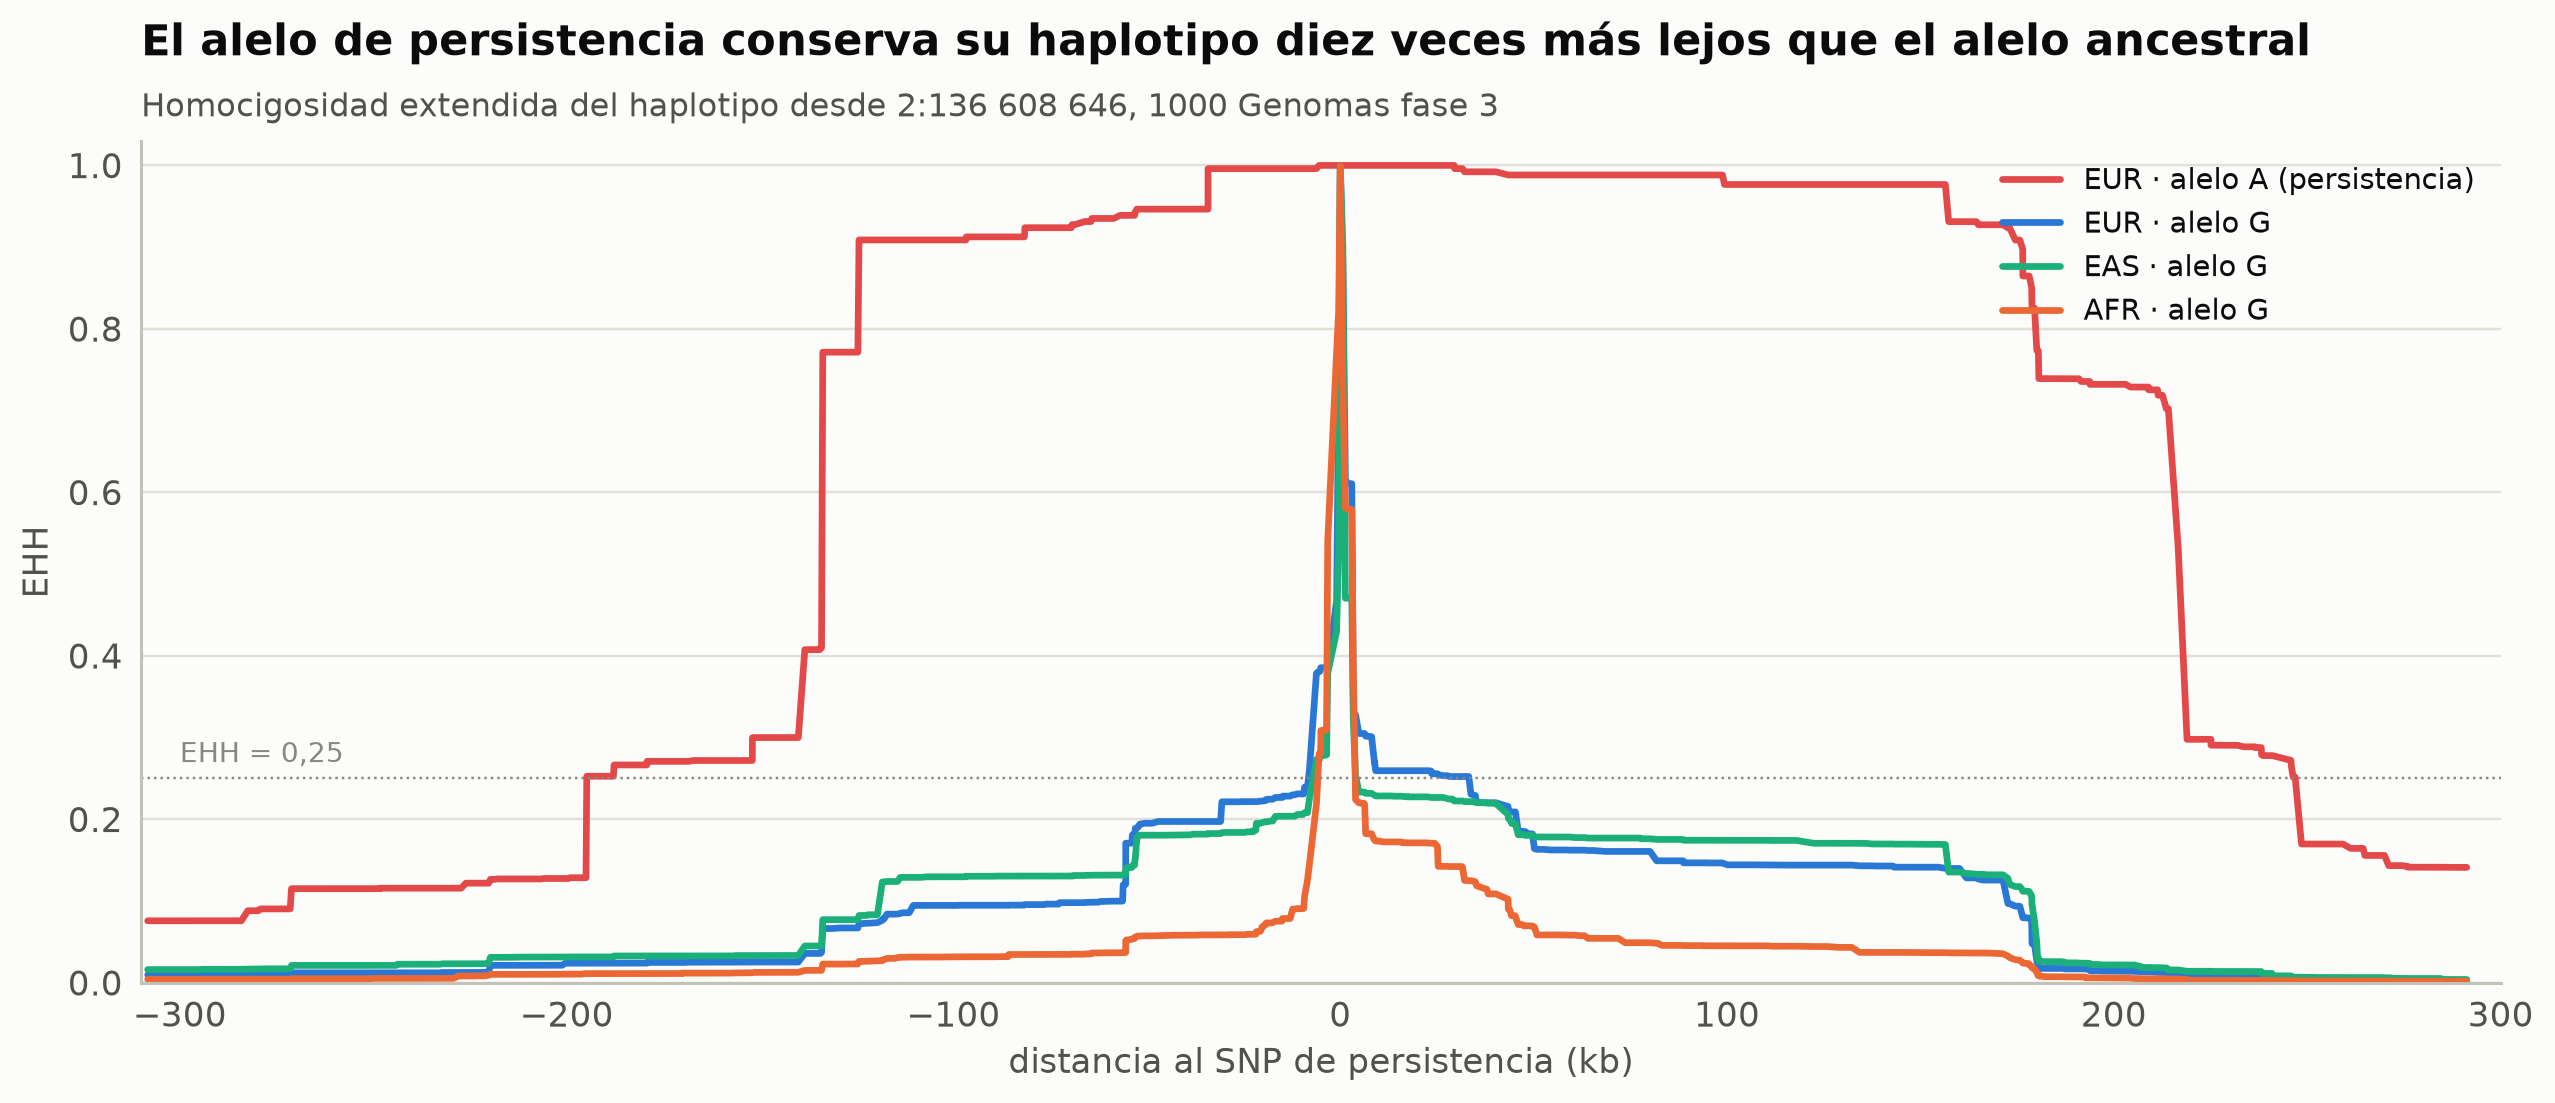

In [21]:
def ehh_curve(Hs, core, direction):
    """EHH desde el núcleo hacia un lado. Etiqueta cada haplotipo con un entero que se actualiza SNP a SNP."""
    lab = np.zeros(len(Hs), np.int64); out_pos, out_e = [], []
    n = len(Hs)
    stop = Hs.shape[1] if direction > 0 else -1
    for j in range(core, stop, direction):
        _, lab = np.unique(lab * 2 + Hs[:, j], return_inverse=True)    # ¿sigue igual el haplotipo hasta j?
        cnt = np.bincount(lab)
        out_pos.append(pos[j]); out_e.append((cnt * (cnt - 1)).sum() / (n * (n - 1)))
    return np.array(out_pos), np.array(out_e)

fig, ax = plt.subplots(figsize=(11.5, 4.9))
curves_def = [("EUR", 1, ec.RED, "EUR · alelo A (persistencia)"), ("EUR", 0, ec.BLUE, "EUR · alelo G"),
              ("EAS", 0, ec.AQUA, "EAS · alelo G"), ("AFR", 0, ec.ORANGE, "AFR · alelo G")]
ehh_len = {}
for sup, allele, col, lab in curves_def:
    Hs = H[hap_sup == sup]
    Hs = Hs[Hs[:, core] == allele]
    xl, el = ehh_curve(Hs, core, -1); xr, er = ehh_curve(Hs, core, +1)
    xs = np.r_[xl[::-1], xr[1:]]; es = np.r_[el[::-1], er[1:]]
    ax.plot((xs - CORE_POS) / 1e3, es, color=col, lw=2.2)
    above = xs[es >= 0.25]
    ehh_len[lab] = (above.max() - above.min()) / 1e3
    print(f"{lab:<28} n = {len(Hs):>4} · tramo con EHH ≥ 0,25: {ehh_len[lab]:6.1f} kb")
ax.axhline(0.25, color=ec.MUTED, lw=0.8, ls=":"); ax.text(-300, 0.27, "EHH = 0,25", fontsize=9, color=ec.MUTED)
ax.legend([plt.Line2D([], [], color=c, lw=2.2) for _, _, c, _ in curves_def], [l for *_, l in curves_def],
          frameon=False, loc="upper right", fontsize=9.5)
ax.set_xlim(-310, 300); ax.set_ylim(0, 1.03)
ax.set_xlabel("distancia al SNP de persistencia (kb)"); ax.set_ylabel("EHH")
ec.title(ax, "El alelo de persistencia conserva su haplotipo diez veces más lejos que el alelo ancestral",
         "Homocigosidad extendida del haplotipo desde 2:136 608 646, 1000 Genomas fase 3")
plt.show()

> 🔎 **Qué observamos.** Para el alelo G, en cualquier continente, el EHH cae por debajo de 0,25 a unas pocas decenas
> de kilobases del núcleo. Para el alelo A en Europa, el EHH se mantiene por encima de 0,25 en un tramo de
> **cientos de kilobases**, y en los bordes de nuestra ventana todavía no ha desaparecido: el haplotipo del barrido es
> más largo que la región que descargamos (Bersaglieri et al. describieron un haplotipo que se extiende más de 1 Mb).
> Es la huella de un alelo que pasó de raro a común en pocos miles de años.

> ✅ **Compruebe su comprensión.** Un colega encuentra un SNP con frecuencia 0,5 en una población y un EHH que cae
> tan rápido como el de su alelo alternativo. ¿Hay evidencia de un barrido reciente? *(No: la frecuencia alta con
> haplotipo corto es lo esperado para un alelo antiguo, que tuvo tiempo de recombinar. La firma de un barrido es la
> **combinación** de frecuencia alta y haplotipo largo, o una diferencia de EHH entre los dos alelos.)*

## 5. Estructura poblacional y $F_{ST}$

### 5.1 La humanidad no es una sola población panmíctica

La Lección 10.1 supuso una población **panmíctica**: cualquiera se aparea con cualquiera. La humanidad no lo es: la
geografía, la historia y la cultura hacen que las personas se apareen preferentemente con otras de su misma región,
y las frecuencias alélicas **derivan de manera independiente** en cada grupo. Ya vimos una consecuencia: al juntar
dos poblaciones con frecuencias distintas aparece un déficit de heterocigotos (efecto Wahlund). Wright (1931)
cuantificó esta subdivisión con el **índice de fijación** $F_{ST}$: la reducción de heterocigosidad dentro de las
subpoblaciones respecto a la que tendría la población total si fuera panmíctica (ecuación 10-fst):

$$
F_{ST} = \frac{H_T - H_S}{H_T} = \frac{\operatorname{Var}(p_k)}{\bar p\,(1-\bar p)}. \tag{10-fst}
$$

| Símbolo | Significado |
|---|---|
| $H_T$ | Heterocigosidad esperada con las frecuencias de la población total, $2\bar p(1-\bar p)$. |
| $H_S$ | Promedio de las heterocigosidades esperadas dentro de cada subpoblación, $2p_k(1-p_k)$. |
| $p_k,\ \bar p$ | Frecuencia alélica en la subpoblación $k$ y su media ponderada. |

**Un ejemplo a mano.** Dos aldeas del mismo tamaño; en la primera el alelo tiene frecuencia $p_1=0{,}2$ y en la
segunda $p_2=0{,}8$. Entonces $\bar p=0{,}5$ y:

* $H_T=2\cdot0{,}5\cdot0{,}5=0{,}50$;
* $H_S=\tfrac12\,(2\cdot0{,}2\cdot0{,}8+2\cdot0{,}8\cdot0{,}2)=0{,}32$;
* $F_{ST}=(0{,}50-0{,}32)/0{,}50=0{,}36$.

Con la segunda forma: $\operatorname{Var}(p_k)=\tfrac12[(0{,}2-0{,}5)^2+(0{,}8-0{,}5)^2]=0{,}09$ y
$0{,}09/0{,}25=0{,}36$. Las dos formas coinciden porque $H_T-H_S=2\operatorname{Var}(p_k)$: $F_{ST}$ es **la
varianza de las frecuencias entre subpoblaciones normalizada por su máximo posible** ($\bar p(1-\bar p)$, que se
alcanza cuando cada subpoblación está fijada para un alelo).

In [22]:
def fst_wright(pk, weights=None):
    """F_ST de Wright (ecuación 10-fst) para un locus: pk = frecuencias en cada subpoblación."""
    pk = np.asarray(pk, float)
    w = np.full(len(pk), 1 / len(pk)) if weights is None else np.asarray(weights) / np.sum(weights)
    pbar = (w * pk).sum()
    HT = 2 * pbar * (1 - pbar); HS = (w * 2 * pk * (1 - pk)).sum()
    var = (w * (pk - pbar) ** 2).sum()
    return (HT - HS) / HT, var / (pbar * (1 - pbar))

print("Ejemplo de las dos aldeas: F_ST (forma H) = %.2f · (forma varianza) = %.2f" % fst_wright([0.2, 0.8]))
print("Si ambas tuvieran 0,5:       F_ST = %.2f" % fst_wright([0.5, 0.5])[0])
print("Si estuvieran fijadas (0/1): F_ST = %.2f" % fst_wright([0.0, 1.0])[0])

Ejemplo de las dos aldeas: F_ST (forma H) = 0.36 · (forma varianza) = 0.36
Si ambas tuvieran 0,5:       F_ST = 0.00
Si estuvieran fijadas (0/1): F_ST = 1.00


### 5.2 $F_{ST}$ crece con la deriva

¿De dónde sale la diferencia entre subpoblaciones? De la **deriva**. En el modelo de Wright-Fisher (Lección 10.1),
subpoblaciones aisladas de tamaño $N$ acumulan

$$
F_{ST}\approx 1-\Bigl(1-\frac{1}{2N}\Bigr)^t\approx \frac{t}{2N}
$$

al cabo de $t$ generaciones de separación: es el mismo $F_t$ (la pérdida de heterocigosidad) de la ecuación 10-ibd.
Comprobémoslo con 200 islas de $N=100$ que parten todas de $p=0{,}5$:

> 🤔 **Antes de ejecutar, prediga.** ¿Cuánto valdrá $F_{ST}$ tras 50 generaciones? ¿Y tras 200?

t =  10: F_ST simulado = 0.043 · teoría 1-(1-1/2N)^t = 0.049 · t/2N = 0.050
t =  50: F_ST simulado = 0.209 · teoría 1-(1-1/2N)^t = 0.222 · t/2N = 0.250
t = 200: F_ST simulado = 0.640 · teoría 1-(1-1/2N)^t = 0.633 · t/2N = 1.000


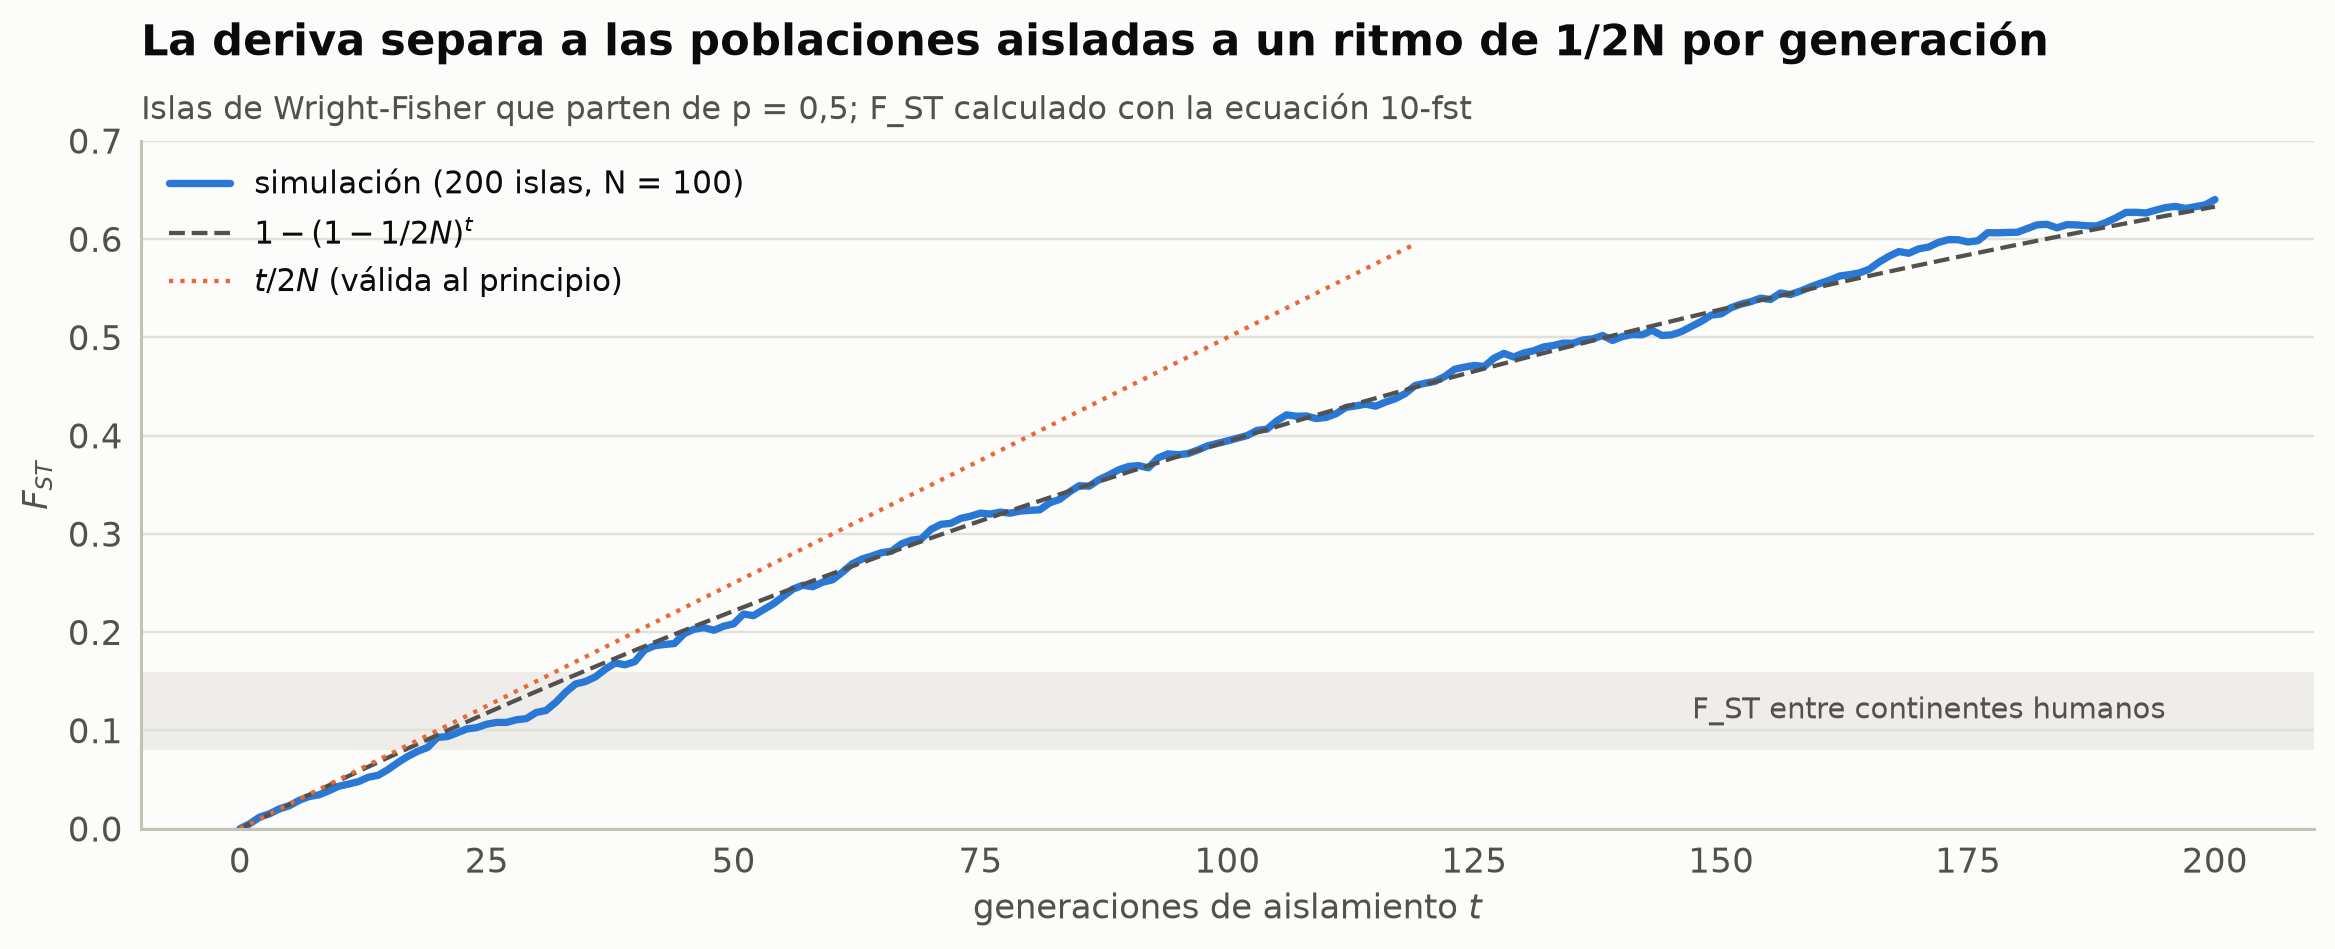

In [23]:
rng_f = np.random.default_rng(10)
N, n_islands, T = 100, 200, 200
p_isl = np.full(n_islands, 0.5); fst_t = [0.0]
for t_ in range(T):
    p_isl = rng_f.binomial(2 * N, p_isl) / (2 * N)          # deriva binomial en cada isla
    fst_t.append(fst_wright(p_isl)[1])
fst_t = np.array(fst_t); tt_ = np.arange(T + 1)
for tq in (10, 50, 200):
    print(f"t = {tq:>3}: F_ST simulado = {fst_t[tq]:.3f} · teoría 1-(1-1/2N)^t = {1 - (1 - 1 / (2 * N)) ** tq:.3f}"
          f" · t/2N = {tq / (2 * N):.3f}")
fig, ax = plt.subplots(figsize=(10.5, 4.2))
ax.plot(tt_, fst_t, color=ec.BLUE, lw=2.4, label="simulación (200 islas, N = 100)")
ax.plot(tt_, 1 - (1 - 1 / (2 * N)) ** tt_, color=ec.INK_2, lw=1.4, ls="--", label="$1-(1-1/2N)^t$")
ax.plot(tt_[:120], tt_[:120] / (2 * N), color=ec.ORANGE, lw=1.4, ls=":", label="$t/2N$ (válida al principio)")
ax.axhspan(0.08, 0.16, color=ec.GRID, alpha=0.5, lw=0)
ax.text(195, 0.12, "F_ST entre continentes humanos", ha="right", va="center", fontsize=9.5, color=ec.INK_2)
ax.set_xlabel("generaciones de aislamiento $t$"); ax.set_ylabel("$F_{ST}$"); ax.set_ylim(0, 0.7)
ax.legend(frameon=False, loc="upper left")
ec.title(ax, "La deriva separa a las poblaciones aisladas a un ritmo de 1/2N por generación",
         "Islas de Wright-Fisher que parten de p = 0,5; F_ST calculado con la ecuación 10-fst")
plt.show()

> 🔎 **Qué observamos.** $F_{ST}$ sigue la curva $1-(1-1/2N)^t$; la aproximación lineal $t/2N$ sólo vale mientras
> $F_{ST}$ es pequeño. Las diferencias entre continentes humanos ($F_{ST}\sim0{,}1$, franja gris) equivalen, en este
> modelo simple, a unas pocas decenas de generaciones de aislamiento **con $N=100$**; con los tamaños efectivos
> humanos (miles a decenas de miles), hacen falta miles de generaciones, del orden de la edad de la dispersión fuera de
> África.

### 5.3 Estimar $F_{ST}$ con muestras finitas: Weir y Cockerham

Con muestras finitas, las frecuencias $p_k$ tienen **error de muestreo**, que se suma a la varianza verdadera entre
poblaciones: la ecuación 10-fst aplicada ingenuamente sobreestima $F_{ST}$, sobre todo cuando las muestras son
pequeñas y la diferenciación es débil. El estimador estándar es el de **Weir y Cockerham (1984)**, que descompone la
varianza de las frecuencias en componentes entre poblaciones ($a$), entre individuos dentro de poblaciones ($b$) y
dentro de individuos ($c$), y estima $F_{ST}=\sum a/\sum(a+b+c)$ sumando sobre loci (el «cociente de promedios»).
Un matiz: Weir y Cockerham tratan las poblaciones muestreadas como **réplicas** del proceso evolutivo, así que su
varianza entre poblaciones divide por $r-1$ (el número de poblaciones menos uno), no por $r$ como la ecuación 10-fst
(y nuestra `fst_wright`). Con dos poblaciones, esa diferencia de divisor **duplica** el resultado: la forma literal
del libro, con divisor $r$, daría con muestras grandes aproximadamente la mitad del valor de Weir-Cockerham, y la
comparación no diría nada sobre el muestreo. Para comparar con justicia, nuestra versión «ingenua», `fst_naive`,
**no** es la ecuación 10-fst tal cual: es el cociente de promedios $\sum\widehat{\operatorname{Var}}(p_k)/\sum\bar p(1-\bar p)$
con la varianza muestral de divisor $r-1$, calculada con las frecuencias de la muestra y sin ninguna corrección por el
tamaño de muestra. Ésta es la función del libro para Weir-Cockerham, seguida de la ingenua:

In [24]:
def wc_fst(G1, G2):
    """Weir & Cockerham (1984), dos poblaciones, genotipos 0/1/2 (función del libro)."""
    r = 2
    n = np.array([G1.shape[0], G2.shape[0]], float)
    ps = np.vstack([G1.mean(0) / 2, G2.mean(0) / 2])
    hs = np.vstack([(G1 == 1).mean(0), (G2 == 1).mean(0)])       # heterocigosidad observada
    nbar = n.mean()
    nc = (r * nbar - (n ** 2).sum() / (r * nbar)) / (r - 1)
    pbar = (n[:, None] * ps).sum(0) / (r * nbar)
    s2 = (n[:, None] * (ps - pbar) ** 2).sum(0) / ((r - 1) * nbar)
    hbar = (n[:, None] * hs).sum(0) / (r * nbar)
    a = nbar / nc * (s2 - (pbar * (1 - pbar) - (r - 1) / r * s2 - hbar / 4) / (nbar - 1))
    b = nbar / (nbar - 1) * (pbar * (1 - pbar) - (r - 1) / r * s2 - (2 * nbar - 1) / (4 * nbar) * hbar)
    c = hbar / 2
    return a.sum() / (a + b + c).sum()

def fst_naive(G1, G2):
    """F_ST ingenuo: cociente de promedios Σ Var(p_k) / Σ p̄(1 − p̄) con las frecuencias muestrales, sin corregir
    el muestreo. Como en Weir-Cockerham, la varianza entre poblaciones divide por r − 1 (con dos poblaciones, el
    doble de la forma literal de la ecuación 10-fst, que divide por r)."""
    pk = np.vstack([G1.mean(0) / 2, G2.mean(0) / 2]); pbar = pk.mean(0)
    return pk.var(0, ddof=1).sum() / (pbar * (1 - pbar)).sum()

# Prueba de control: dos muestras de 20 personas de la MISMA población (F_ST verdadero = 0)
rng_c = np.random.default_rng(3)
p_true = rng_c.uniform(0.05, 0.95, 5000)
S1, S2 = rng_c.binomial(2, p_true, (20, 5000)), rng_c.binomial(2, p_true, (20, 5000))
print(f"Misma población, 20 + 20 personas: F_ST ingenuo = {fst_naive(S1, S2):.4f} · Weir-Cockerham = {wc_fst(S1, S2):.4f}")

Misma población, 20 + 20 personas: F_ST ingenuo = 0.0251 · Weir-Cockerham = -0.0001


> 🔎 **Qué observamos.** Sin diferenciación real, la fórmula ingenua da un $F_{ST}$ positivo, del orden de
> $1/(2n)$ con $n$ personas por muestra: puro ruido de muestreo. Weir-Cockerham lo corrige y da prácticamente cero
> (puede salir ligeramente negativo, lo que simplemente significa «ninguna diferenciación detectable»). Con muestras
> de cientos de personas, como las del 1000 Genomas, la diferencia es pequeña pero, dentro de un continente, donde
> $F_{ST}\le0{,}01$, sigue importando.

La aplicaremos a las 26 poblaciones del 1000 Genomas en la sección 7, junto con el PCA.

## 6. Análisis de componentes principales de genotipos

### 6.1 La idea: la mejor fotografía de una nube

Una medida resumen como $F_{ST}$ exige saber de antemano a qué población pertenece cada individuo. A menudo no lo
sabemos, o las poblaciones no son discretas. El **análisis de componentes principales** (PCA) invierte el problema:
encuentra, **sin etiquetas**, los ejes de mayor variación de la matriz de genotipos.

Piense en cada persona como un punto en un espacio con tantas dimensiones como SNP (miles). No podemos ver ese
espacio, pero sí fotografiarlo desde algún ángulo. El PCA elige el ángulo desde el que la nube se ve **más
extendida** (primer componente, PC1); luego, perpendicular a él, el siguiente ángulo más informativo (PC2), y así
sucesivamente. Si hay grupos de personas que comparten frecuencias alélicas, los primeros componentes los separan.
Patterson, Price y Reich (2006) le dieron un tratamiento estadístico riguroso.

### 6.2 La definición

Sea $G$ la matriz $n\times M$ de genotipos ($g_{ij}\in\{0,1,2\}$) de $n$ individuos en $M$ SNP, y $\hat p_j$ la
frecuencia alélica del SNP $j$. Se estandariza cada columna y se descompone la matriz de parentesco (ecuación
10-zpca):

$$
Z_{ij} = \frac{g_{ij}-2\hat p_j}{\sqrt{2\hat p_j(1-\hat p_j)}},
\qquad
\Psi = \frac{1}{M}\,ZZ^{\top} = \sum_{k} \lambda_k\, \mathbf{u}_k\mathbf{u}_k^{\top}, \tag{10-zpca}
$$

y las coordenadas del individuo $i$ en el componente $k$ son $\sqrt{\lambda_k}\,u_{ik}$.

| Símbolo | Significado |
|---|---|
| $G$, $g_{ij}$ | Matriz de genotipos $n\times M$; copias del alelo alternativo del individuo $i$ en el SNP $j$. |
| $\hat p_j$ | Frecuencia alélica estimada del SNP $j$ ($\bar g_j/2$). |
| $Z$ | Matriz de genotipos centrada y escalada: cada SNP con media 0 y varianza 1 bajo HWE. |
| $\Psi$ | Matriz $n\times n$ de parentesco genómico (GRM); $\Psi_{ii'}$ mide cuántos alelos comparten $i$ e $i'$ por encima de lo esperado al azar. |
| $\lambda_k,\ \mathbf{u}_k$ | Autovalores y autovectores de $\Psi$, ordenados de mayor a menor. |

La estandarización da el mismo peso a cada SNP en términos de su varianza esperada, de modo que los SNP raros (cuya
varianza $2\hat p(1-\hat p)$ es pequeña) no quedan ahogados por los comunes. La descomposición de $\Psi$ es, en la
práctica, una **descomposición en valores singulares** (SVD) de $Z=USV^\top$: los autovectores son las columnas de
$U$ y $\lambda_k=s_k^2/M$. Así se calcula con miles de individuos y cientos de miles de SNP sin formar nunca $\Psi$.

### 6.3 Un ejemplo a mano: cuatro personas, tres SNP

| Persona | SNP 1 | SNP 2 | SNP 3 |
|---|---|---|---|
| P1 | 0 | 1 | 2 |
| P2 | 0 | 0 | 2 |
| P3 | 2 | 1 | 0 |
| P4 | 2 | 2 | 0 |

Las tres columnas suman 4, así que $\hat p_j=4/8=0{,}5$ y el denominador es $\sqrt{2\cdot0{,}5\cdot0{,}5}=0{,}707$.
Por ejemplo, $Z_{11}=(0-1)/0{,}707=-1{,}414$. Luego $\Psi_{12}=\tfrac13\sum_jZ_{1j}Z_{2j}=\tfrac13(2+0+2)=1{,}33$
(P1 y P2 se parecen) y $\Psi_{13}=\tfrac13(-2+0-2)=-1{,}33$ (P1 y P3 son opuestos). El código hace el resto:

In [25]:
G_toy = np.array([[0, 1, 2], [0, 0, 2], [2, 1, 0], [2, 2, 0]], float)
p_toy = G_toy.mean(0) / 2
Z_toy = (G_toy - 2 * p_toy) / np.sqrt(2 * p_toy * (1 - p_toy))
Psi_toy = Z_toy @ Z_toy.T / G_toy.shape[1]
lam_toy, U_toy = np.linalg.eigh(Psi_toy); lam_toy, U_toy = lam_toy[::-1], U_toy[:, ::-1]
print("Z =\n", Z_toy.round(3)); print("Ψ = ZZᵀ/M =\n", Psi_toy.round(2))
print("autovalores λ:", lam_toy.round(3), " (suman la traza de Ψ =", Psi_toy.trace().round(2), ")")
coords = U_toy[:, :2] * np.sqrt(lam_toy[:2])
if coords[0, 0] > 0: coords[:, 0] *= -1                       # el signo de un autovector es arbitrario
print("coordenadas (PC1, PC2):"); print(pd.DataFrame(coords.round(3), index=["P1", "P2", "P3", "P4"], columns=["PC1", "PC2"]))
U_s, S_s, _ = np.linalg.svd(Z_toy, full_matrices=False)
print("Mismos autovalores por SVD de Z: s²/M =", (S_s ** 2 / 3).round(3))

Z =
 [[-1.414  0.     1.414]
 [-1.414 -1.414  1.414]
 [ 1.414  0.    -1.414]
 [ 1.414  1.414 -1.414]]
Ψ = ZZᵀ/M =
 [[ 1.33  1.33 -1.33 -1.33]
 [ 1.33  2.   -1.33 -2.  ]
 [-1.33 -1.33  1.33  1.33]
 [-1.33 -2.    1.33  2.  ]]
autovalores λ: [6.082 0.585 0.    0.   ]  (suman la traza de Ψ = 6.67 )
coordenadas (PC1, PC2):
      PC1    PC2
P1 -1.073  0.426
P2 -1.375 -0.333
P3  1.073 -0.426
P4  1.375  0.333
Mismos autovalores por SVD de Z: s²/M = [6.082 0.585 0.   ]


> 🔎 **Qué observamos.** PC1 pone a P1 y P2 en un lado y a P3 y P4 en el otro: son dos «familias» con alelos
> opuestos en los SNP 1 y 3. Se lleva casi toda la variación ($\lambda_1$ es con mucho el mayor). PC2 separa lo que
> queda: las diferencias dentro de cada pareja, que están en el SNP 2. Y la SVD de $Z$ da exactamente los mismos
> autovalores sin construir $\Psi$.

### 6.4 Los escenarios simulados del libro: poblaciones A, B, C y mezclados M

El libro simula 450 individuos con el **modelo de Balding-Nichols**: a partir de una frecuencia ancestral $p$, cada
población tiene una frecuencia $p_k\sim\mathrm{Beta}\bigl(p\,\tfrac{1-F}{F},\,(1-p)\tfrac{1-F}{F}\bigr)$, con media
$p$ y varianza $F\,p(1-p)$; es decir, $F$ hace el papel de $F_{ST}$ respecto del ancestro. A y B derivaron con
$F=0{,}02$ y C, más aislada, con $F=0{,}06$ (130 individuos cada una). Otros 60 individuos tienen ancestría mixta
A × B en una proporción aleatoria $\alpha$. Partimos del mismo estado del generador que el libro y usamos su función de
PCA:

In [26]:
def pca_genotipos(G, k=10):
    """G: n x M con 0/1/2. Devuelve coordenadas y autovalores (función del libro)."""
    p = G.mean(axis=0) / 2
    ok = (p > 0.01) & (p < 0.99)          # descartar monomórficos
    Z = (G[:, ok] - 2 * p[ok]) / np.sqrt(2 * p[ok] * (1 - p[ok]))
    U, S, _ = np.linalg.svd(Z, full_matrices=False)
    lam = S ** 2 / Z.shape[1]                    # autovalores de Psi
    return U[:, :k] * np.sqrt(lam[:k]), lam

rng = np.random.default_rng(); rng.bit_generator.state = book_states["pca"]   # mismo estado que el libro

def balding_nichols(pa, F, r=None):
    r = rng if r is None else r
    a = pa * (1 - F) / F
    b = (1 - pa) * (1 - F) / F
    return r.beta(a, b)

Mloc = 6000
panc = rng.uniform(0.05, 0.95, Mloc)
pP = {"A": balding_nichols(panc, 0.02), "B": balding_nichols(panc, 0.02), "C": balding_nichols(panc, 0.06)}
nper = 130
Gs, grp, alfa = [], [], []
for k in "ABC":
    Gs.append(rng.binomial(2, pP[k], size=(nper, Mloc)))
    grp += [k] * nper; alfa += [np.nan] * nper
nmix = 60
a_mix = rng.uniform(0.05, 0.95, nmix)
for a in a_mix:
    pm = a * pP["A"] + (1 - a) * pP["B"]          # mezcla: frecuencias intermedias
    Gs.append(rng.binomial(2, pm, size=(1, Mloc)))
    grp.append("M"); alfa.append(a)
Gm = np.vstack(Gs).astype(float); grp = np.array(grp)

pcs_b, ev_b = pca_genotipos(Gm, k=2)
M_used = int(((Gm.mean(0) / 2 > 0.01) & (Gm.mean(0) / 2 < 0.99)).sum())
if pcs_b[grp == "C", 0].mean() < 0: pcs_b[:, 0] *= -1
if pcs_b[grp == "A", 1].mean() < 0: pcs_b[:, 1] *= -1
print(f"n = {Gm.shape[0]}  M = {M_used}  autovalores top 5 = {', '.join(f'{e:.2f}' for e in ev_b[:5])}")
print(f"varianza explicada: PC1 = {ev_b[0] / ev_b.sum():.4f}  PC2 = {ev_b[1] / ev_b.sum():.4f}")
r_mix = np.corrcoef(a_mix, pcs_b[grp == "M", 1])[0, 1]
print(f"correlación entre la fracción de ancestría A y PC2 en los mezclados: {r_mix:.3f}")
GA, GB, GC = (Gm[grp == k].astype(int) for k in "ABC")
print(f"F_ST (Weir-Cockerham): A-B = {wc_fst(GA, GB):.4f}  A-C = {wc_fst(GA, GC):.4f}  B-C = {wc_fst(GB, GC):.4f}")

n = 450  M = 5998  autovalores top 5 = 13.56, 6.51, 1.59, 1.58, 1.57
varianza explicada: PC1 = 0.0296  PC2 = 0.0142
correlación entre la fracción de ancestría A y PC2 en los mezclados: 0.980
F_ST (Weir-Cockerham): A-B = 0.0198  A-C = 0.0401  B-C = 0.0398


Las cifras del libro: autovalores $13{,}56;\ 6{,}51;\ 1{,}59;\ 1{,}58;\ 1{,}57$, PC1 explica el 3,0 % y PC2 el 1,4 %
de la varianza, la correlación en los mezclados es 0,980 y $F_{ST}$ vale 0,020 (A–B) y 0,040 (A–C y B–C).

> 🤔 **Antes de ejecutar, prediga.** ¿Qué componente separará a C de A y B? ¿Dónde caerán los 60 individuos
> mezclados? ¿Cuántos autovalores destacarán sobre el resto?

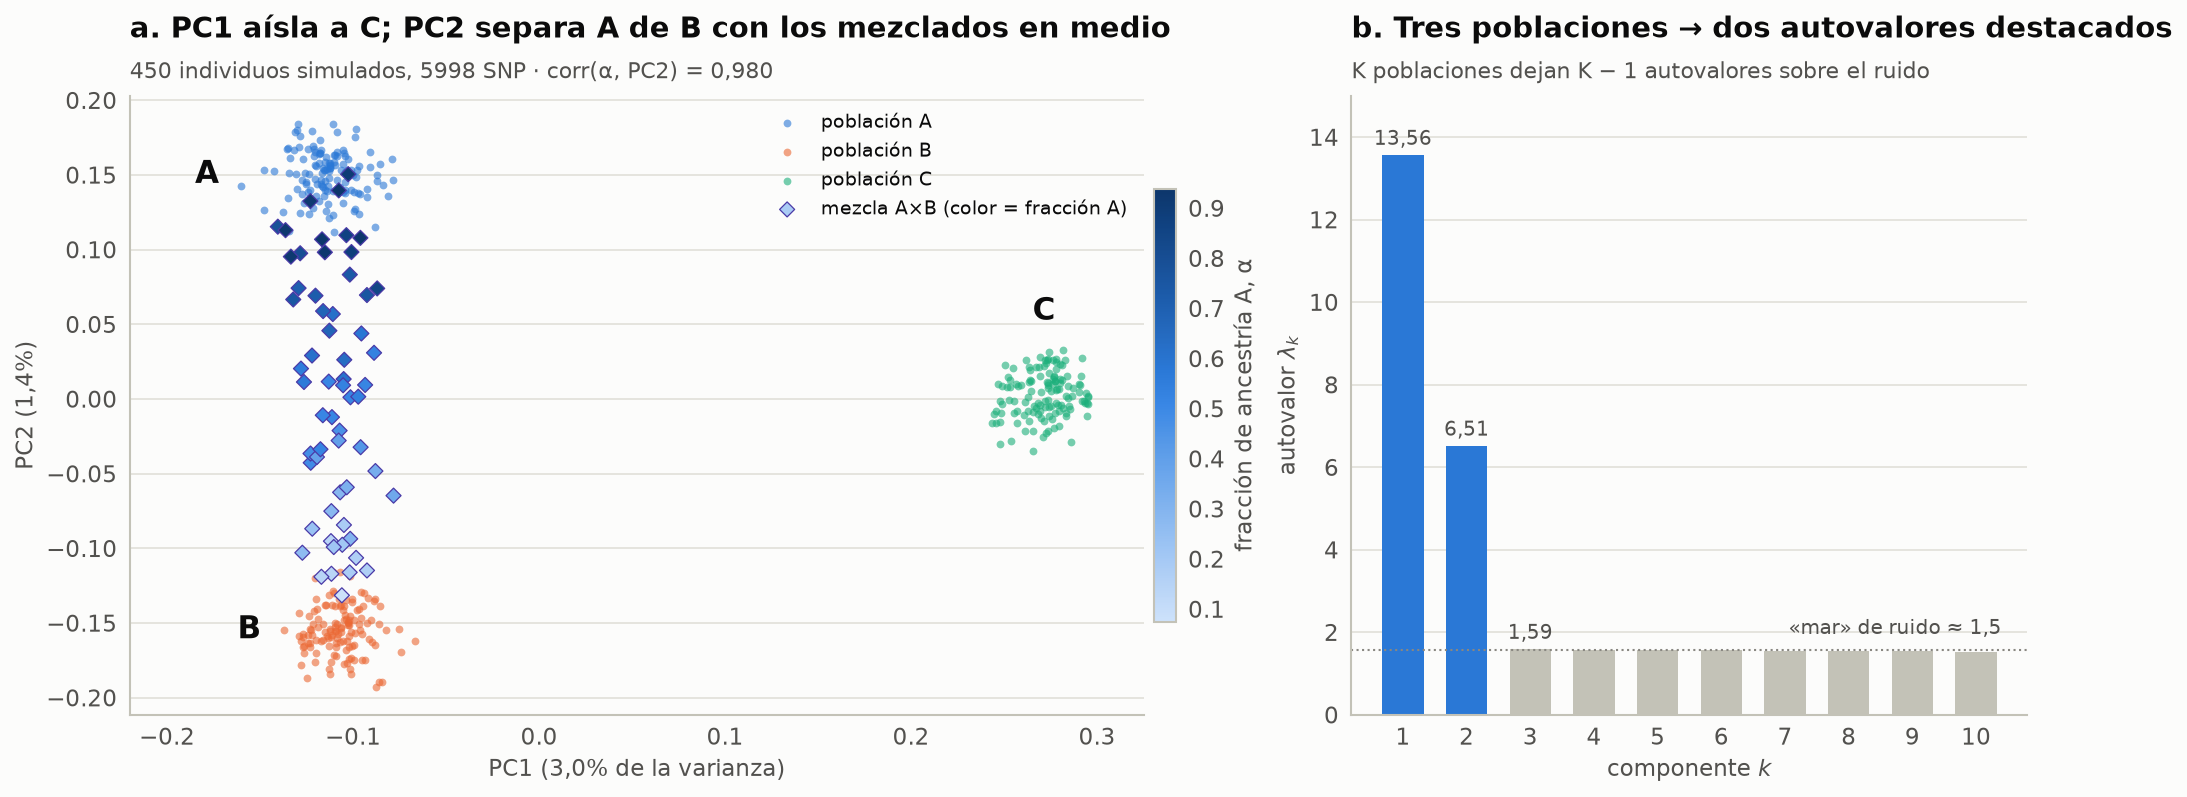

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 5.2), gridspec_kw=dict(width_ratios=[1.5, 1]))
for k, col, lab in (("A", ec.BLUE, "población A"), ("B", ec.ORANGE, "población B"), ("C", ec.AQUA, "población C")):
    s_ = grp == k
    ax1.scatter(pcs_b[s_, 0], pcs_b[s_, 1], s=14, color=col, alpha=0.6, lw=0, label=lab)
    if k == "C":
        ax1.text(pcs_b[s_, 0].mean(), pcs_b[s_, 1].max() + 0.02, k, fontsize=15, fontweight="bold", color=ec.INK,
                 ha="center")
    else:
        ax1.text(pcs_b[s_, 0].min() - 0.012, pcs_b[s_, 1].mean(), k, fontsize=15, fontweight="bold", color=ec.INK,
                 ha="right", va="center")
sm = ax1.scatter(pcs_b[grp == "M", 0], pcs_b[grp == "M", 1], c=a_mix, cmap=ec.CMAP_SEQ, marker="D", s=26,
                 edgecolor=ec.VIOLET, lw=0.6, label="mezcla A×B (color = fracción A)")
cb = plt.colorbar(sm, ax=ax1, shrink=0.7, pad=0.01); cb.set_label("fracción de ancestría A, α")
ax1.set_xlabel(f"PC1 ({ev_b[0] / ev_b.sum():.1%} de la varianza)".replace(".", ","))
ax1.set_ylabel(f"PC2 ({ev_b[1] / ev_b.sum():.1%})".replace(".", ","))
ax1.set_xlim(pcs_b[:, 0].min() - 0.06, pcs_b[:, 0].max() + 0.03)
ax1.legend(frameon=False, loc="upper right", fontsize=9)
fig.set_dpi(75)                                              # figura densa: resolución moderada
ec.title(ax1, "a. PC1 aísla a C; PC2 separa A de B con los mezclados en medio",
         f"450 individuos simulados, {M_used} SNP · corr(α, PC2) = {r_mix:.3f}".replace(".", ","))
ax2.bar(np.arange(1, 11), ev_b[:10], color=[ec.BLUE] * 2 + [ec.BASELINE] * 8, width=0.65)
for i in range(3):
    ax2.text(i + 1, ev_b[i] + 0.25, f"{ev_b[i]:.2f}".replace(".", ","), ha="center", fontsize=9.5, color=ec.INK_2)
ax2.axhline(ev_b[2:10].mean(), color=ec.MUTED, ls=":", lw=1)
ax2.text(10.4, ev_b[2:10].mean() + 0.4, "«mar» de ruido ≈ 1,5", ha="right", fontsize=9.5, color=ec.INK_2)
ax2.set_xticks(range(1, 11)); ax2.set_xlabel("componente $k$"); ax2.set_ylabel("autovalor $\\lambda_k$"); ax2.set_ylim(0, 15)
ec.title(ax2, "b. Tres poblaciones → dos autovalores destacados", "K poblaciones dejan K − 1 autovalores sobre el ruido")
plt.show()

> 🔎 **Qué observamos.** (a) PC1 separa a C, la población más diferenciada, y PC2 separa A de B; los individuos
> mezclados forman un **puente** entre A y B, y su posición en PC2 refleja casi exactamente su fracción real de
> ancestría (correlación 0,98). (b) Con tres poblaciones aparecen exactamente **dos** autovalores destacados; los demás
> forman el «mar» de ruido ($\lambda\approx1{,}5$) que describe la teoría de matrices aleatorias. Patterson et al.
> (2006) mostraron cómo decidir cuántos autovalores son significativos comparándolos con la distribución de
> **Tracy-Widom**.

### 6.5 ¿Cuánta diferenciación puede ver el PCA?

Patterson et al. (2006) descubrieron también un **fenómeno de umbral**: la estructura sólo es detectable si
$F_{ST}$ supera aproximadamente $1/\sqrt{nM}$. Por debajo, los autovalores de la estructura se confunden con el mar
de ruido; por encima, emergen bruscamente.

In [28]:
for n_, M_ in ((450, 6000), (1000, 100_000), (2504, 3292), (500_000, 500_000)):
    print(f"n = {n_:>7,}  M = {M_:>7,}:  umbral F_ST ≈ 1/√(nM) = {1 / math.sqrt(n_ * M_):.1e}".replace(",", " "))

n =     450  M =   6 000:  umbral F_ST ≈ 1/√(nM) = 6.1e-04
n =   1 000  M = 100 000:  umbral F_ST ≈ 1/√(nM) = 1.0e-04
n =   2 504  M =   3 292:  umbral F_ST ≈ 1/√(nM) = 3.5e-04
n = 500 000  M = 500 000:  umbral F_ST ≈ 1/√(nM) = 2.0e-06


Con 1 000 individuos y 100 000 SNP el umbral es $F_{ST}\approx10^{-4}$: el PCA puede separar poblaciones que ningún
otro indicador distinguiría, como regiones vecinas de un mismo país. El resultado más célebre es el de Novembre et
al. (2008), que aplicaron PCA a genotipos de más de mil europeos y encontraron que, al rotar ligeramente los dos
primeros componentes, **la nube de individuos reproducía el mapa de Europa**: los genes reflejan la geografía. La
interpretación es la del modelo de aislamiento por distancia: cuando las personas se aparean con sus vecinos, las
frecuencias alélicas varían suavemente en el espacio y los primeros componentes recuperan las coordenadas
geográficas.

> ⚠️ **Cuidado: el PCA también ve el LD.** El PCA supone implícitamente que los SNP son independientes. Una región
> larga de LD fuerte (como el complejo HLA en el cromosoma 6, o una inversión cromosómica polimórfica) aporta cientos
> de SNP casi idénticos y puede «secuestrar» un componente entero, que entonces refleja el genotipo de esa región y no
> la ancestría. Por eso, antes del PCA, se **poda** el conjunto de SNP para eliminar pares con $r^2$ alto (en PLINK,
> `--indep-pairwise`) y se excluyen las regiones de LD extenso conocidas. Nuestra matriz del cromosoma 22 ya viene
> «adelgazada» (SNP separados al menos 10 kb); en el ejercicio 6 verá qué pasa si se le añade la región de la lactasa
> sin podar.

## 7. Datos reales II: PCA del cromosoma 22 en 2 504 personas

### 7.1 La matriz de genotipos

La matriz `1000G_chr22_thinned_genotypes.npz` contiene los genotipos (0/1/2 copias del alelo alternativo) de las
2 504 personas en 3 292 SNP bialélicos del cromosoma 22 con frecuencia del alelo menor ≥ 5 %, **separados al menos
10 kb** entre sí: un adelgazamiento sencillo que reduce el LD entre SNP vecinos, como recomienda la advertencia de la
sección anterior. Es una fracción minúscula del genoma (un cromosoma, una de cada ~100 variantes comunes), así que la
pregunta es interesante: **¿basta tan poco para reconocer los continentes?**

In [29]:
POP_NAMES = {
    "YRI": "yoruba de Ibadán (Nigeria)", "LWK": "luhya de Webuye (Kenia)", "GWD": "gambianos (Gambia)",
    "MSL": "mende (Sierra Leona)", "ESN": "esan (Nigeria)", "ASW": "afroestadounidenses del suroeste de EE. UU.",
    "ACB": "afrocaribeños de Barbados", "MXL": "ascendencia mexicana en Los Ángeles", "PUR": "puertorriqueños",
    "CLM": "colombianos de Medellín", "PEL": "peruanos de Lima", "CHB": "chinos han de Pekín", "JPT": "japoneses de Tokio",
    "CHS": "chinos han del sur", "CDX": "chinos dai de Xishuangbanna", "KHV": "kinh de Ciudad Ho Chi Minh (Vietnam)",
    "CEU": "residentes de Utah con ancestría del norte y oeste de Europa", "TSI": "toscanos (Italia)",
    "FIN": "finlandeses", "GBR": "británicos (Inglaterra y Escocia)", "IBS": "población ibérica (España)",
    "GIH": "guyaratíes en Houston", "PJL": "panyabíes de Lahore (Pakistán)", "BEB": "bengalíes (Bangladés)",
    "STU": "tamiles de Sri Lanka en el Reino Unido", "ITU": "telugus de la India en el Reino Unido"}

npz = np.load(course_file("1000G_chr22_thinned_genotypes.npz"))
G22 = npz["genotypes"].astype(float); pos22 = npz["pos"]; samples22 = npz["samples"]
info22 = panel.reindex(samples22)
pop22, sup22 = info22["pop"].values, info22["super_pop"].values
print(npz["description"])
print(f"G: {G22.shape[0]} personas × {G22.shape[1]} SNP · posiciones {pos22.min():,} – {pos22.max():,} · "
      f"distancia mínima entre SNP: {np.diff(np.sort(pos22)).min():,} pb")
print(pd.Series(sup22).value_counts().to_dict())

1000 Genomes phase 3 (GRCh37), chr22, SNPs bialélicos MAF>=0.05 espaciados >=10 kb; genotipos 0/1/2 = copias del alelo ALT; filas = muestras
G: 2504 personas × 3292 SNP · posiciones 16,051,249 – 51,233,666 · distancia mínima entre SNP: 10,000 pb
{'AFR': 661, 'EAS': 504, 'EUR': 503, 'SAS': 489, 'AMR': 347}


Ahora el PCA **desde cero**, paso a paso según la ecuación 10-zpca: frecuencias, estandarización, SVD y coordenadas.

In [30]:
t0 = time.time()
p22 = G22.mean(0) / 2                                        # \hat p_j
Z22 = (G22 - 2 * p22) / np.sqrt(2 * p22 * (1 - p22))         # Z_ij
U22, S22, Vt22 = np.linalg.svd(Z22, full_matrices=False)     # Z = U S Vᵀ
lam22 = S22 ** 2 / Z22.shape[1]                              # λ_k (autovalores de Ψ = ZZᵀ/M)
PC = U22[:, :10] * np.sqrt(lam22[:10])                       # coordenadas √λ_k · u_ik
# el signo de cada eje es arbitrario: lo fijamos para que AFR quede a la izquierda en PC1, EAS arriba en PC2,
# AMR arriba en PC3 y SAS abajo en PC4
for k, (ref_sup, want) in enumerate((("AFR", -1), ("EAS", 1), ("AMR", 1), ("SAS", -1))):
    if np.sign(PC[sup22 == ref_sup, k].mean()) != want:
        PC[:, k] *= -1; Vt22[k] *= -1
print(f"SVD de una matriz {Z22.shape[0]}×{Z22.shape[1]} en {time.time() - t0:.1f} s")
print("λ_1..10 =", ", ".join(f"{l:.1f}" for l in lam22[:10]))
print("varianza explicada:", ", ".join(f"PC{k + 1} {lam22[k] / lam22.sum():.1%}" for k in range(5)))
print("\nCentro de cada superpoblación en los 4 primeros PC:")
pd.DataFrame(PC[:, :4], columns=["PC1", "PC2", "PC3", "PC4"]).groupby(sup22).mean().round(3)

SVD de una matriz 2504×3292 en 3.7 s
λ_1..10 = 283.9, 113.6, 42.2, 37.4, 15.7, 14.9, 13.8, 13.3, 12.5, 11.7
varianza explicada: PC1 10.3%, PC2 4.1%, PC3 1.5%, PC4 1.4%, PC5 0.6%

Centro de cada superpoblación en los 4 primeros PC:


,PC1,PC2,PC3,PC4
AFR,-0.543,0.047,0.006,0.002
AMR,0.155,-0.120,0.218,0.014
EAS,0.284,0.353,-0.025,0.059
EUR,0.154,-0.256,-0.039,0.121
SAS,0.173,-0.079,-0.097,-0.198


> 🤔 **Antes de ejecutar, prediga.** Hay cinco superpoblaciones. Según la sección 6.4, ¿cuántos autovalores deberían
> destacar? ¿Qué continente cree que separará PC1?

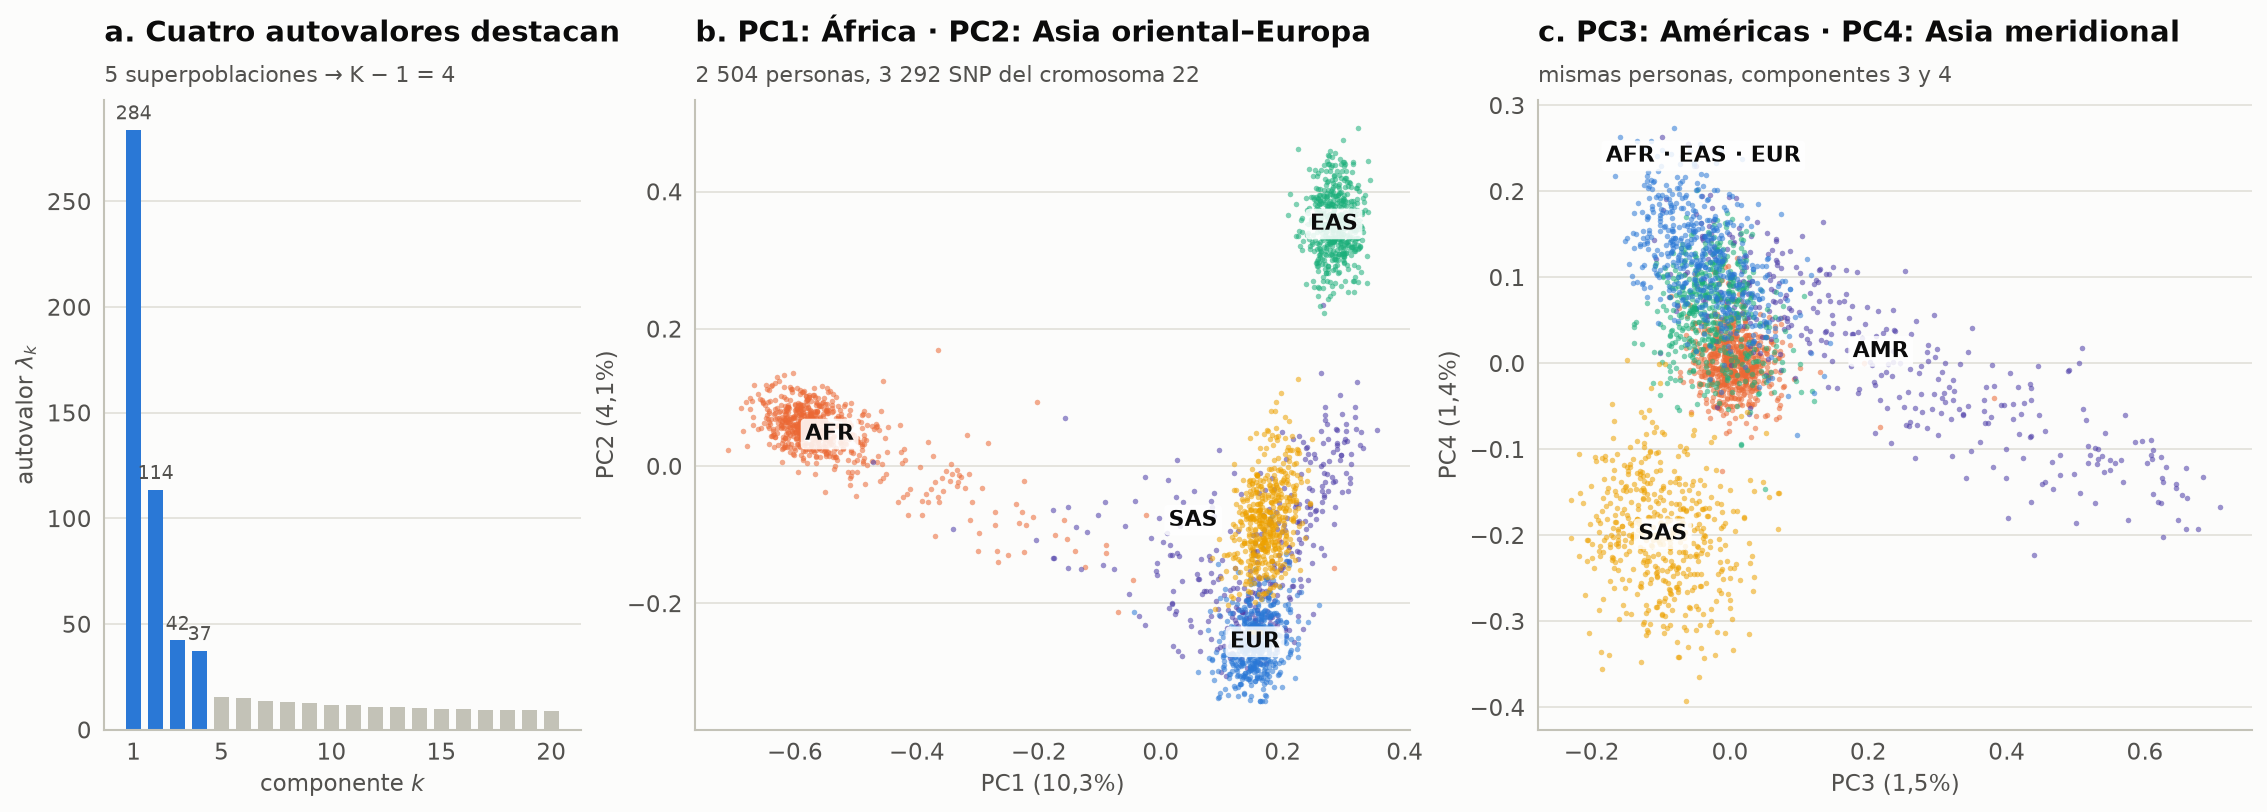

In [31]:
fig = plt.figure(figsize=(15, 5.3))
gs = fig.add_gridspec(1, 3, width_ratios=[0.8, 1.2, 1.2])
axs = fig.add_subplot(gs[0]); axa = fig.add_subplot(gs[1]); axb = fig.add_subplot(gs[2])
axs.bar(np.arange(1, 21), lam22[:20], color=[ec.BLUE] * 4 + [ec.BASELINE] * 16, width=0.7)
for i in range(4):
    axs.text(i + 1, lam22[i] + 5, f"{lam22[i]:.0f}", ha="center", fontsize=9, color=ec.INK_2)
axs.set_xlabel("componente $k$"); axs.set_ylabel("autovalor $\\lambda_k$"); axs.set_xticks([1, 5, 10, 15, 20])
ec.title(axs, "a. Cuatro autovalores destacan", "5 superpoblaciones → K − 1 = 4")
LABELS = {axa: {"AFR": "AFR", "EAS": "EAS", "EUR": "EUR", "SAS": "SAS"},       # AMR queda entre los polos
          axb: {"AMR": "AMR", "SAS": "SAS", "EUR": "AFR · EAS · EUR"}}
for ax, (i, j) in ((axa, (0, 1)), (axb, (2, 3))):
    for sup, col in SUPER_COLORS.items():
        s_ = sup22 == sup
        ax.scatter(PC[s_, i], PC[s_, j], s=7, color=col, alpha=0.55, lw=0)
    for sup, lab in LABELS[ax].items():
        s_ = sup22 == sup
        dx = {"SAS": -0.12, "EUR": 0.0}.get(sup, 0.0) if ax is axa else 0.0
        ax.text(PC[s_, i].mean() + dx, PC[s_, j].mean() + (0.12 if (ax is axb and sup == "EUR") else 0), lab,
                fontsize=10.5, fontweight="bold", color=ec.INK, ha="center", va="center",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=SUPER_COLORS[sup], alpha=0.85))
    ax.set_xlabel(f"PC{i + 1} ({lam22[i] / lam22.sum():.1%})".replace(".", ","))
    ax.set_ylabel(f"PC{j + 1} ({lam22[j] / lam22.sum():.1%})".replace(".", ","))
ec.title(axa, "b. PC1: África · PC2: Asia oriental–Europa", "2 504 personas, 3 292 SNP del cromosoma 22")
fig.set_dpi(75)                                              # figura densa: resolución moderada
ec.title(axb, "c. PC3: Américas · PC4: Asia meridional", "mismas personas, componentes 3 y 4")
plt.show()

> 🔎 **Qué observamos.** (a) Cuatro autovalores sobresalen y después empieza el mar de ruido: las **cinco**
> superpoblaciones dejan $K-1=4$ ejes, como en la simulación del libro. (b) PC1, el eje de mayor variación, separa a
> las poblaciones africanas del resto: es la huella del cuello de botella de la salida de África, la división más
> profunda de la genealogía humana. PC2 separa Asia oriental de Europa, con Asia meridional en medio. (c) PC3 separa
> un componente propio de las Américas (la ancestría **nativa americana**, más alta en los peruanos de Lima) y PC4
> distingue Asia meridional. Las poblaciones de las Américas se **estiran** entre los polos: son mezclas recientes.
> Todo esto sale de 3 292 SNP de un solo cromosoma y **sin usar ninguna etiqueta**.

### 🎛️ PCA interactivo de 2 504 personas

Cada punto es una persona, coloreada por su población (tonos de su superpoblación). Pase el ratón para ver quién
es; haga clic en la leyenda para ocultar o aislar poblaciones (doble clic aísla una), y use el menú para cambiar de
componentes.

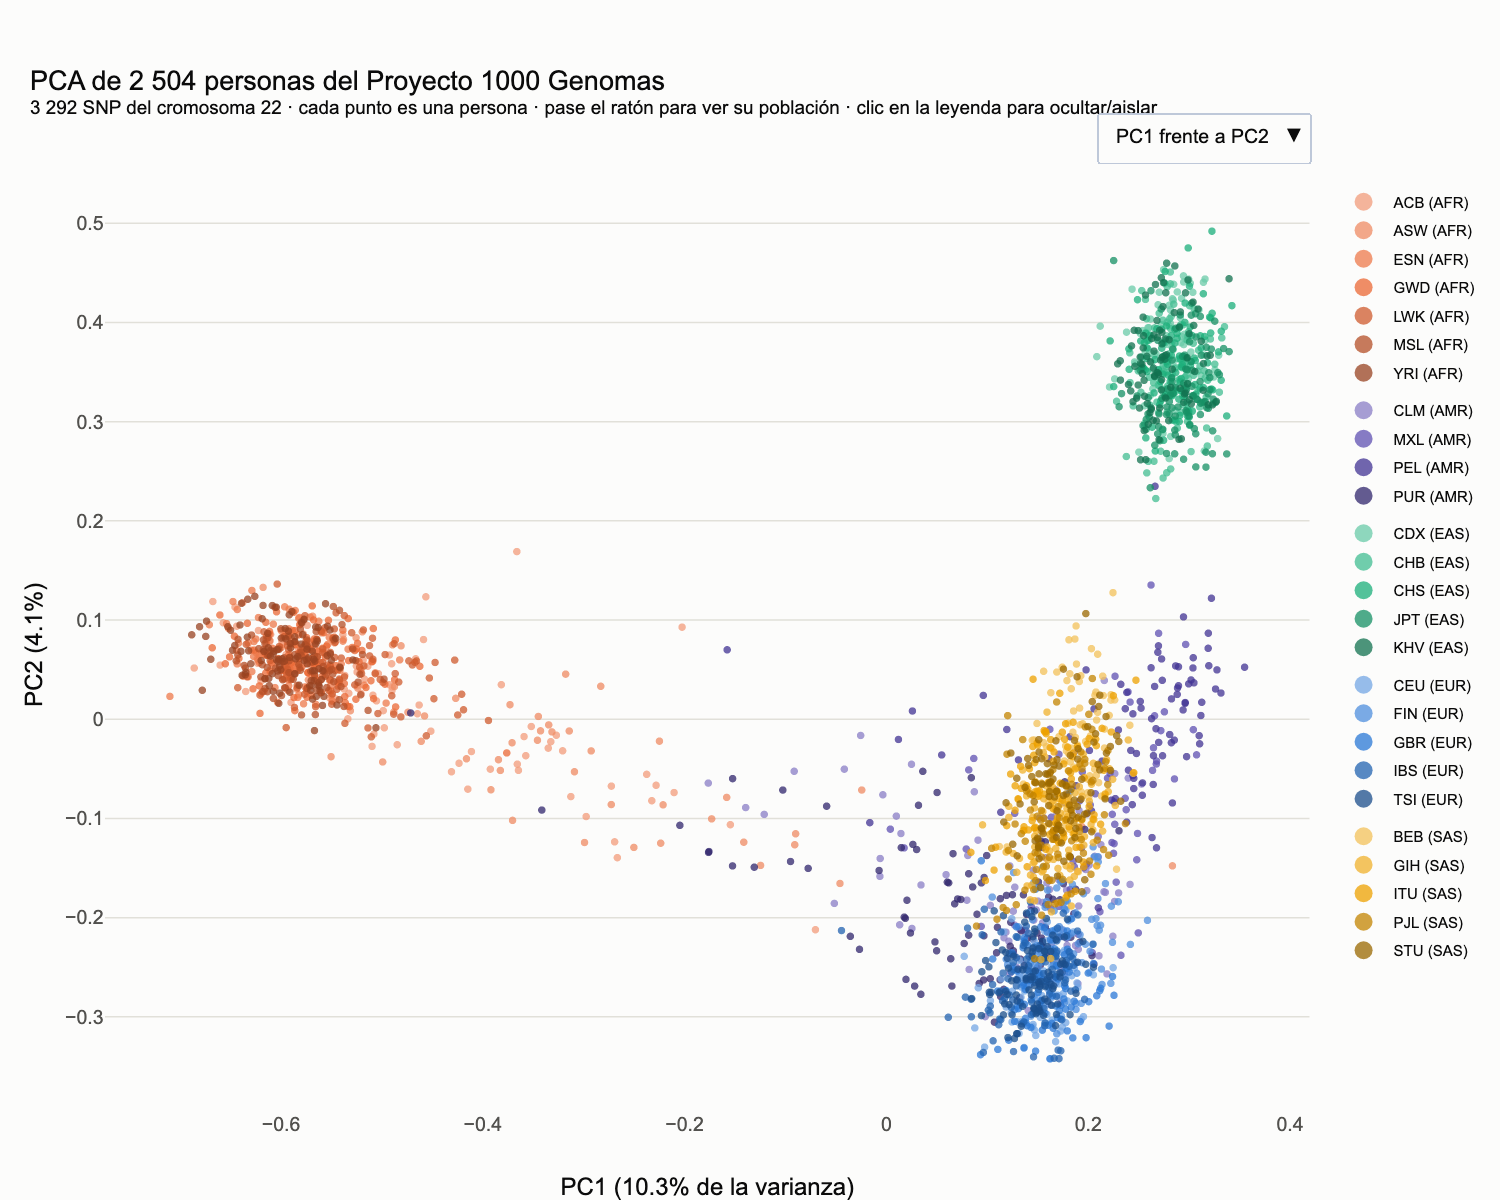

In [32]:
def shades(base, n):
    """n tonos de un color base, de más claro a más oscuro."""
    r, g, b = to_rgb(base)
    out = []
    for f in np.linspace(-0.35, 0.35, n):
        c = [x + (1 - x) * (-f) for x in (r, g, b)] if f < 0 else [x * (1 - f) for x in (r, g, b)]
        out.append("#%02x%02x%02x" % tuple(int(255 * v) for v in c))
    return out

POP_ORDER = [p for s in SUPER_COLORS for p in sorted(set(pop22[sup22 == s]))]
POP_COLORS = {}
for s, col in SUPER_COLORS.items():
    ps_ = [p for p in POP_ORDER if p in set(pop22[sup22 == s])]
    POP_COLORS.update(dict(zip(ps_, shades(col, len(ps_)))))

pairs = [(0, 1), (0, 2), (2, 3)]
fig = go.Figure()
for p_ in POP_ORDER:
    s_ = pop22 == p_
    sup = sup22[s_][0]
    cd = np.column_stack([samples22[s_], np.repeat(p_, s_.sum()), np.repeat(POP_NAMES[p_], s_.sum()),
                          np.repeat(f"{sup} · {SUPER_NAMES[sup]}", s_.sum()), info22["gender"].values[s_]])
    fig.add_trace(go.Scattergl(
        x=PC[s_, 0], y=PC[s_, 1], mode="markers", name=f"{p_} ({sup})", legendgroup=sup, customdata=cd,
        marker=dict(size=5, color=POP_COLORS[p_], opacity=0.75),
        hovertemplate=("<b>%{customdata[0]}</b> (%{customdata[4]})<br>%{customdata[1]}: %{customdata[2]}<br>"
                       "%{customdata[3]}<br>x = %{x:.3f} · y = %{y:.3f}<extra></extra>")))
buttons = []
for i, j in pairs:
    xs = [PC[pop22 == p_, i] for p_ in POP_ORDER]; ys = [PC[pop22 == p_, j] for p_ in POP_ORDER]
    buttons.append(dict(label=f"PC{i + 1} frente a PC{j + 1}", method="update",
                        args=[{"x": xs, "y": ys},
                              {"xaxis.title.text": f"PC{i + 1} ({lam22[i] / lam22.sum():.1%} de la varianza)",
                               "yaxis.title.text": f"PC{j + 1} ({lam22[j] / lam22.sum():.1%})"}]))
fig.update_layout(
    title="PCA de 2 504 personas del Proyecto 1000 Genomas<br><sup>3 292 SNP del cromosoma 22 · cada punto es una "
          "persona · pase el ratón para ver su población · clic en la leyenda para ocultar/aislar</sup>",
    updatemenus=[dict(buttons=buttons, direction="down", x=1.0, xanchor="right", y=1.02, yanchor="bottom")],
    xaxis_title=f"PC1 ({lam22[0] / lam22.sum():.1%} de la varianza)", yaxis_title=f"PC2 ({lam22[1] / lam22.sum():.1%})",
    height=800, margin=dict(t=120, l=70, r=20, b=60),
    legend=dict(font=dict(size=10), itemsizing="constant", tracegroupgap=6))
fig.show()

> 🔎 **Qué observamos.** Dentro de cada continente, las poblaciones se solapan casi por completo en PC1–PC2: con
> 3 292 SNP, la diferenciación **dentro** de un continente ($F_{ST}\lesssim0{,}01$) está cerca del umbral
> $1/\sqrt{nM}$. Las excepciones informan: ASW y ACB se reparten a lo largo de la línea entre África y Europa, y las
> poblaciones AMR entre Europa y el polo americano, cada persona en una posición distinta según su proporción de
> ancestría. Cambie a PC3 frente a PC4 para ver separarse a Asia meridional.

### 7.2 Las cargas: ¿qué SNP definen cada componente?

Las filas de $V^\top$ (las **cargas**, *loadings*) dicen cuánto contribuye cada SNP a cada componente. Si un
componente reflejara ancestría genómica, sus cargas deberían repartirse por todo el cromosoma; si reflejara una sola
región de LD largo, se concentrarían en ella.

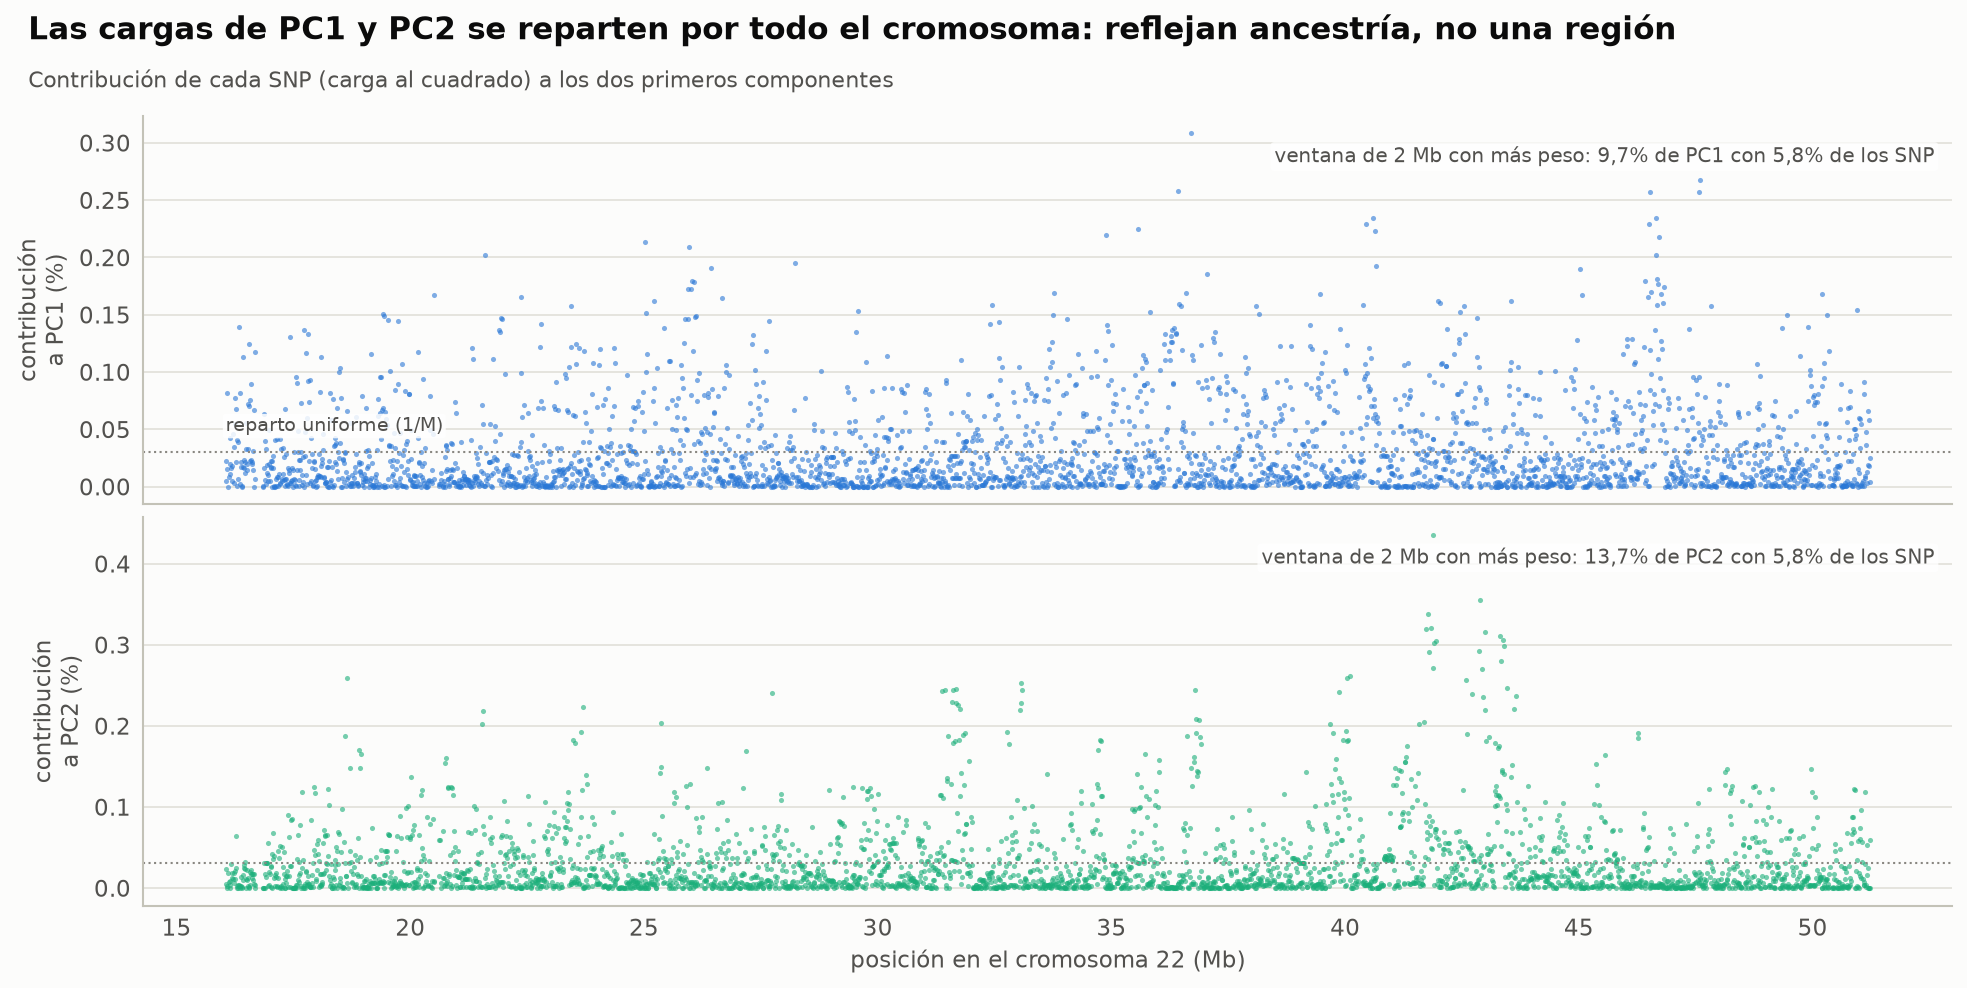

In [33]:
fig, axes = plt.subplots(2, 1, figsize=(13, 5.8), sharex=True)
for k, ax in enumerate(axes):
    contrib = Vt22[k] ** 2                                    # fracción del eje que aporta cada SNP (suman 1)
    ax.scatter(pos22 / 1e6, contrib * 100, s=6, color=[ec.BLUE, ec.AQUA][k], alpha=0.6, lw=0)
    ax.axhline(100 / len(pos22), color=ec.MUTED, ls=":", lw=1)
    ax.set_ylabel(f"contribución\na PC{k + 1} (%)")
    shares = [(contrib[(pos22 >= s0) & (pos22 < s0 + 2e6)].sum(), ((pos22 >= s0) & (pos22 < s0 + 2e6)).mean())
              for s0 in range(16_000_000, 50_000_000, 500_000)]
    best = max(shares)
    ax.text(0.99, 0.88, f"ventana de 2 Mb con más peso: {best[0]:.1%} de PC{k + 1} con {best[1]:.1%} de los SNP"
            .replace(".", ","), transform=ax.transAxes, ha="right", fontsize=9.5, color=ec.INK_2,
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8))
axes[1].set_xlabel("posición en el cromosoma 22 (Mb)")
axes[0].text(pos22.min() / 1e6, 100 / len(pos22) * 1.6, "reparto uniforme (1/M)", fontsize=9, color=ec.INK_2,
             bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.85))
fig.set_dpi(75)                                              # figura densa: resolución moderada
ec.fig_title(fig, "Las cargas de PC1 y PC2 se reparten por todo el cromosoma: reflejan ancestría, no una región",
             "Contribución de cada SNP (carga al cuadrado) a los dos primeros componentes")
plt.show()

> 🔎 **Qué observamos.** Ningún tramo acapara un eje: la ventana de 2 Mb con más peso aporta a PC1 o PC2 a lo sumo
> un 10–15 %, dos o tres veces su proporción de SNP (se ven pequeños racimos de SNP vecinos que aún comparten LD o
> una historia de diferenciación, pero el 85–90 % del eje viene del resto del cromosoma). Los SNP que más pesan en PC1 son los de mayor diferencia de frecuencia entre
> África y el resto, repartidos por todo el cromosoma. Es lo que esperamos de un eje de ancestría. En el ejercicio 6
> verá el caso contrario.

### 7.3 El mestizaje americano, individuo por individuo

Las poblaciones AMR (MXL, PUR, CLM, PEL) y las afrodescendientes (ASW, ACB) se formaron en los últimos cinco siglos
por la mezcla de ancestrías africana, europea y nativa americana. En el espacio de los PC, un individuo mezclado cae
aproximadamente en la **combinación convexa** de los centros de sus poblaciones de origen, ponderada por sus
proporciones de ancestría (lo vimos en la simulación: corr(α, PC2) = 0,98). Podemos invertir la idea y **estimar**
proporciones con una regresión no negativa sobre tres vértices: yoruba (YRI) para África, ibéricos (IBS) para
Europa y, a falta de una población nativa americana sin mezcla en el 1000 Genomas, el promedio del 5 % de individuos
PEL más extremos en PC3 como aproximación del polo nativo americano.

Es una versión muy simplificada de lo que hacen programas como ADMIXTURE o los informes de ancestría de las pruebas
genéticas de consumo; los vértices elegidos condicionan el resultado, así que tómelo como ilustración, no como
estimación publicable.

     africana (YRI)  europea (IBS)  nativa americana (polo PEL)
ACB            0.84           0.14                         0.02
ASW            0.71           0.24                         0.05
PUR            0.12           0.75                         0.13
CLM            0.08           0.68                         0.24
MXL            0.04           0.51                         0.45
PEL            0.04           0.24                         0.72


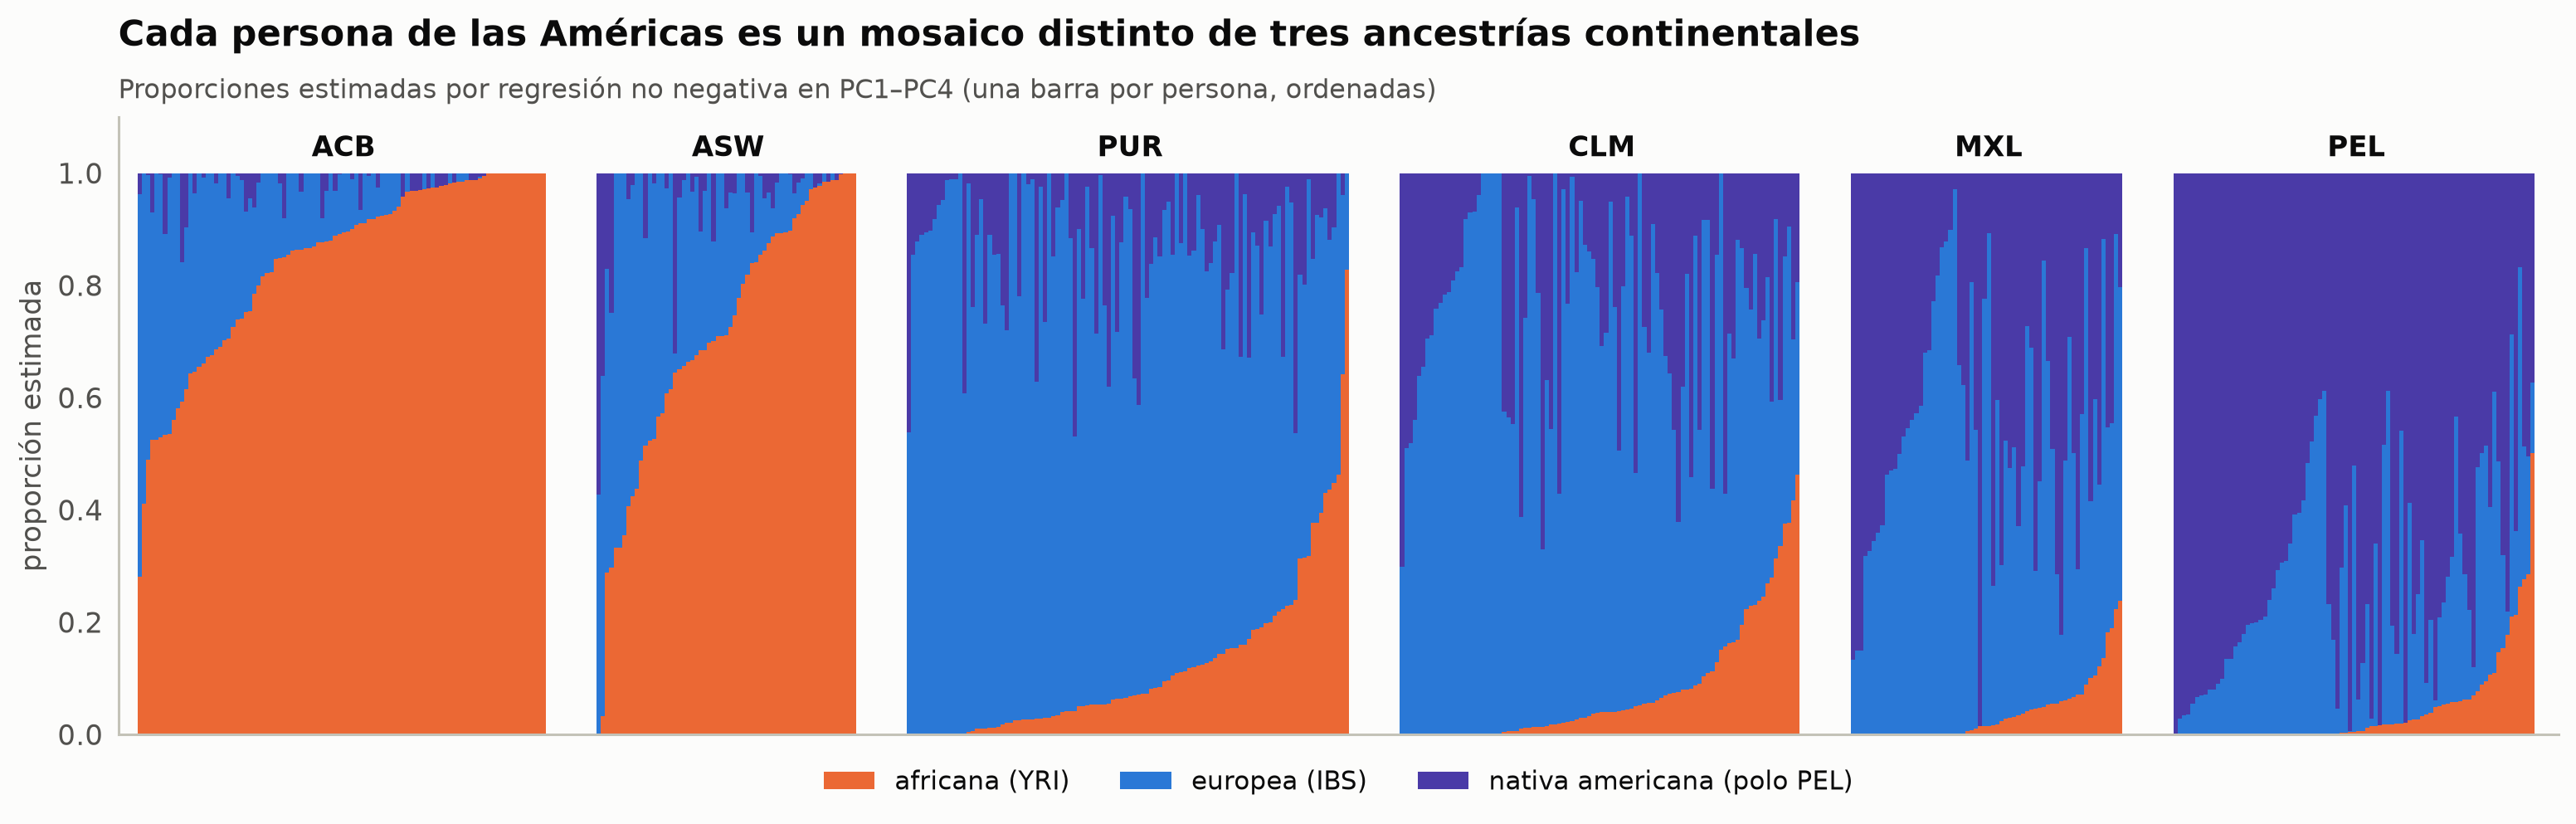

In [34]:
from scipy.optimize import nnls
def centroid(p_):
    return PC[pop22 == p_, :4].mean(0)
pel = PC[pop22 == "PEL", :4]
nat = pel[np.argsort(pel[:, 2])[-int(0.05 * len(pel)):]].mean(0)
VERT = np.vstack([centroid("YRI"), centroid("IBS"), nat])      # 3 vértices × 4 PC
ANC_NAMES = ["africana (YRI)", "europea (IBS)", "nativa americana (polo PEL)"]
ANC_COLORS = [SUPER_COLORS["AFR"], SUPER_COLORS["EUR"], SUPER_COLORS["AMR"]]
def ancestry(x, w_sum=10.0):
    """Proporciones no negativas que suman ~1 (la suma se impone con una fila de peso alto)."""
    A = np.vstack([VERT.T, np.full(3, w_sum)]); b = np.r_[x, w_sum]
    w, _ = nnls(A, b)
    return w / w.sum()

ADM_POPS = ["ACB", "ASW", "PUR", "CLM", "MXL", "PEL"]
adm = {p_: np.array([ancestry(x) for x in PC[pop22 == p_, :4]]) for p_ in ADM_POPS}
print(pd.DataFrame({p_: adm[p_].mean(0) for p_ in ADM_POPS}, index=ANC_NAMES).T.round(2))

fig, ax = plt.subplots(figsize=(14, 4.4))
x0 = 0
for p_ in ADM_POPS:
    a_ = adm[p_][np.lexsort((adm[p_][:, 1], adm[p_][:, 0]))]    # ordenar por ancestría africana y europea
    xs = x0 + np.arange(len(a_))
    bottom = np.zeros(len(a_))
    for k in range(3):
        ax.bar(xs, a_[:, k], bottom=bottom, width=1.0, color=ANC_COLORS[k], lw=0)
        bottom += a_[:, k]
    ax.text(x0 + len(a_) / 2, 1.03, p_, ha="center", fontsize=11, fontweight="bold", color=ec.INK)
    x0 += len(a_) + 12
ax.set_xlim(-5, x0 - 7); ax.set_ylim(0, 1.1); ax.set_xticks([]); ax.set_ylabel("proporción estimada")
ax.grid(False)
ax.legend(handles=[Rectangle((0, 0), 1, 1, color=c) for c in ANC_COLORS], labels=ANC_NAMES, frameon=False,
          ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.02))
ec.title(ax, "Cada persona de las Américas es un mosaico distinto de tres ancestrías continentales",
         "Proporciones estimadas por regresión no negativa en PC1–PC4 (una barra por persona, ordenadas)")
plt.show()

> 🔎 **Qué observamos.** Las poblaciones afrodescendientes (ACB, ASW) tienen sobre todo ancestría africana con una
> parte europea que varía mucho de persona a persona; los puertorriqueños (PUR) y colombianos (CLM), mayoría europea
> con aportes nativo americano y africano; los mexicanos de Los Ángeles (MXL), una mezcla más equilibrada entre
> europea y nativa; y los peruanos (PEL), mayoría nativa americana (en parte por construcción, porque el polo nativo
> sale de ellos mismos). Lo esencial no son las cifras exactas, sino la **variación entre individuos** de la misma
> población: la etiqueta «población» no describe la ancestría de una persona. Esto es crucial en un GWAS (Lección
> 10.3): si la ancestría varía dentro de la muestra y se correlaciona con el rasgo, aparecen asociaciones espurias.

### 7.4 $F_{ST}$ entre las 26 poblaciones

Por último, $F_{ST}$ de Weir-Cockerham entre cada par de poblaciones (325 pares), ordenadas por un árbol de
agrupamiento jerárquico (UPGMA) construido con las mismas distancias.

In [35]:
POPS = sorted(set(pop22))
Gp = {p_: G22[pop22 == p_].astype(int) for p_ in POPS}
F = np.zeros((len(POPS), len(POPS)))
for i in range(len(POPS)):
    for j in range(i + 1, len(POPS)):
        F[i, j] = F[j, i] = wc_fst(Gp[POPS[i]], Gp[POPS[j]])
Fdf = pd.DataFrame(F, index=POPS, columns=POPS)
Z_link = linkage(squareform(np.clip(F, 0, None), checks=False), method="average")
ordered = [POPS[i] for i in leaves_list(Z_link)]
for a_, b_ in (("CEU", "YRI"), ("CEU", "CHB"), ("YRI", "CHB"), ("CEU", "GBR"), ("CEU", "TSI"), ("CEU", "FIN"),
               ("CHB", "JPT"), ("YRI", "LWK"), ("MXL", "CEU"), ("PEL", "CHB")):
    print(f"F_ST {a_}–{b_}: {Fdf.loc[a_, b_]:.4f}")
sup_of = dict(zip(pop22, sup22))
pairs_all = [(i, j) for i in range(26) for j in range(i + 1, 26)]
within = [F[i, j] for i, j in pairs_all if sup_of[POPS[i]] == sup_of[POPS[j]] != "AMR"]
between = [F[i, j] for i, j in pairs_all if sup_of[POPS[i]] != sup_of[POPS[j]]
           and "AMR" not in (sup_of[POPS[i]], sup_of[POPS[j]])]
print(f"\nmediana dentro de un continente (sin AMR): {np.median(within):.4f} · entre continentes: {np.median(between):.3f}")

F_ST CEU–YRI: 0.1571
F_ST CEU–CHB: 0.1139
F_ST YRI–CHB: 0.1999
F_ST CEU–GBR: -0.0001
F_ST CEU–TSI: 0.0028
F_ST CEU–FIN: 0.0073
F_ST CHB–JPT: 0.0099
F_ST YRI–LWK: 0.0097
F_ST MXL–CEU: 0.0459
F_ST PEL–CHB: 0.1142

mediana dentro de un continente (sin AMR): 0.0056 · entre continentes: 0.121


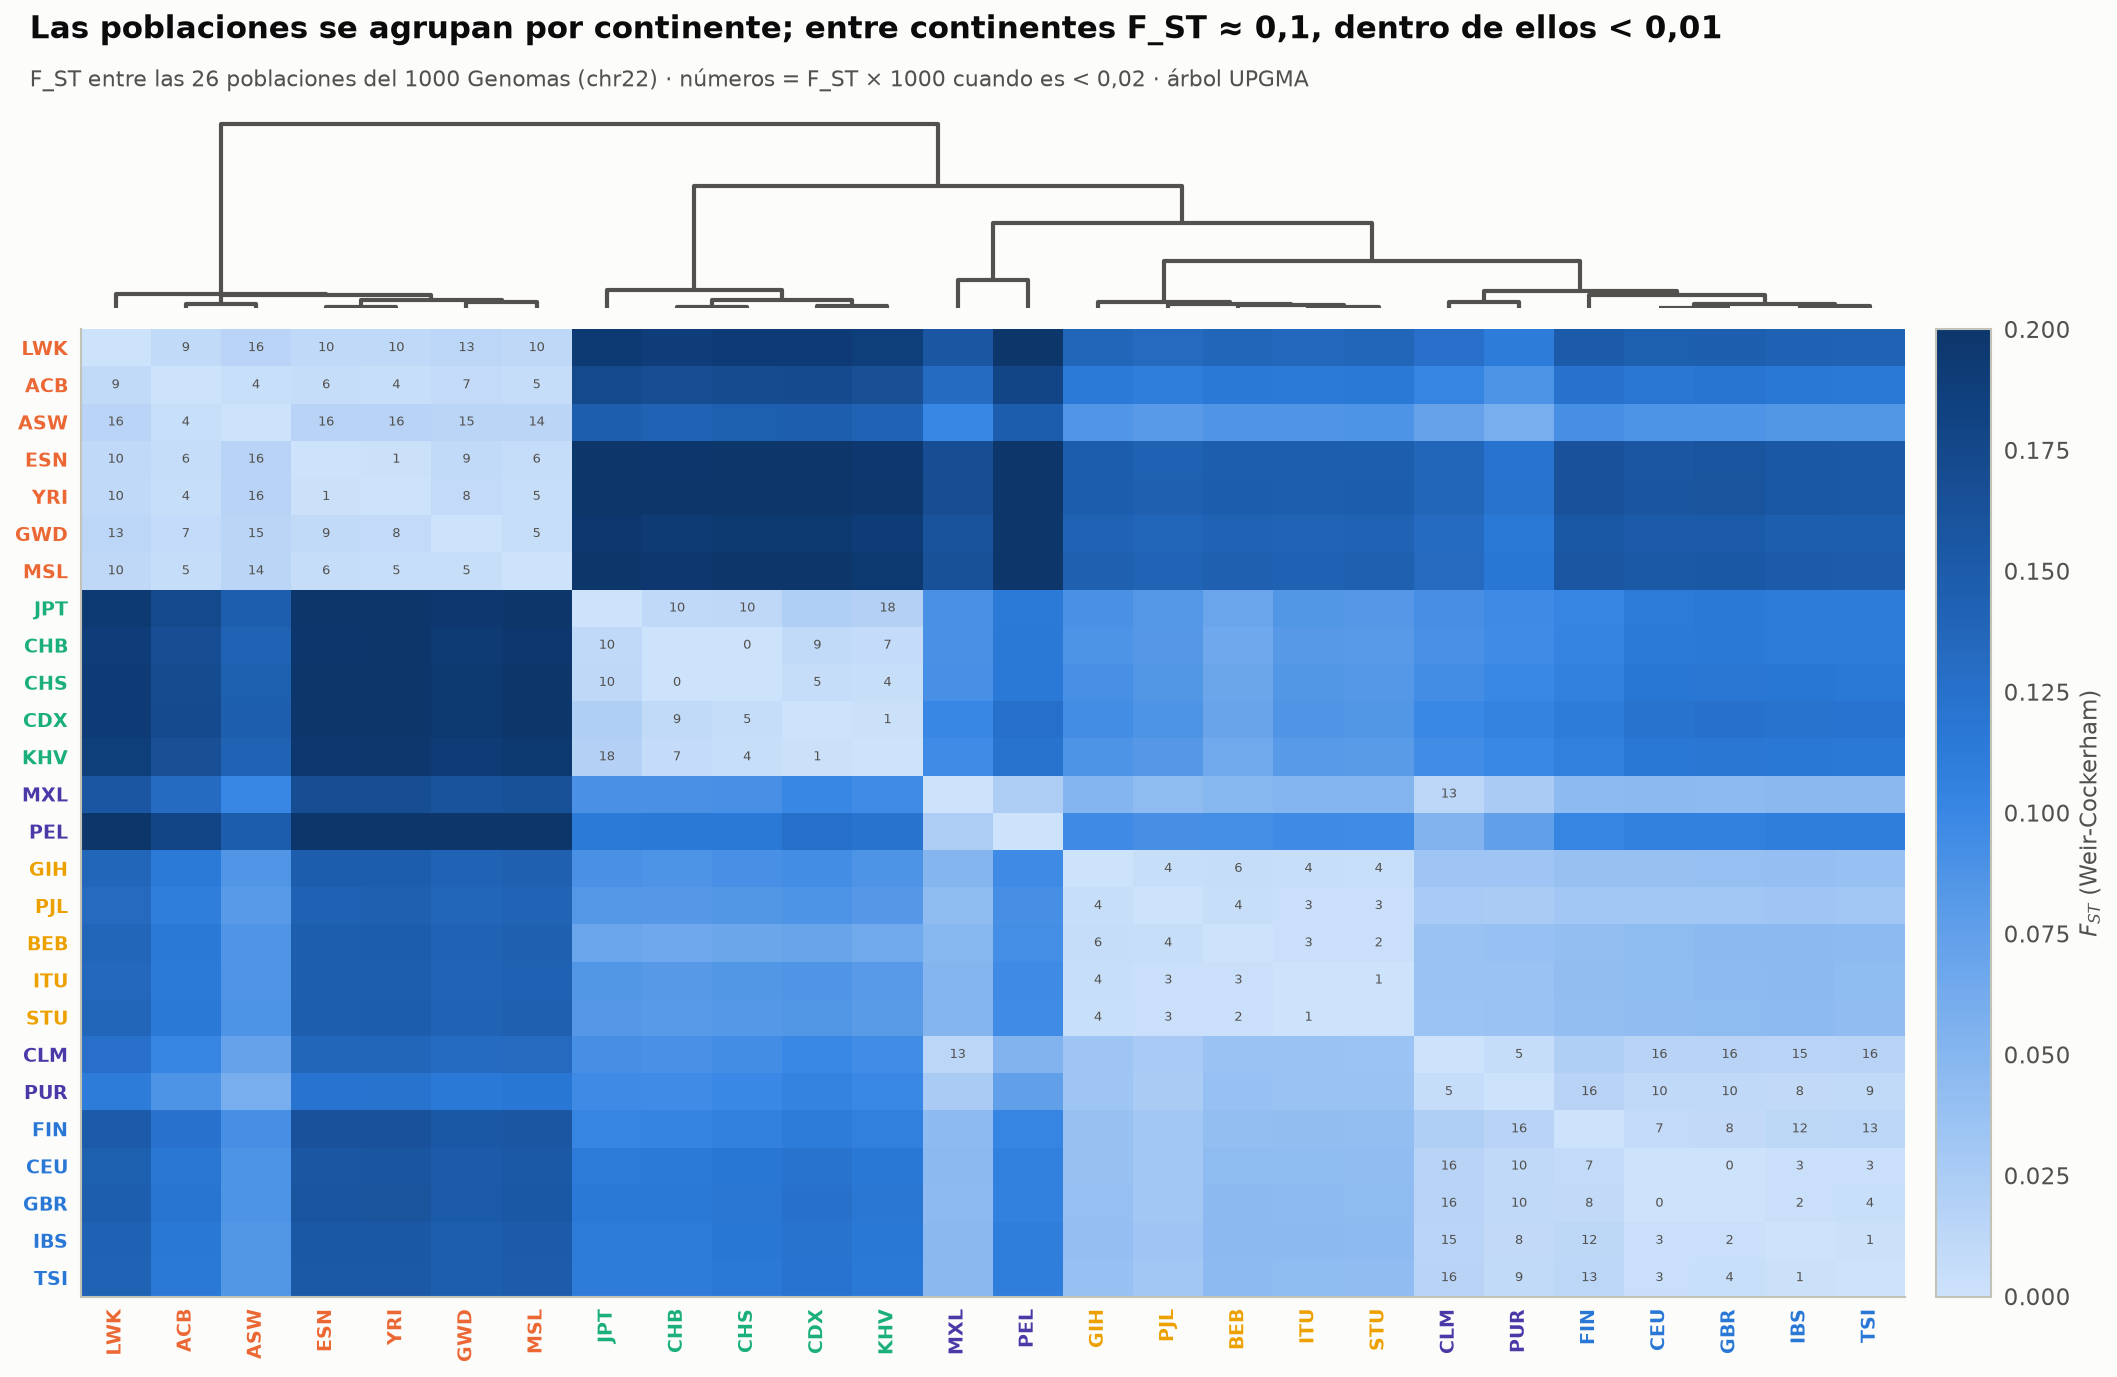

In [36]:
fig = plt.figure(figsize=(14, 8.4))
gs = fig.add_gridspec(2, 2, width_ratios=[1, 0.03], height_ratios=[0.2, 1], hspace=0.02, wspace=0.03)
axd = fig.add_subplot(gs[0, 0]); axh = fig.add_subplot(gs[1, 0]); axc = fig.add_subplot(gs[1, 1])
dendrogram(Z_link, ax=axd, no_labels=True, color_threshold=0, above_threshold_color=ec.INK_2)
axd.axis("off")
Fo = Fdf.loc[ordered, ordered].values
im = axh.imshow(np.clip(Fo, 0, None), cmap=ec.CMAP_SEQ, vmin=0, vmax=0.2, aspect="auto")
axh.set_xticks(range(26), ordered, rotation=90, fontsize=9); axh.set_yticks(range(26), ordered, fontsize=9)
for t_ in axh.get_xticklabels() + axh.get_yticklabels():
    t_.set_color(SUPER_COLORS[sup_of[t_.get_text()]]); t_.set_fontweight("bold")
for i in range(26):
    for j in range(26):
        if i != j and Fo[i, j] < 0.02:
            axh.text(j, i, f"{max(Fo[i, j], 0) * 1000:.0f}", ha="center", va="center", fontsize=6, color=ec.INK_2)
axh.grid(False)
cb = fig.colorbar(im, cax=axc); cb.set_label("$F_{ST}$ (Weir-Cockerham)")
fig.set_dpi(75)                                              # figura densa: resolución moderada
ec.fig_title(fig, "Las poblaciones se agrupan por continente; entre continentes F_ST ≈ 0,1, dentro de ellos < 0,01",
             "F_ST entre las 26 poblaciones del 1000 Genomas (chr22) · números = F_ST × 1000 cuando es < 0,02 · árbol UPGMA")
plt.show()

> 🔎 **Qué observamos.** El árbol recupera los continentes sin que se los digamos, con las poblaciones americanas y
> afrodescendientes en posiciones intermedias según su mezcla. Los valores concuerdan con las cifras del libro:
> $F_{ST}$ del orden de 0,1 entre continentes (0,16 entre CEU y YRI) y ≤ 0,01 dentro de ellos (británicos frente a
> residentes de Utah de ancestría noreuropea: prácticamente 0). Recuerde que $F_{ST}\approx0{,}1$ significa que
> **alrededor del 90 % de la variación genética está dentro de las poblaciones**, no entre ellas.

### 🎬 El PCA a medida que se añaden SNP

¿Cuántos SNP hacen falta para ver la estructura? Repetimos el PCA con subconjuntos aleatorios cada vez más grandes
(de 5 a 3 292 SNP) y alineamos cada resultado con el final (una rotación de Procrustes, porque el signo y el giro de
los ejes son arbitrarios). A la derecha seguimos los cuatro primeros autovalores, divididos por el autovalor medio
(el valor que tendrían todos si no hubiera estructura).

In [37]:
from scipy.sparse.linalg import svds
from scipy.linalg import orthogonal_procrustes
rng_a = np.random.default_rng(22)
perm = rng_a.permutation(G22.shape[1])
M_steps = np.unique(np.round(np.geomspace(5, G22.shape[1], 36)).astype(int))
target = PC[:, :2]
frames_pc, frames_lam = [], []
for M_ in M_steps:
    Zs = Z22[:, perm[:M_]]
    k_ = min(6, M_ - 1)
    u, s, _ = svds(Zs, k=k_, random_state=0); o_ = np.argsort(s)[::-1]; u, s = u[:, o_], s[o_]
    lam_s = s ** 2 / M_
    X = u[:, :2] * np.sqrt(lam_s[:2])
    R, _ = orthogonal_procrustes(X, target)                    # girar/reflejar para alinear con el PCA final
    frames_pc.append(X @ R)
    lam_mean = (Zs ** 2).sum() / M_ / min(M_, G22.shape[0])    # λ medio = traza(Ψ) / número de autovalores no nulos
    frames_lam.append(lam_s[:4] / lam_mean)
frames_lam = np.array(frames_lam)
print("M probados:", M_steps.tolist())
print("λ1/λ̄ con 5, 50, 500 y 3292 SNP:", [round(float(frames_lam[np.argmin(np.abs(M_steps - m)), 0]), 1)
                                          for m in (5, 50, 500, 3292)])

M probados: [5, 6, 7, 9, 10, 13, 15, 18, 22, 27, 32, 38, 46, 56, 67, 81, 97, 117, 141, 169, 204, 246, 296, 356, 428, 515, 620, 747, 899, 1082, 1303, 1568, 1887, 2272, 2735, 3292]
λ1/λ̄ con 5, 50, 500 y 3292 SNP: [1.7, 5.4, 53.5, 258.0]


![PCA de 2 504 personas con 5, 10, 50… hasta 3 292 SNP del cromosoma 22: con unas decenas de SNP ya se separa África; con unos cientos aparecen los cinco continentes](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-10-poblaciones-gwas/10.2_pca_snps.gif)

*PCA de 2 504 personas con 5, 10, 50… hasta 3 292 SNP del cromosoma 22: con unas decenas de SNP ya se separa África; con unos cientos aparecen los cinco continentes*

In [38]:
fig = plt.figure(figsize=(12.5, 5.6))
fig.get_layout_engine().set(rect=(0, 0, 1, 0.86))
gs = fig.add_gridspec(1, 2, width_ratios=[1.25, 1])
axp = fig.add_subplot(gs[0]); axl = fig.add_subplot(gs[1])
col_arr = np.array([SUPER_COLORS[s] for s in sup22])
sc = axp.scatter(frames_pc[0][:, 0], frames_pc[0][:, 1], s=6, c=col_arr, alpha=0.6, lw=0)
x_lo, x_hi = target[:, 0].min(), target[:, 0].max(); y_lo, y_hi = target[:, 1].min(), target[:, 1].max()
axp.set_xlim(x_lo - 0.25 * (x_hi - x_lo), x_hi + 0.15 * (x_hi - x_lo))
axp.set_ylim(y_lo - 0.2 * (y_hi - y_lo), y_hi + 0.2 * (y_hi - y_lo))
axp.set_xlabel("PC1"); axp.set_ylabel("PC2")
for s_, col in SUPER_COLORS.items():
    if s_ == "AMR":
        continue                                               # AMR se reparte entre los polos: sin etiqueta
    c_ = target[sup22 == s_].mean(0)
    axp.text(c_[0], c_[1] + 0.08 * (y_hi - y_lo), s_, color=ec.INK, fontsize=10, fontweight="bold", ha="center",
             bbox=dict(boxstyle="round,pad=0.15", fc="white", ec=col, alpha=0.8))
mtxt = axp.text(0.03, 0.95, "", transform=axp.transAxes, fontsize=12, fontweight="bold", va="top",
                bbox=dict(boxstyle="round,pad=0.25", fc="white", ec=ec.GRID))
lines_l = []
for k, col in enumerate([ec.BLUE, ec.AQUA, ec.VIOLET, ec.YELLOW]):
    axl.plot(M_steps, frames_lam[:, k], color=col, lw=1, alpha=0.25)
    lines_l.append(axl.plot([], [], "-o", color=col, ms=3.5, lw=2, label=f"λ{k + 1} / λ̄")[0])
axl.axhline(1, color=ec.MUTED, ls=":", lw=1); axl.text(6, 1.12, "sin estructura", fontsize=9, color=ec.MUTED)
axl.set_xscale("log"); axl.set_yscale("log"); axl.set_xlim(4, 4500)
axl.set_ylim(0.8, np.nanmax(frames_lam) * 1.6)
axl.set_xlabel("número de SNP, M"); axl.set_ylabel("autovalor / autovalor medio")
axl.legend(frameon=False, loc="upper left", fontsize=9.5)
fig.text(0.01, 0.985, "Cuantos más SNP, más nítida la estructura: los autovalores emergen del ruido",
         fontsize=15, fontweight="bold", color=ec.INK, va="top")
fig.text(0.01, 0.935, "PCA de 2 504 personas con M SNP aleatorios del cromosoma 22 (alineado al PCA final) · "
         "derecha: λ_k relativo al λ medio", fontsize=10.5, color=ec.INK_2, va="top")

def update(f):
    i = min(f, len(M_steps) - 1)
    sc.set_offsets(frames_pc[i])
    mtxt.set_text(f"M = {M_steps[i]:,} SNP".replace(",", " "))
    for k in range(4):
        lines_l[k].set_data(M_steps[: i + 1], frames_lam[: i + 1, k])
    return []

fig.canvas.draw()
with plt.rc_context({"savefig.bbox": None}):
    anim_html = ec.animate(fig, update, frames=len(M_steps) + 6, interval=300, name="10.2_pca_snps")
anim_html

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** Con 5 SNP la nube es un borrón. Con unas decenas, África ya se separa: PC1 corresponde a la
> mayor diferenciación ($F_{ST}\approx0{,}15$) y es la primera en emerger. Asia oriental y Europa se separan
> después, y hacen falta cientos de SNP para que las cinco superpoblaciones queden nítidas. A la derecha, el cociente
> $\lambda_k/\bar\lambda$ de los ejes con estructura crece con $M$, mientras que un eje sin estructura se quedaría en
> torno a 1: es el fenómeno de umbral de Patterson et al. visto en directo. Un chip de genotipado con cientos de miles
> de SNP detecta, por eso, diferencias mucho más sutiles que las continentales.

## 8. Una prueba de ancestría en miniatura

Una empresa de pruebas genéticas recibe la muestra de un cliente, la genotipa y la compara con un **panel de
referencia** de ancestría conocida. Un equipo clínico hace algo parecido antes de un GWAS: comprueba la ancestría
genética de cada participante para detectar etiquetas autodeclaradas erróneas y controlar la estructura. Simulémoslo:
separamos al azar un 10 % de las personas como «clientes nuevos», calculamos el PCA **sólo con el panel** (el 90 %
restante) y **proyectamos** a los clientes sobre los mismos ejes.

La proyección se deduce de $Z=USV^\top$: las coordenadas del panel son $U\sqrt{\Lambda}=ZV/\sqrt M$, así que para un
cliente con genotipos estandarizados $\mathbf z$ (usando las frecuencias $\hat p_j$ **del panel**) basta calcular
$\mathbf z^\top V_{1..k}/\sqrt{M}$. Después asignamos la superpoblación cuyo centro esté más cerca en PC1–PC4.

In [39]:
rng_t = np.random.default_rng(2024)
test = rng_t.random(len(samples22)) < 0.10
train = ~test
p_tr = G22[train].mean(0) / 2
Z_tr = (G22[train] - 2 * p_tr) / np.sqrt(2 * p_tr * (1 - p_tr))
_, S_tr, Vt_tr = np.linalg.svd(Z_tr, full_matrices=False)
M22 = Z_tr.shape[1]
PC_tr = Z_tr @ Vt_tr[:4].T / math.sqrt(M22)                  # coordenadas del panel
Z_te = (G22[test] - 2 * p_tr) / np.sqrt(2 * p_tr * (1 - p_tr))
PC_te = Z_te @ Vt_tr[:4].T / math.sqrt(M22)                  # proyección de los "clientes"
names = list(SUPER_COLORS)
C_ = np.vstack([PC_tr[sup22[train] == s].mean(0) for s in names])
pred = np.array(names)[np.argmin(((PC_te[:, None, :] - C_[None]) ** 2).sum(-1), axis=1)]
truth = sup22[test]
print(f"clientes: {test.sum()} · superpoblación correcta: {(pred == truth).mean():.1%}")
print(pd.crosstab(pd.Series(truth, name="verdadera"), pd.Series(pred, name="asignada")))
wrong = np.where(pred != truth)[0]
print("\nErrores (población real → asignada):",
      ", ".join(f"{pop22[test][i]}→{pred[i]}" for i in wrong) if len(wrong) else "ninguno")
spread_tr = np.linalg.norm(PC_tr - PC_tr.mean(0), axis=1).mean()
spread_te = np.linalg.norm(PC_te - PC_tr.mean(0), axis=1).mean()
print(f"distancia media al centro: panel {spread_tr:.3f} · clientes proyectados {spread_te:.3f}")

clientes: 228 · superpoblación correcta: 93.0%
asignada   AFR  AMR  EAS  EUR  SAS
verdadera                         
AFR         51    1    0    1    0
AMR          0   23    0   14    0
EAS          0    0   50    0    0
EUR          0    0    0   46    0
SAS          0    0    0    0   42

Errores (población real → asignada): PUR→EUR, CLM→EUR, CLM→EUR, CLM→EUR, PUR→EUR, PUR→EUR, PUR→EUR, PUR→EUR, CLM→EUR, PUR→EUR, PUR→EUR, PUR→EUR, MXL→EUR, MXL→EUR, ASW→EUR, ASW→AMR
distancia media al centro: panel 0.420 · clientes proyectados 0.402


> 🔎 **Qué observamos.** La asignación a superpoblación acierta en la gran mayoría de los casos con sólo 3 292 SNP de
> un cromosoma. Los errores, si los hay, se concentran en personas **mezcladas** (AMR, ASW o ACB), cuya posición cae
> entre centros: para ellas, «¿de qué continente es?» es la pregunta equivocada; lo correcto es estimar
> **proporciones**, como en la sección 7.3. Note también que los clientes proyectados quedan, en promedio, algo más
> cerca del centro que las personas del panel.

> ⚠️ **Tres cautelas de uso real.** (1) La proyección de individuos nuevos se **encoge** hacia el origen respecto de
> las coordenadas del panel, tanto más cuanto mayor es $M/n$; los programas profesionales lo corrigen. (2) Una prueba
> de ancestría sólo puede reconocer las poblaciones que están en su panel de referencia: una persona de una región
> no representada se asignará a la más parecida disponible. (3) La ancestría genética describe con quién se comparten
> antepasados recientes; no es una identidad étnica ni cultural.

> ✅ **Compruebe su comprensión.** ¿Por qué hay que estandarizar a los clientes con las frecuencias del panel y no
> con las suyas propias? *(Porque los ejes $V$ se definieron con $Z$ centrada y escalada con los $\hat p_j$ del
> panel; usar otras frecuencias desplazaría el origen y cambiaría la escala de cada SNP, y la proyección dejaría de
> ser comparable. Con un solo cliente, además, «sus» frecuencias ni siquiera están definidas.)*

## 9. Ejercicios

**Ejercicio 1 (a mano y con código).** En otra pareja de loci, $p_{AB}=0{,}10$, $p_{Ab}=0{,}40$, $p_{aB}=0{,}30$ y
$p_{ab}=0{,}20$. Calcule $p_A$, $p_B$, $D$, $D_{\max}$, $D'$ y $r^2$. ¿Qué significa el signo de $D$? Compruébelo con
la función `ld`.

**Ejercicio 2 (decaimiento).** (a) ¿Cuántas generaciones tarda el LD en reducirse a la mitad entre loci con
$c=0{,}01$? (b) Con la ecuación 10-sved, $N_e=10^4$ y 1 cM/Mb, ¿a qué distancia cae $\mathbb E[r^2]$ a 0,5? ¿Y con
$N_e=10^3$?

**Ejercicio 3 (SNP etiqueta de la lactasa).** En los europeos, ¿qué SNP de la región tienen $r^2\ge0{,}8$ con el SNP
de persistencia 2:136 608 646? ¿A qué distancia está el más lejano? Si un chip no incluyera la variante, ¿podría
estudiarse igualmente la persistencia de la lactasa?

**Ejercicio 4 (EHH en otras poblaciones).** Calcule las curvas EHH de los alelos A y G en la superpoblación **SAS** y
en **AMR**. ¿Se ve el haplotipo largo del alelo A? ¿Por qué cabría esperarlo, aunque la selección hubiera ocurrido
en Europa?

**Ejercicio 5 ($F_{ST}$ ingenuo frente a Weir-Cockerham).** Calcule $F_{ST}$ entre CEU y GBR, y entre CEU y YRI,
con la fórmula ingenua `fst_naive` y con `wc_fst`. ¿En qué caso importa la corrección y por qué?

**Ejercicio 6 (el PCA también ve el LD).** Tome sólo a los 503 europeos. Haga un PCA (a) con los 3 292 SNP del
cromosoma 22 y (b) con esos SNP **más** las dosis de los 907 SNP de la región *LCT*, sin podar. Compare los
autovalores y calcule la correlación de cada uno de los cinco primeros PC con la dosis del alelo de persistencia.
¿Qué ha pasado? ¿Cómo lo evitaría?

In [40]:
#@title 🔑 Solución — Ejercicio 1 { display-mode: "form" }
pAB1, pAb1, paB1, pab1 = 0.10, 0.40, 0.30, 0.20
pA1, pB1 = pAB1 + pAb1, pAB1 + paB1
D1 = pAB1 - pA1 * pB1
Dmax1 = min(pA1 * (1 - pB1), (1 - pA1) * pB1) if D1 > 0 else min(pA1 * pB1, (1 - pA1) * (1 - pB1))
print(f"p_A = {pA1:.2f}, p_B = {pB1:.2f}, D = {D1:.3f} (cruzada: {pAB1 * pab1 - pAb1 * paB1:.3f})")
print(f"D < 0 → D_max = min(p_A p_B, p_a p_b) = min({pA1 * pB1:.2f}, {(1 - pA1) * (1 - pB1):.2f}) = {Dmax1:.2f}")
print(f"D' = {D1 / Dmax1:.3f}   r² = {D1 ** 2 / (pA1 * (1 - pA1) * pB1 * (1 - pB1)):.4f}")
cnt1 = {"AB": 100, "Ab": 400, "aB": 300, "ab": 200}
h1_ = np.concatenate([np.full(n, int(k[0] == "A")) for k, n in cnt1.items()])
h2_ = np.concatenate([np.full(n, int(k[1] == "B")) for k, n in cnt1.items()])
print("con la función ld:", np.round(ld(h1_, h2_), 4))
# D < 0: el alelo A tiende a ir con b (y a con B): hay exceso de haplotipos en contrafase.
# Con la convención de D' (dividir por el máximo de su mismo signo), D' = −0,5: la mitad de la asociación
# negativa máxima posible. r² = 0,167: B explica sólo un 17 % de la varianza de A.

p_A = 0.50, p_B = 0.40, D = -0.100 (cruzada: -0.100)
D < 0 → D_max = min(p_A p_B, p_a p_b) = min(0.20, 0.30) = 0.20
D' = -0.500   r² = 0.1667
con la función ld: [-0.1    -0.5     0.1667]


In [41]:
#@title 🔑 Solución — Ejercicio 2 { display-mode: "form" }
c2 = 0.01
t_half = math.log(0.5) / math.log(1 - c2)
print(f"(a) (1 - c)^t = 1/2 → t = ln 0,5 / ln 0,99 = {t_half:.1f} generaciones (≈ {t_half * 28:.0f} años)")
for Ne in (1e4, 1e3):
    # 1/(1 + 4 Ne c) = 0,5 → 4 Ne c = 1 → c = 1/(4 Ne); con 1e-8 por pb → d = c / 1e-8
    d_bp = 1 / (4 * Ne) / 1e-8
    print(f"(b) N_e = {Ne:>6,.0f}: E[r²] = 0,5 cuando 4N_e c = 1 → c = {1 / (4 * Ne):.1e} → d ≈ {d_bp / 1e3:.1f} kb")
# Diez veces menos N_e, diez veces más distancia: el LD "útil" se extiende 10 veces más.

(a) (1 - c)^t = 1/2 → t = ln 0,5 / ln 0,99 = 69.0 generaciones (≈ 1931 años)
(b) N_e = 10,000: E[r²] = 0,5 cuando 4N_e c = 1 → c = 2.5e-05 → d ≈ 2.5 kb
(b) N_e =  1,000: E[r²] = 0,5 cuando 4N_e c = 1 → c = 2.5e-04 → d ≈ 25.0 kb


In [42]:
#@title 🔑 Solución — Ejercicio 3 { display-mode: "form" }
He3 = H[hap_sup == "EUR"].astype(float)
f3 = He3.mean(0); ok3 = (f3 > 0.01) & (f3 < 0.99)
r2_core = np.full(H.shape[1], np.nan)
r2_core[ok3] = [np.corrcoef(He3[:, core], He3[:, j])[0, 1] ** 2 for j in np.where(ok3)[0]]
tags3 = np.where((r2_core >= 0.8) & (np.arange(H.shape[1]) != core))[0]
print(f"SNP con r² ≥ 0,8 con 2:136 608 646 en europeos: {len(tags3)}")
print(pd.DataFrame({"pos": pos[tags3], "ref>alt": [f"{ref[j]}>{alt[j]}" for j in tags3],
                    "dist_kb": (pos[tags3] - CORE_POS) / 1e3, "r2": r2_core[tags3].round(3)}).to_string(index=False))
far = tags3[np.argmax(np.abs(pos[tags3] - CORE_POS))] if len(tags3) else None
if far is not None:
    print(f"\nEl más lejano está a {abs(pos[far] - CORE_POS) / 1e3:.0f} kb.")
# Sí: gracias al barrido, varios SNP a decenas o cientos de kb son buenos sustitutos en europeos. Pero sólo en
# europeos: en otras poblaciones el LD es distinto y la etiqueta puede fallar (compare con AMR o SAS).

SNP con r² ≥ 0,8 con 2:136 608 646 en europeos: 7
      pos ref>alt  dist_kb    r2
136328890     A>T -279.756 0.904
136381348     G>A -227.298 0.919
136407479     A>G -201.167 0.854
136429366     T>C -179.280 0.941
136616754     C>T    8.108 0.996
136617805     C>T    9.159 0.819
136707982     T>C   99.336 0.965

El más lejano está a 280 kb.


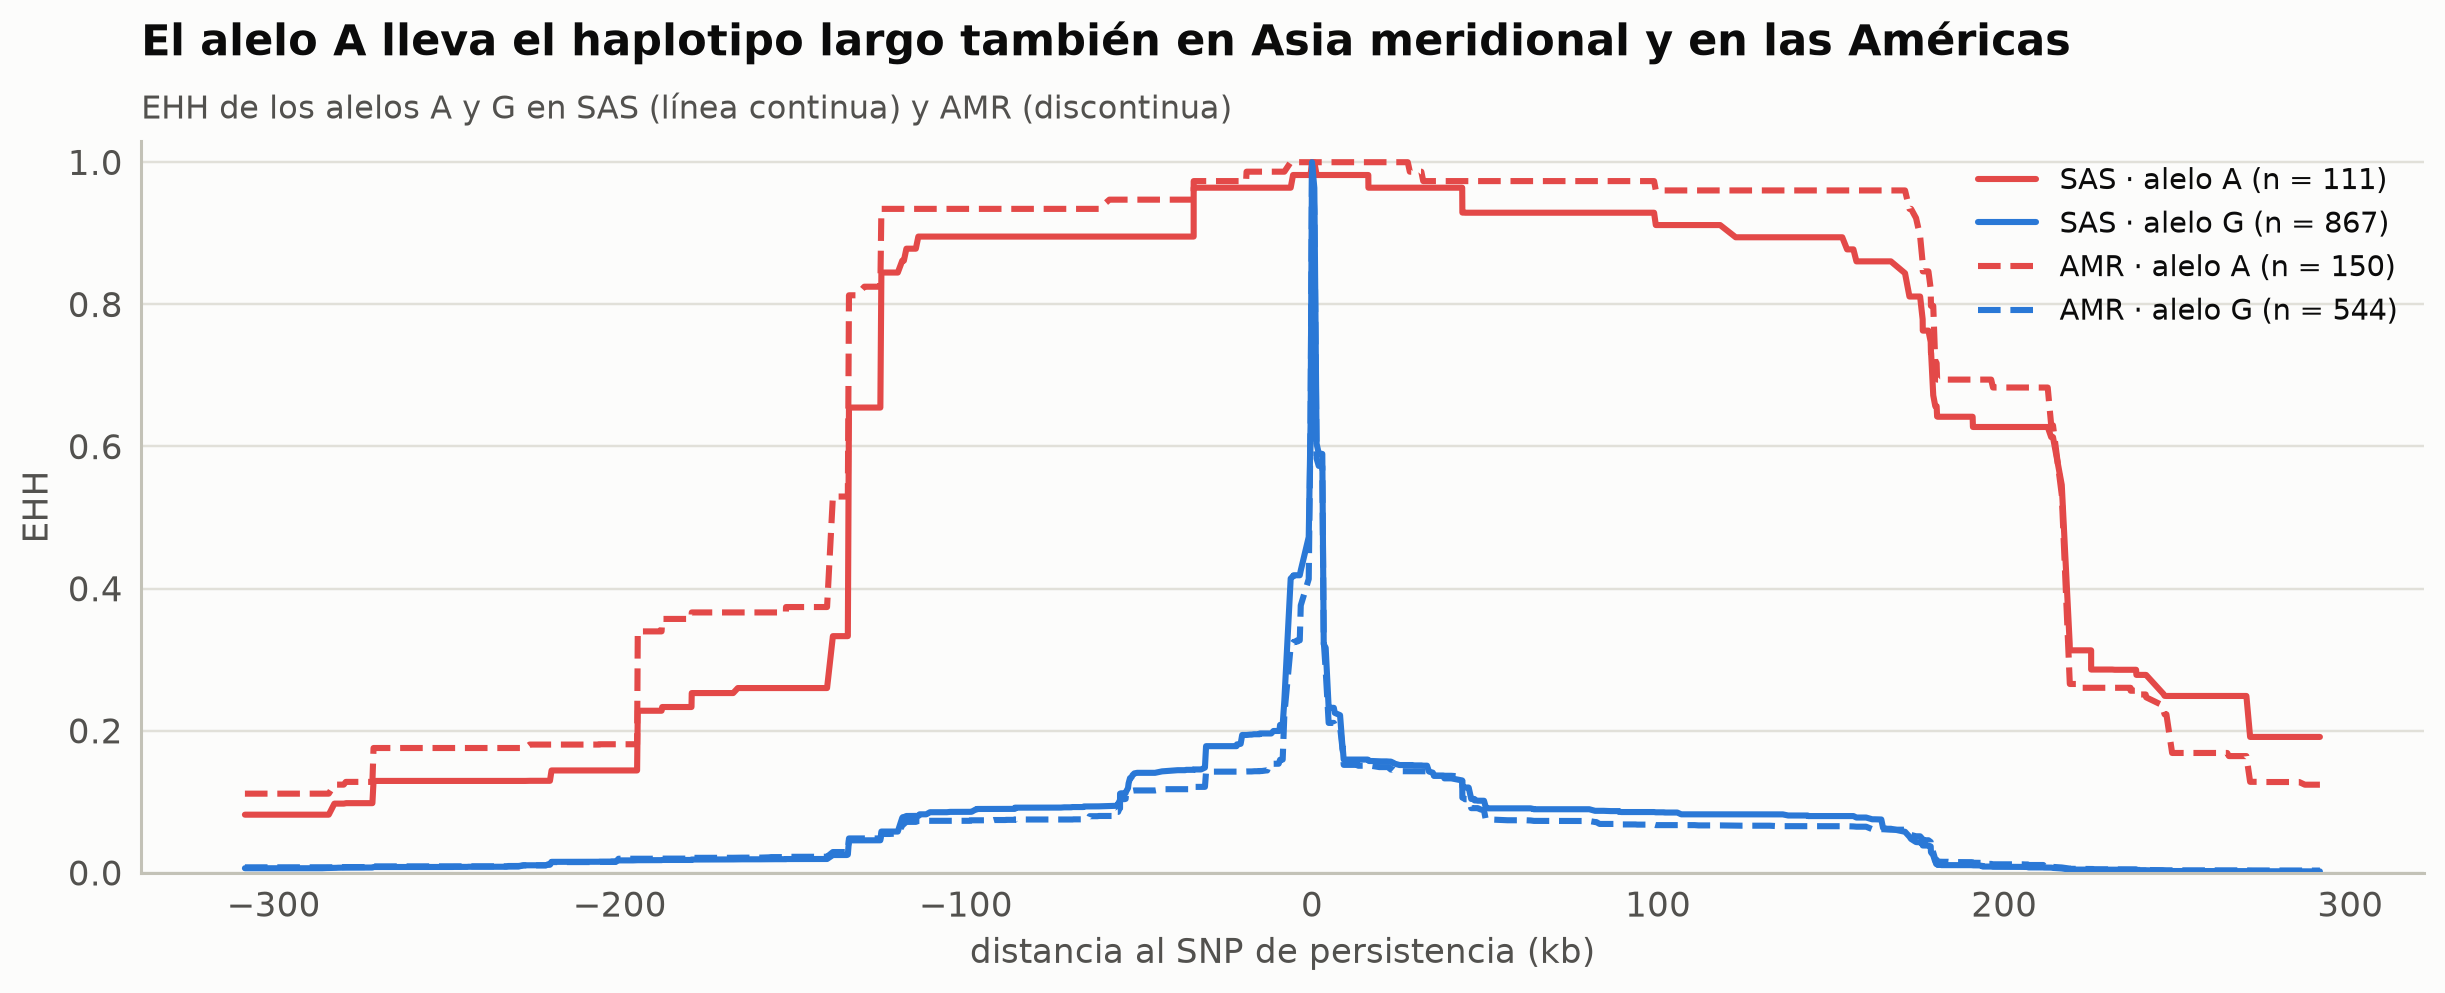

In [43]:
#@title 🔑 Solución — Ejercicio 4 { display-mode: "form" }
fig, ax = plt.subplots(figsize=(11, 4.4))
for sup, ls in (("SAS", "-"), ("AMR", "--")):
    Hs4 = H[hap_sup == sup]
    for allele, col in ((1, ec.RED), (0, ec.BLUE)):
        sel4 = Hs4[Hs4[:, core] == allele]
        xl, el = ehh_curve(sel4, core, -1); xr, er = ehh_curve(sel4, core, +1)
        xs = np.r_[xl[::-1], xr[1:]]; es = np.r_[el[::-1], er[1:]]
        lab = f"{sup} · alelo {'A' if allele else 'G'} (n = {len(sel4)})"
        ax.plot((xs - CORE_POS) / 1e3, es, color=col, ls=ls, lw=2, label=lab)
ax.set_xlabel("distancia al SNP de persistencia (kb)"); ax.set_ylabel("EHH"); ax.set_ylim(0, 1.03)
ax.legend(frameon=False, fontsize=9.5)
ec.title(ax, "El alelo A lleva el haplotipo largo también en Asia meridional y en las Américas",
         "EHH de los alelos A y G en SAS (línea continua) y AMR (discontinua)")
plt.show()
# El haplotipo largo del alelo A aparece también en SAS y AMR: en AMR, porque el alelo llegó con la ancestría
# europea hace pocas generaciones (sin tiempo para recombinar); en SAS, porque el alelo es compartido con Europa
# (flujo génico o un origen común del haplotipo) y el barrido es reciente en términos evolutivos.

In [44]:
#@title 🔑 Solución — Ejercicio 5 { display-mode: "form" }
for a5, b5 in (("CEU", "GBR"), ("CEU", "YRI")):
    Ga, Gb = Gp[a5], Gp[b5]
    print(f"{a5}–{b5}: ingenuo = {fst_naive(Ga, Gb):.4f} · Weir-Cockerham = {wc_fst(Ga, Gb):.4f} "
          f"(n = {len(Ga)} y {len(Gb)})")
# El ingenuo suma el ruido de muestreo, ~1/(2n) con n ≈ 100 → ≈ 0,005. Entre CEU y YRI (F_ST ≈ 0,16) ese sesgo
# es pequeño en términos relativos; entre CEU y GBR, cuyo F_ST verdadero es ≈ 0, el sesgo ES toda la señal.

CEU–GBR: ingenuo = 0.0053 · Weir-Cockerham = -0.0001 (n = 99 y 91)
CEU–YRI: ingenuo = 0.1754 · Weir-Cockerham = 0.1571 (n = 99 y 108)


In [45]:
#@title 🔑 Solución — Ejercicio 6 { display-mode: "form" }
eur_i = info22["super_pop"].values == "EUR"
G_lct = (H[0::2] + H[1::2]).astype(float)                     # dosis de LCT (mismas personas y orden)
assert (np.array(vcf_samples) == samples22).all()
dose_core = G_lct[eur_i, core]
for name, GG in (("chr22", G22[eur_i]), ("chr22 + LCT sin podar", np.hstack([G22[eur_i], G_lct[eur_i]]))):
    pcs6, lam6 = pca_genotipos(GG, k=5)
    cors = [abs(np.corrcoef(pcs6[:, k], dose_core)[0, 1]) for k in range(5)]
    print(f"{name:<24} λ1..5 = {np.round(lam6[:5], 1)} · |corr(PC_k, dosis de A)| = {np.round(cors, 2)}")
# Con sólo chr22, ningún PC se correlaciona con el alelo de persistencia. Al añadir 907 SNP en fuerte LD, PC1 salta
# (λ1 mucho mayor) y se correlaciona ~0,9 con la dosis de A: el componente ha sido "secuestrado" por el haplotipo
# del barrido y ya no describe ancestría genómica. Solución: podar por LD (p. ej. quedarse con SNP con r² < 0,2 en
# ventanas; en PLINK --indep-pairwise) y excluir regiones de LD extenso conocidas (HLA, inversiones, LCT…).

chr22                    λ1..5 = [6.9 6.1 5.1 5.  4.7] · |corr(PC_k, dosis de A)| = [0.   0.16 0.03 0.15 0.04]
chr22 + LCT sin podar    λ1..5 = [45.6 19.7 12.5  7.5  6.7] · |corr(PC_k, dosis de A)| = [0.86 0.21 0.04 0.08 0.08]


## 📌 Resumen

* Un **haplotipo** es la combinación de alelos de un mismo cromosoma. El desequilibrio de ligamiento mide cuánto se
  apartan los haplotipos de la independencia: $D=p_{AB}-p_Ap_B=p_{AB}p_{ab}-p_{Ab}p_{aB}$ (10-D).
* **$D'$** (Lewontin) normaliza por el máximo posible: $\lvert D'\rvert=1$ si falta un haplotipo (historia sin
  recombinación visible). **$r^2$** (Hill y Robertson) es la correlación al cuadrado: la fracción de varianza que un
  SNP explica de otro, y la que fija la potencia de un marcador ($n/r^2$ individuos). Ejemplo del libro: $D=0{,}17$,
  $D'=0{,}773$, $r^2=0{,}487$ (10-Dprima).
* La recombinación destruye el LD geométricamente: $D_t=(1-c)^tD_0$ (10-decay): 3 % tras 5 generaciones con
  $c=0{,}5$; 60 % tras 50 con $c=0{,}01$; 90 % tras 100 con $c=0{,}001$. La deriva lo recrea y se llega a
  $\mathbb E[r^2]\approx1/(1+4N_ec)$ (10-sved): 0,20 a 10 kb y 0,024 a 100 kb con $N_e=10^4$.
* Los puntos calientes de recombinación parten el genoma en **bloques de haplotipos**; $D'$ los dibuja, $r^2$ decide
  qué **SNP etiqueta** bastan. HapMap y 1000 Genomas catalogaron ese LD y hacen posible la **imputación**.
* En la región de la **lactasa**, el alelo de persistencia 2:136 608 646 A (−13910 T) es común en Europa (0,51) y
  ausente en Asia oriental, y viaja en un **haplotipo largo** (EHH ≥ 0,25 en cientos de kb frente a unas decenas
  para el alelo ancestral): la huella de un **barrido selectivo** (Bersaglieri et al., 2004). El LD decae más rápido
  en África que en cualquier otro continente.
* **$F_{ST}=(H_T-H_S)/H_T=\operatorname{Var}(p_k)/[\bar p(1-\bar p)]$** (10-fst) crece con la deriva
  ($\approx t/2N$); con muestras finitas se usa el estimador de **Weir-Cockerham**. En 1000 Genomas: ≈ 0,1–0,2 entre
  continentes, ≤ 0,01 dentro de ellos.
* El **PCA de genotipos** estandariza cada SNP, $Z_{ij}=(g_{ij}-2\hat p_j)/\sqrt{2\hat p_j(1-\hat p_j)}$, y
  descompone $\Psi=ZZ^\top/M$ (10-zpca), en la práctica por SVD. $K$ poblaciones dejan $K-1$ autovalores destacados
  (escenario del libro: 13,56 y 6,51 sobre un mar de ≈ 1,5); los mezclados caen entre sus fuentes. La estructura sólo
  se ve si $F_{ST}\gtrsim1/\sqrt{nM}$.
* Con 3 292 SNP del cromosoma 22, el PCA recupera los cinco continentes (4 autovalores destacados), el mestizaje
  americano persona a persona y permite asignar la superpoblación de personas nuevas por proyección: el núcleo de una
  prueba de ancestría y del control de estructura antes de un GWAS.
* El PCA también «ve» el LD: hay que **podar** SNP en LD y excluir regiones de LD extenso antes de usarlo.

## 📚 Lecturas recomendadas

* Lewontin, R. C. (1964). The interaction of selection and linkage. I. General considerations; heterotic models.
  *Genetics*, 49(1), 49–67. https://doi.org/10.1093/genetics/49.1.49
* Hill, W. G. y Robertson, A. (1968). Linkage disequilibrium in finite populations. *Theoretical and Applied
  Genetics*, 38(6), 226–231. https://doi.org/10.1007/BF01245622
* Gabriel, S. B. et al. (2002). The structure of haplotype blocks in the human genome. *Science*, 296(5576),
  2225–2229. https://doi.org/10.1126/science.1069424
* The International HapMap Consortium (2005). A haplotype map of the human genome. *Nature*, 437(7063), 1299–1320.
  https://doi.org/10.1038/nature04226
* The 1000 Genomes Project Consortium (2015). A global reference for human genetic variation. *Nature*, 526(7571),
  68–74. https://doi.org/10.1038/nature15393
* Enattah, N. S. et al. (2002). Identification of a variant associated with adult-type hypolactasia. *Nature
  Genetics*, 30(2), 233–237. https://doi.org/10.1038/ng826
* Sabeti, P. C. et al. (2002). Detecting recent positive selection in the human genome from haplotype structure.
  *Nature*, 419(6909), 832–837. https://doi.org/10.1038/nature01140
* Bersaglieri, T. et al. (2004). Genetic signatures of strong recent positive selection at the lactase gene.
  *American Journal of Human Genetics*, 74(6), 1111–1120. https://doi.org/10.1086/421051
* Tishkoff, S. A. et al. (2007). Convergent adaptation of human lactase persistence in Africa and Europe. *Nature
  Genetics*, 39(1), 31–40. https://doi.org/10.1038/ng1946
* Wright, S. (1931). Evolution in Mendelian populations. *Genetics*, 16(2), 97–159.
  https://doi.org/10.1093/genetics/16.2.97
* Weir, B. S. y Cockerham, C. C. (1984). Estimating F-statistics for the analysis of population structure.
  *Evolution*, 38(6), 1358–1370. https://doi.org/10.1111/j.1558-5646.1984.tb05657.x
* Patterson, N., Price, A. L. y Reich, D. (2006). Population structure and eigenanalysis. *PLoS Genetics*, 2(12),
  e190. https://doi.org/10.1371/journal.pgen.0020190
* Price, A. L. et al. (2006). Principal components analysis corrects for stratification in genome-wide association
  studies. *Nature Genetics*, 38(8), 904–909. https://doi.org/10.1038/ng1847
* Novembre, J. et al. (2008). Genes mirror geography within Europe. *Nature*, 456(7218), 98–101.
  https://doi.org/10.1038/nature07331

In [46]:
print(f"⏱️ Tiempo total de ejecución del notebook: {time.time() - t_start:.0f} s")

⏱️ Tiempo total de ejecución del notebook: 54 s


---

<sub>**Bioinformática Práctica** · © 2026 Juvenal Yosa, PhD · [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · Código bajo licencia MIT ·
Desarrollado con **Claude** (Anthropic) como copiloto.</sub>

[![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai)